<a href="https://colab.research.google.com/github/ishanwa/Forecasting_project/blob/main/XHBoost/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os
import json
import time
from datetime import datetime
from tqdm import tqdm
from typing import List, Dict
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry

# load dataset
df = pd.read_excel("Hotel_Revenue_Data.xlsx")
# Placeholder DataFrame for demonstration purposes if the file is not uploaded
# data = {
#     'Date': pd.to_datetime(['2023-04-18', '2023-04-18', '2023-04-18', '2023-04-18', '2023-04-18']),
#     'MealPeriod': ['Dinner', 'Dinner', 'Dinner', 'Dinner', 'Dinner'],
#     'CheckTotal': [125.0, 37.5, 0.0, 0.0, 70.0],
#     'RevenueCenterName': ['RevenueCenter_1', 'RevenueCenter_1', 'RevenueCenter_1', 'RevenueCenter_1', 'RevenueCenter_2']
# }
# df = pd.DataFrame(data)


#get some in formation about the dataset
'''
print(df.head())

print(df.info())

print(df.describe())

print(df.info())

print(df.head())

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(df.isnull().sum())
'''

print("Columns in dataset:")
print(df.columns)

print("\nUnique meal periods:")
print(df['MealPeriod'].unique())

print("\nUnique revenue centers:")
print(df['RevenueCenterName'].unique())
df.head()

Columns in dataset:
Index(['Date', 'MealPeriod', 'CheckTotal', 'RevenueCenterName'], dtype='object')

Unique meal periods:
['Dinner' 'Lunch' 'BreakFast']

Unique revenue centers:
['RevenueCenter_1' 'RevenueCenter_2' 'RevenueCenter_3' 'RevenueCenter_4'
 'RevenueCenter_5' 'RevenueCenter_6' 'RevenueCenter_7' 'RevenueCenter_8'
 'RevenueCenter_9']


,Date,MealPeriod,CheckTotal,RevenueCenterName
0,2023-04-18,Dinner,125.0,RevenueCenter_1
1,2023-04-18,Dinner,37.5,RevenueCenter_1
2,2023-04-18,Dinner,0.0,RevenueCenter_1
3,2023-04-18,Dinner,0.0,RevenueCenter_1
4,2023-04-18,Dinner,70.0,RevenueCenter_2


In [ ]:
from google.colab import files

print("Please upload 'Hotel_Revenue_Data.xlsx'")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# After upload, you might need to re-run the previous cell to load the DataFrame.

Please upload 'Hotel_Revenue_Data.xlsx'


Saving Hotel_Revenue_Data.xlsx to Hotel_Revenue_Data (1).xlsx
User uploaded file "Hotel_Revenue_Data (1).xlsx" with length 2487528 bytes


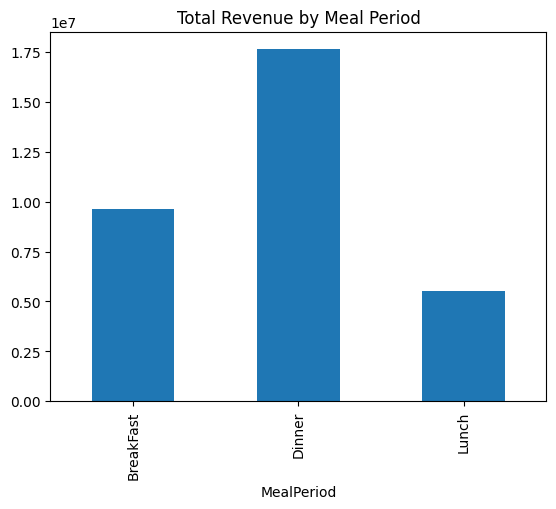

In [ ]:
# grouping the rows based on meal time

groups = df.groupby('MealPeriod')
revenue1 = groups['CheckTotal'].sum()

revenue1.plot(kind='bar', title='Total Revenue by Meal Period')
plt.show()


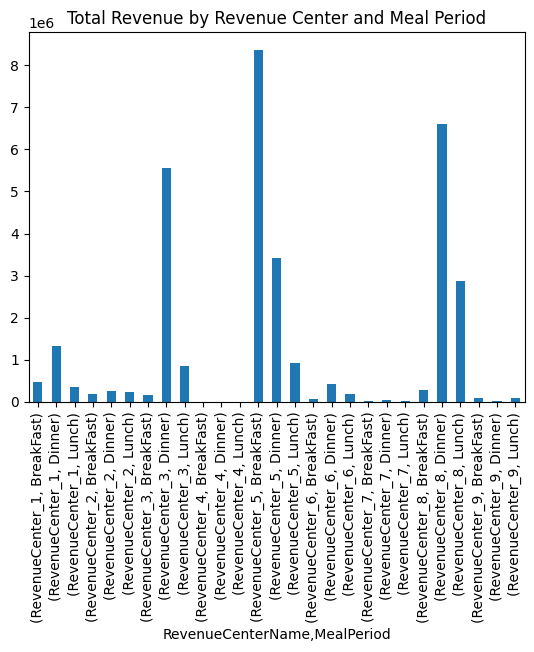

In [ ]:
combined_revenue = df.groupby(['RevenueCenterName', 'MealPeriod'])
revenue_each = combined_revenue['CheckTotal'].sum()

revenue_each.plot(kind='bar', title='Total Revenue by Revenue Center and Meal Period')
plt.show()


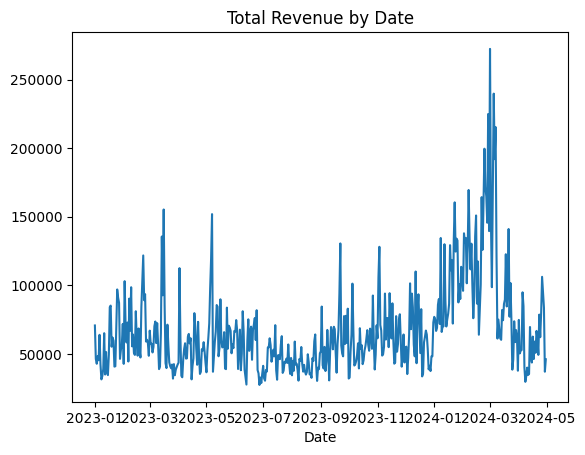

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
groups3 = df.groupby(df['Date'].dt.date)
revenue3 = groups3['CheckTotal'].sum()

revenue3.plot(kind='line', title='Total Revenue by Date')
plt.show()

In [ ]:
df.head()

,Date,MealPeriod,CheckTotal,RevenueCenterName
0,2023-04-18,Dinner,125.0,RevenueCenter_1
1,2023-04-18,Dinner,37.5,RevenueCenter_1
2,2023-04-18,Dinner,0.0,RevenueCenter_1
3,2023-04-18,Dinner,0.0,RevenueCenter_1
4,2023-04-18,Dinner,70.0,RevenueCenter_2


In [ ]:
# Weather code to description mapping
WEATHER_CODES = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail"
}
# Coordinates for Dubai
lat = 25.2048
lon = 55.2708

def get_weather_description(weathercode):
    """Convert weather code to human-readable description"""
    return WEATHER_CODES.get(weathercode, "Unknown")

# Create a session with retry strategy
session = requests.Session()
retry_strategy = Retry(
    total=3,
    backoff_factor=1,
    status_forcelist=[429, 500, 502, 503, 504],
)
session.mount("https://", HTTPAdapter(max_retries=retry_strategy))

def fetch_weather_for_date(date_str):
    try:
        url = (
            "https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={lat}&longitude={lon}"
            f"&start_date={date_str}&end_date={date_str}"
            "&daily=temperature_2m_max,temperature_2m_min,weathercode"
            "&timezone=Asia%2FDubai"
        )
        resp = session.get(url, timeout=30)
        resp.raise_for_status()  # Raise an exception for bad status codes

        data = resp.json().get("daily", {})
        if not data or "temperature_2m_max" not in data:
            print(f"No weather data for {date_str}")
            return None

        weathercode = data["weathercode"][0]

        return {

            "average_temperature": (data["temperature_2m_max"][0]+data["temperature_2m_min"][0]) / 2,
            "weather_description": get_weather_description(weathercode),

        }

    except requests.exceptions.RequestException as e:
        print(f"Error fetching weather for {date_str}: {e}")
        return None


df["Date"] = pd.to_datetime(df["Date"])
weather_list = []

# Add delay between requests to avoid overwhelming the API
unique_dates = df["Date"].dt.strftime("%Y-%m-%d").unique()
total_dates = len(unique_dates)

for i, date in enumerate(unique_dates):
    print(f"Fetching weather for {date} ({i + 1}/{total_dates})")

    w = fetch_weather_for_date(date)
    if w:
        weather_list.append((date, w))

    # Add delay between requests (1 second)
    time.sleep(1)

if weather_list:
    weather_df = pd.DataFrame([{"Date": d, **w} for (d, w) in weather_list])
    weather_df["Date"] = pd.to_datetime(weather_df["Date"])
    df = df.merge(weather_df, on="Date", how="left")
    print("Weather data successfully merged!")

    # Display some statistics
    print("\nWeather Statistics:")
    print(f"Total records with weather data: {len(weather_list)}")
    print(f"Most common weather categories:")


else:
    print("No weather data was fetched successfully")

Fetching weather for 2023-04-18 (1/486)
Fetching weather for 2023-01-23 (2/486)
Fetching weather for 2023-04-19 (3/486)
Fetching weather for 2023-01-27 (4/486)
Fetching weather for 2023-01-26 (5/486)
Fetching weather for 2023-01-08 (6/486)
Fetching weather for 2023-01-09 (7/486)
Fetching weather for 2023-01-25 (8/486)
Fetching weather for 2023-01-07 (9/486)
Fetching weather for 2023-02-08 (10/486)
Fetching weather for 2023-01-28 (11/486)
Fetching weather for 2023-01-04 (12/486)
Fetching weather for 2023-01-03 (13/486)
Fetching weather for 2023-02-09 (14/486)
Fetching weather for 2023-01-14 (15/486)
Fetching weather for 2023-01-13 (16/486)
Fetching weather for 2023-02-10 (17/486)
Fetching weather for 2023-02-12 (18/486)
Fetching weather for 2023-01-10 (19/486)
Fetching weather for 2023-01-17 (20/486)
Fetching weather for 2023-01-11 (21/486)
Fetching weather for 2023-01-21 (22/486)
Fetching weather for 2023-01-18 (23/486)
Fetching weather for 2023-01-19 (24/486)
Fetching weather for 2023

In [ ]:
df.head(10)

,Date,MealPeriod,CheckTotal,RevenueCenterName,average_temperature,weather_description
0,2023-04-18,Dinner,125.0,RevenueCenter_1,25.1,Overcast
1,2023-04-18,Dinner,37.5,RevenueCenter_1,25.1,Overcast
2,2023-04-18,Dinner,0.0,RevenueCenter_1,25.1,Overcast
3,2023-04-18,Dinner,0.0,RevenueCenter_1,25.1,Overcast
4,2023-04-18,Dinner,70.0,RevenueCenter_2,25.1,Overcast
5,2023-04-18,Dinner,35.0,RevenueCenter_2,25.1,Overcast
6,2023-04-18,Lunch,0.0,RevenueCenter_2,25.1,Overcast
7,2023-04-18,BreakFast,17.5,RevenueCenter_2,25.1,Overcast
8,2023-04-18,BreakFast,0.0,RevenueCenter_2,25.1,Overcast
9,2023-04-18,BreakFast,0.0,RevenueCenter_2,25.1,Overcast


In [ ]:
# Gemini SDK Imports
from google import genai
from google.genai import types

# --- API KEY DEFINITIONS ---
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY", "YOUR_GEMINI_KEY")
CALENDARIFIC_API_KEY = os.getenv("CALENDARIFIC_API_KEY", "YOUR_CALENDARIFIC_KEY")
CALENDARIFIC_API_URL = "https://calendarific.com/api/v2/holidays"

In [ ]:
#%%
def get_holidays(start_date: datetime, end_date: datetime) -> List[Dict]:
    """Retrieve and process UAE holidays within a given date range that affect hotels/restaurants."""

    def is_uae_related_holiday(name_of_holiday: str) -> dict:
        """Classify holiday relevance using Gemini."""
        try:
            client = genai.Client()
        except Exception as e:
            print(f"Error initializing Gemini client: {e}")
            return {"does_affect": False, "affect_type": "Public"}

        system_prompt = (
            "You are an expert holiday classification assistant focused on the UAE. "
            "Analyze the holiday name and determine if it significantly affects customer flow "
            "to hotels/restaurants in the UAE. "
            "Return ONLY a JSON object: "
            "{'does_affect': True/False, 'affect_type': 'Christian'/'Hindu'/'Islamic'/'Public'}."
        )

        user_prompt = f"Holiday: {name_of_holiday}"

        config = types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    "does_affect": types.Schema(type=types.Type.BOOLEAN),
                    "affect_type": types.Schema(type=types.Type.STRING),
                },
                required=["does_affect", "affect_type"],
            ),
        )

        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=[types.Content(role="user", parts=[types.Part.from_text(user_prompt)])],
                config=config,
                system_instruction=system_prompt,
            )

            if response.candidates and response.candidates[0].content.parts:
                output = response.candidates[0].content.parts[0].text
                return json.loads(output)
            else:
                return {"does_affect": False, "affect_type": "Public"}

        except Exception as e:
            print(f"Gemini API error for {name_of_holiday}: {e}")
            return {"does_affect": False, "affect_type": "Public"}

    def get_holidays_api(year: int, country: str) -> List[Dict]:
        """Fetch holidays from Calendarific API."""
        params = {"api_key": CALENDARIFIC_API_KEY, "country": country, "year": year}
        try:
            response = requests.get(CALENDARIFIC_API_URL, params=params, timeout=15)
            response.raise_for_status()
            holidays = response.json().get("response", {}).get("holidays", [])
        except Exception as e:
            print(f"Error fetching holidays for {country} {year}: {e}")
            return []

        refined = []
        for h in holidays:
            try:
                holiday_date = datetime.strptime(h["date"]["iso"][:10], "%Y-%m-%d")
                refined.append({
                    "name": h["name"],
                    "date": holiday_date.strftime("%Y-%m-%d"),
                    "country": country,
                })
            except Exception:
                continue
        return refined

    # --- Cache Handling ---
    prev_holidays: List[Dict] = []
    if os.path.exists("holidays.json"):
        try:
            with open("holidays.json", "r") as f:
                prev_holidays = json.load(f)
        except Exception:
            prev_holidays = []

    cached_years = {datetime.strptime(h["date"], "%Y-%m-%d").year for h in prev_holidays}
    required_years = set(range(start_date.year, end_date.year + 1))
    missing_years = list(required_years - cached_years)

    holidays: List[Dict] = []
    for year in missing_years:
        holidays.extend(get_holidays_api(year, "AE"))

    refined_holidays = []
    for holiday in tqdm(holidays, desc="Classifying holidays with Gemini"):
        result = is_uae_related_holiday(holiday["name"])
        if result["does_affect"]:
            refined_holidays.append({
                "name": holiday["name"],
                "date": holiday["date"],
                "affect_type": result["affect_type"],
                "country": holiday["country"],
            })

    # Merge with cache, avoid duplications
    all_holidays = prev_holidays + refined_holidays
    unique = {(h["name"], h["date"], h["country"]): h for h in all_holidays}
    final_holidays = sorted(unique.values(), key=lambda x: x["date"])

    # Save cache
    try:
        with open("holidays.json", "w") as f:
            json.dump(final_holidays, f, indent=2)
    except Exception as e:
        print(f"Error saving cache: {e}")

    # Filter by date range
    return [h for h in final_holidays if start_date.strftime("%Y-%m-%d") <= h["date"] <= end_date.strftime("%Y-%m-%d")]


In [ ]:
def add_holiday_and_weekend_features(df):
    """Add holiday and weekend features to the dataframe."""

    print("Adding holiday and weekend features...")

    df["Date"] = pd.to_datetime(df["Date"])
    start_date = df["Date"].min()
    end_date = df["Date"].max()

    print(f"Getting holidays for date range: {start_date} to {end_date}")
    relevant_uae_holidays = get_holidays(start_date=start_date, end_date=end_date)

    ae_holidays_list = [h["date"] for h in relevant_uae_holidays if h["country"] == "AE"]
    ae_holidays_list_dt = pd.to_datetime(ae_holidays_list)

    print(f"Found {len(ae_holidays_list_dt)} relevant holidays")

    df["DayOfWeek"] = df["Date"].dt.day_name()
    df["IsWeekend"] = df["DayOfWeek"].isin(["Sunday", "Saturday"]).astype(int)  #  UAE weekend fixed
    df["IsHoliday"] = df["Date"].isin(ae_holidays_list_dt).astype(int)

    print(f"Total holiday records in dataset: {df['IsHoliday'].sum()}")
    return df


# --- MAIN EXECUTION ---
def main():
    print("Starting comprehensive feature engineering...")

    df_with_holidays = add_holiday_and_weekend_features(df.copy())
    df_with_all_features = fetch_weather_data(df_with_holidays.copy())

    #  Keep all columns instead of filtering
    final_df = df_with_all_features.copy()

    print("\n=== FINAL DATASET SUMMARY ===")
    print(f"Total records: {len(final_df)}")
    print(f"Date range: {final_df['Date'].min()} to {final_df['Date'].max()}")
    print(f"Holiday records: {final_df['IsHoliday'].sum()}")
    print(f"Weekend records: {final_df['IsWeekend'].sum()}")
    print(f"Weather data coverage: {final_df['average_temperature'].notna().sum()} records")

    print("\nFirst 10 rows of final dataset:")
    print(final_df.head(10))

    print("\nColumn details:")
    print(final_df.info())

    print("\nPreview of engineered dataset:")
    print(final_df.head())


In [ ]:
# Step 1: Add holiday/weekend features
df_with_holidays = add_holiday_and_weekend_features(df.copy())
print("After holiday/weekend features:")
print(df_with_holidays.head())

Adding holiday and weekend features...
Getting holidays for date range: 2023-01-01 00:00:00 to 2024-04-30 00:00:00
Error fetching holidays for AE 2024: 401 Client Error: Unauthorized for url: https://calendarific.com/api/v2/holidays?api_key=YOUR_CALENDARIFIC_KEY&country=AE&year=2024
Error fetching holidays for AE 2023: 401 Client Error: Unauthorized for url: https://calendarific.com/api/v2/holidays?api_key=YOUR_CALENDARIFIC_KEY&country=AE&year=2023


Classifying holidays with Gemini: 0it [00:00, ?it/s]

Found 0 relevant holidays
Total holiday records in dataset: 0
After holiday/weekend features:
        Date MealPeriod  CheckTotal RevenueCenterName  average_temperature  \
0 2023-04-18     Dinner       125.0   RevenueCenter_1                 25.1   
1 2023-04-18     Dinner        37.5   RevenueCenter_1                 25.1   
2 2023-04-18     Dinner         0.0   RevenueCenter_1                 25.1   
3 2023-04-18     Dinner         0.0   RevenueCenter_1                 25.1   
4 2023-04-18     Dinner        70.0   RevenueCenter_2                 25.1   

  weather_description DayOfWeek  IsWeekend  IsHoliday  
0            Overcast   Tuesday          0          0  
1            Overcast   Tuesday          0          0  
2            Overcast   Tuesday          0          0  
3            Overcast   Tuesday          0          0  
4            Overcast   Tuesday          0          0  


In [ ]:
import pandas as pd

# Use df_with_holidays dataframe
df = df_with_holidays.copy()

print("Initial dataset shape:", df.shape)
print("\nColumns in dataset:", df.columns.tolist())
print("\nUnique meal periods:", df['MealPeriod'].unique())

# 1. Group by Date, RevenueCenterName, and MealPeriod to get totals
meal_totals = df.groupby(['Date', 'RevenueCenterName', 'MealPeriod'])['CheckTotal'].sum().reset_index()

print(f"\nAfter grouping: {meal_totals.shape} rows")

# 2. Pivot to create separate columns for each meal period
pivot_df = meal_totals.pivot_table(
    index=['Date', 'RevenueCenterName'],
    columns='MealPeriod',
    values='CheckTotal',
    fill_value=0
).reset_index()

# Flatten the column names
pivot_df.columns.name = None

print(f"\nAfter pivoting: {pivot_df.shape} rows, {pivot_df.shape[1]} columns")

# 3. Get unique values for other features
# Since weather and holiday features should be the same for each date-revenue center combination
other_features = df[['Date', 'RevenueCenterName', 'average_temperature',
                     'weather_description', 'DayOfWeek', 'IsWeekend', 'IsHoliday']].drop_duplicates()

print(f"\nUnique date-revenue center combinations: {other_features.shape[0]}")

# 4. Merge the pivoted meal data with other features
final_df = pd.merge(pivot_df, other_features,
                    on=['Date', 'RevenueCenterName'],
                    how='left')

print(f"\nAfter merging: {final_df.shape} rows, {final_df.shape[1]} columns")

# 5. Check for and handle any potential duplicates
duplicates = final_df.duplicated(subset=['Date', 'RevenueCenterName'], keep=False).sum()
if duplicates > 0:
    print(f"\nFound {duplicates} duplicate rows, removing duplicates...")
    final_df = final_df.drop_duplicates(subset=['Date', 'RevenueCenterName'])
    print(f"After removing duplicates: {final_df.shape} rows")

# 6. Identify meal period columns
all_columns = final_df.columns.tolist()
non_meal_cols = ['Date', 'RevenueCenterName', 'average_temperature',
                 'weather_description', 'DayOfWeek', 'IsWeekend', 'IsHoliday']
meal_cols = [col for col in all_columns if col not in non_meal_cols]

print(f"\nMeal period columns found: {meal_cols}")

# 7. Reorder columns for better readability
column_order = ['Date', 'RevenueCenterName'] + meal_cols + \
               ['average_temperature', 'weather_description',
                'DayOfWeek', 'IsWeekend', 'IsHoliday']

final_df = final_df[column_order]

# 8. Sort by Date and RevenueCenterName
final_df = final_df.sort_values(['Date', 'RevenueCenterName']).reset_index(drop=True)

# 9. Display the final result
print("\n" + "="*80)
print("FINAL TRANSFORMED DATASET")
print("="*80)
print(f"Shape: {final_df.shape} (rows: {final_df.shape[0]}, columns: {final_df.shape[1]})")
print(f"\nColumns in order:")
for i, col in enumerate(final_df.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "-"*80)
print("FIRST 10 ROWS:")
print("-"*80)
print(final_df.head(10))

print("\n" + "-"*80)
print("MEAL PERIOD SUMMARY STATISTICS:")
print("-"*80)
if meal_cols:
    print(final_df[meal_cols].describe())

print("\n" + "-"*80)
print("SAMPLE BY REVENUE CENTER:")
print("-"*80)
# Show a sample for each revenue center
for rev_center in final_df['RevenueCenterName'].unique()[:3]:  # Show first 3 revenue centers
    print(f"\nRevenue Center: {rev_center}")
    sample = final_df[final_df['RevenueCenterName'] == rev_center].head(3)
    print(sample.to_string(index=False))
    print()

# Optional: Save to CSV
# final_df.to_csv('transformed_data_with_meal_totals.csv', index=False)
# print("\nData saved to 'transformed_data_with_meal_totals.csv'")

Initial dataset shape: (120562, 9)

Columns in dataset: ['Date', 'MealPeriod', 'CheckTotal', 'RevenueCenterName', 'average_temperature', 'weather_description', 'DayOfWeek', 'IsWeekend', 'IsHoliday']

Unique meal periods: ['Dinner' 'Lunch' 'BreakFast']

After grouping: (10190, 4) rows

After pivoting: (4194, 5) rows, 5 columns

Unique date-revenue center combinations: 4194

After merging: (4194, 10) rows, 10 columns

Meal period columns found: ['BreakFast', 'Dinner', 'Lunch']

FINAL TRANSFORMED DATASET
Shape: (4194, 10) (rows: 4194, columns: 10)

Columns in order:
 1. Date
 2. RevenueCenterName
 3. BreakFast
 4. Dinner
 5. Lunch
 6. average_temperature
 7. weather_description
 8. DayOfWeek
 9. IsWeekend
10. IsHoliday

--------------------------------------------------------------------------------
FIRST 10 ROWS:
--------------------------------------------------------------------------------
        Date RevenueCenterName  BreakFast   Dinner   Lunch  \
0 2023-01-01   RevenueCenter_1    

In [ ]:
# Step 1: Get unique revenue centers
revenue_centers = final_df["RevenueCenterName"].unique()
print("Revenue centers found:", revenue_centers)

# Step 2: Create a dictionary of dataframes
center_dfs = {}

for center in revenue_centers:
    # Filter rows for this revenue center
    df_center = final_df[final_df["RevenueCenterName"] == center].copy()
    # Sort by Date
    df_center = df_center.sort_values(by="Date")
    # Store in dictionary
    center_dfs[center] = df_center

# Step 3: Print each dataset
for center, df_center in center_dfs.items():
    print(f"\n=== Dataset for {center} ===")
    print(df_center.head(10))   # show first 10 rows
    print(f"Total records: {len(df_center)}")


Revenue centers found: ['RevenueCenter_1' 'RevenueCenter_2' 'RevenueCenter_3' 'RevenueCenter_4'
 'RevenueCenter_5' 'RevenueCenter_6' 'RevenueCenter_8' 'RevenueCenter_9'
 'RevenueCenter_7']

=== Dataset for RevenueCenter_1 ===
         Date RevenueCenterName  BreakFast  Dinner   Lunch  \
0  2023-01-01   RevenueCenter_1     1499.4  4374.5  1260.0   
8  2023-01-02   RevenueCenter_1      771.0  3460.0  1042.0   
16 2023-01-03   RevenueCenter_1     1302.4  2735.9   826.0   
24 2023-01-04   RevenueCenter_1     1737.0  3829.0   712.0   
33 2023-01-05   RevenueCenter_1      653.0  3868.0  1162.0   
41 2023-01-06   RevenueCenter_1     1204.4  3124.5  1285.0   
49 2023-01-07   RevenueCenter_1     1172.0  1967.5  1111.0   
56 2023-01-08   RevenueCenter_1     1139.0  2210.9   543.0   
63 2023-01-09   RevenueCenter_1      300.0  2414.0   232.0   
72 2023-01-10   RevenueCenter_1      740.0  1632.5  1139.0   

    average_temperature weather_description  DayOfWeek  IsWeekend  IsHoliday  
0           

In [ ]:
final_df.head(10)

,Date,RevenueCenterName,BreakFast,Dinner,Lunch,average_temperature,weather_description,Day_Monday,Day_Tuesday,Day_Wednesday,Day_Thursday,Day_Friday,Day_Saturday,Day_Sunday,IsWeekend,IsHoliday
0,2023-01-01,RevenueCenter_1,1499.4,4374.5,1260.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
1,2023-01-01,RevenueCenter_2,35.0,407.0,30.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
2,2023-01-01,RevenueCenter_3,0.0,9441.9,763.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
3,2023-01-01,RevenueCenter_4,0.0,0.0,0.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
4,2023-01-01,RevenueCenter_5,21807.0,4395.0,415.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
5,2023-01-01,RevenueCenter_6,93.0,1166.0,1446.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
6,2023-01-01,RevenueCenter_8,0.0,23000.0,0.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
7,2023-01-01,RevenueCenter_9,0.0,0.0,605.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
8,2023-01-02,RevenueCenter_1,771.0,3460.0,1042.0,20.20,Overcast,True,False,False,False,False,False,False,0,0
9,2023-01-02,RevenueCenter_2,608.5,398.5,136.0,20.20,Overcast,True,False,False,False,False,False,False,0,0


In [ ]:
import pandas as pd

# Assuming you have your final_df from previous steps
# If not, recreate it from your data
df_encoded = final_df.copy()

print("Original dataset shape:", df_encoded.shape)
print("\nFirst, let's see the current structure:")
print(df_encoded.head())

# Apply OneHotEncoding to DayOfWeek
day_dummies = pd.get_dummies(df_encoded['DayOfWeek'], prefix='Day')

# Ensure all 7 days are represented in correct order
all_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_columns_ordered = [f'Day_{day}' for day in all_days]

# Reindex to ensure all 7 days are present
day_dummies = day_dummies.reindex(columns=day_columns_ordered, fill_value=0)

# Concatenate with original dataframe
df_encoded = pd.concat([df_encoded, day_dummies], axis=1)

# Drop the original DayOfWeek column
df_encoded = df_encoded.drop('DayOfWeek', axis=1)

# Reorder columns for better organization
# Get all column names
all_columns = df_encoded.columns.tolist()

# Separate columns by type
date_cols = [col for col in all_columns if col in ['Date', 'RevenueCenterName']]
meal_cols = [col for col in all_columns if col in ['BreakFast', 'Lunch', 'Dinner']]  # Adjust based on your actual meal columns
weather_cols = [col for col in all_columns if col in ['average_temperature', 'weather_description']]
day_cols = [col for col in all_columns if col.startswith('Day_')]
flag_cols = [col for col in all_columns if col in ['IsWeekend', 'IsHoliday']]

# Other columns (if any)
other_cols = [col for col in all_columns if col not in date_cols + meal_cols + weather_cols + day_cols + flag_cols]

# Create final column order
final_order = date_cols + meal_cols + weather_cols + day_cols + flag_cols + other_cols

# Apply the order (keeping only columns that exist)
final_order = [col for col in final_order if col in df_encoded.columns]
df_encoded = df_encoded[final_order]

# Now you have your final dataframe!
final_df_with_encoded_days = df_encoded.copy()

print("\n" + "="*80)
print("FINAL DATAFRAME WITH ONE-HOT ENCODED DAYS")
print("="*80)
print(f"Shape: {final_df_with_encoded_days.shape}")
print(f"\nColumns ({len(final_df_with_encoded_days.columns)} total):")
for i, col in enumerate(final_df_with_encoded_days.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "-"*80)
print("FIRST 5 ROWS:")
print("-"*80)
print(final_df_with_encoded_days.head())

print("\n" + "-"*80)
print("VERIFICATION:")
print("-"*80)
print("Checking that each row has exactly one day set to 1:")
print(f"Total rows: {len(final_df_with_encoded_days)}")
print(f"Sum of day columns per row (should all be 1):")
day_sums = final_df_with_encoded_days[day_columns_ordered].sum(axis=1)
print(f"Rows with sum = 1: {(day_sums == 1).sum()}")
print(f"Rows with sum != 1: {(day_sums != 1).sum()}")

# Show a sample to demonstrate the encoding
print("\n" + "-"*80)
print("SAMPLE SHOWING ENCODING:")
print("-"*80)
sample = final_df_with_encoded_days.head(10)[['Date', 'RevenueCenterName'] + day_columns_ordered]
print(sample.to_string(index=False))

# If you want to save it to a new variable called just 'final_df'
final_df = final_df_with_encoded_days.copy()
print("\n✓ Dataframe saved as 'final_df' with one-hot encoded days!")
print("✓ Original DayOfWeek column has been removed")
print("✓ 7 binary day columns have been added")

# To verify the transformation worked correctly:
print("\n" + "-"*80)
print("DAY DISTRIBUTION:")
print("-"*80)
for day_col in day_columns_ordered:
    count = final_df[day_col].sum()
    print(f"{day_col}: {int(count)} rows")

print("\nYou can now use 'final_df' for your analysis/modeling!")

Original dataset shape: (4194, 16)

First, let's see the current structure:
        Date RevenueCenterName  BreakFast  Dinner   Lunch  \
0 2023-01-01   RevenueCenter_1     1499.4  4374.5  1260.0   
1 2023-01-01   RevenueCenter_2       35.0   407.0    30.0   
2 2023-01-01   RevenueCenter_3        0.0  9441.9   763.0   
3 2023-01-01   RevenueCenter_4        0.0     0.0     0.0   
4 2023-01-01   RevenueCenter_5    21807.0  4395.0   415.0   

   average_temperature weather_description  Day_Monday  Day_Tuesday  \
0                21.25       Partly cloudy       False        False   
1                21.25       Partly cloudy       False        False   
2                21.25       Partly cloudy       False        False   
3                21.25       Partly cloudy       False        False   
4                21.25       Partly cloudy       False        False   

   Day_Wednesday  Day_Thursday  Day_Friday  Day_Saturday  Day_Sunday  \
0          False         False       False         False  

KeyError: 'DayOfWeek'

In [ ]:
final_df.head(10)

,Date,RevenueCenterName,BreakFast,Dinner,Lunch,average_temperature,weather_description,Day_Monday,Day_Tuesday,Day_Wednesday,Day_Thursday,Day_Friday,Day_Saturday,Day_Sunday,IsWeekend,IsHoliday
0,2023-01-01,RevenueCenter_1,1499.4,4374.5,1260.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
1,2023-01-01,RevenueCenter_2,35.0,407.0,30.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
2,2023-01-01,RevenueCenter_3,0.0,9441.9,763.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
3,2023-01-01,RevenueCenter_4,0.0,0.0,0.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
4,2023-01-01,RevenueCenter_5,21807.0,4395.0,415.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
5,2023-01-01,RevenueCenter_6,93.0,1166.0,1446.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
6,2023-01-01,RevenueCenter_8,0.0,23000.0,0.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
7,2023-01-01,RevenueCenter_9,0.0,0.0,605.0,21.25,Partly cloudy,False,False,False,False,False,False,True,1,0
8,2023-01-02,RevenueCenter_1,771.0,3460.0,1042.0,20.20,Overcast,True,False,False,False,False,False,False,0,0
9,2023-01-02,RevenueCenter_2,608.5,398.5,136.0,20.20,Overcast,True,False,False,False,False,False,False,0,0


In [ ]:
# Convert only IsWeekend and IsHoliday columns
final_df[['Day_Monday', 'Day_Tuesday', 'Day_Wednesday', 'Day_Thursday', 'Day_Friday', 'Day_Saturday', 'Day_Sunday']] = final_df[['Day_Monday', 'Day_Tuesday', 'Day_Wednesday', 'Day_Thursday', 'Day_Friday', 'Day_Saturday', 'Day_Sunday']].astype(int)

In [ ]:
final_df.head(10)

,Date,RevenueCenterName,BreakFast,Dinner,Lunch,average_temperature,weather_description,Day_Monday,Day_Tuesday,Day_Wednesday,Day_Thursday,Day_Friday,Day_Saturday,Day_Sunday,IsWeekend,IsHoliday
0,2023-01-01,RevenueCenter_1,1499.4,4374.5,1260.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
1,2023-01-01,RevenueCenter_2,35.0,407.0,30.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
2,2023-01-01,RevenueCenter_3,0.0,9441.9,763.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
3,2023-01-01,RevenueCenter_4,0.0,0.0,0.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
4,2023-01-01,RevenueCenter_5,21807.0,4395.0,415.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
5,2023-01-01,RevenueCenter_6,93.0,1166.0,1446.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
6,2023-01-01,RevenueCenter_8,0.0,23000.0,0.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
7,2023-01-01,RevenueCenter_9,0.0,0.0,605.0,21.25,Partly cloudy,0,0,0,0,0,0,1,1,0
8,2023-01-02,RevenueCenter_1,771.0,3460.0,1042.0,20.20,Overcast,1,0,0,0,0,0,0,0,0
9,2023-01-02,RevenueCenter_2,608.5,398.5,136.0,20.20,Overcast,1,0,0,0,0,0,0,0,0


In [ ]:
# Create the reverse mapping dictionary
WEATHER_DESC_TO_CODE = {
    "Clear sky": 0,
    "Mainly clear": 1,
    "Partly cloudy": 2,
    "Overcast": 3,
    "Fog": 45,
    "Depositing rime fog": 48,
    "Light drizzle": 51,
    "Moderate drizzle": 53,
    "Dense drizzle": 55,
    "Light freezing drizzle": 56,
    "Dense freezing drizzle": 57,
    "Slight rain": 61,
    "Moderate rain": 63,
    "Heavy rain": 65,
    "Light freezing rain": 66,
    "Heavy freezing rain": 67,
    "Slight snow fall": 71,
    "Moderate snow fall": 73,
    "Heavy snow fall": 75,
    "Snow grains": 77,
    "Slight rain showers": 80,
    "Moderate rain showers": 81,
    "Violent rain showers": 82,
    "Slight snow showers": 85,
    "Heavy snow showers": 86,
    "Thunderstorm": 95,
    "Thunderstorm with slight hail": 96,
    "Thunderstorm with heavy hail": 99
}

# Use apply() for conversion (more efficient than for loop)
final_df['weather_description'] = final_df['weather_description'].apply(
    lambda x: WEATHER_DESC_TO_CODE.get(x, 3)  # Default to 3 (Overcast) if not found
)

# Rename the column
final_df = final_df.rename(columns={'weather_description': 'weather_code'})

print("Data after conversion:")
print(final_df.head())

Data after conversion:
        Date RevenueCenterName  BreakFast  Dinner   Lunch  \
0 2023-01-01   RevenueCenter_1     1499.4  4374.5  1260.0   
1 2023-01-01   RevenueCenter_2       35.0   407.0    30.0   
2 2023-01-01   RevenueCenter_3        0.0  9441.9   763.0   
3 2023-01-01   RevenueCenter_4        0.0     0.0     0.0   
4 2023-01-01   RevenueCenter_5    21807.0  4395.0   415.0   

   average_temperature  weather_code  Day_Monday  Day_Tuesday  Day_Wednesday  \
0                21.25             2           0            0              0   
1                21.25             2           0            0              0   
2                21.25             2           0            0              0   
3                21.25             2           0            0              0   
4                21.25             2           0            0              0   

   Day_Thursday  Day_Friday  Day_Saturday  Day_Sunday  IsWeekend  IsHoliday  
0             0           0             0          

In [ ]:
final_df.head(10)

,Date,RevenueCenterName,BreakFast,Dinner,Lunch,average_temperature,weather_code,Day_Monday,Day_Tuesday,Day_Wednesday,Day_Thursday,Day_Friday,Day_Saturday,Day_Sunday,IsWeekend,IsHoliday
0,2023-01-01,RevenueCenter_1,1499.4,4374.5,1260.0,21.25,2,0,0,0,0,0,0,1,1,0
1,2023-01-01,RevenueCenter_2,35.0,407.0,30.0,21.25,2,0,0,0,0,0,0,1,1,0
2,2023-01-01,RevenueCenter_3,0.0,9441.9,763.0,21.25,2,0,0,0,0,0,0,1,1,0
3,2023-01-01,RevenueCenter_4,0.0,0.0,0.0,21.25,2,0,0,0,0,0,0,1,1,0
4,2023-01-01,RevenueCenter_5,21807.0,4395.0,415.0,21.25,2,0,0,0,0,0,0,1,1,0
5,2023-01-01,RevenueCenter_6,93.0,1166.0,1446.0,21.25,2,0,0,0,0,0,0,1,1,0
6,2023-01-01,RevenueCenter_8,0.0,23000.0,0.0,21.25,2,0,0,0,0,0,0,1,1,0
7,2023-01-01,RevenueCenter_9,0.0,0.0,605.0,21.25,2,0,0,0,0,0,0,1,1,0
8,2023-01-02,RevenueCenter_1,771.0,3460.0,1042.0,20.20,3,1,0,0,0,0,0,0,0,0
9,2023-01-02,RevenueCenter_2,608.5,398.5,136.0,20.20,3,1,0,0,0,0,0,0,0,0


In [ ]:
import os

# Create the directory in Colab's temporary storage
output_dir = '/content/data_sets'
os.makedirs(output_dir, exist_ok=True)

# Get unique Revenue Centers
revenue_centers = final_df['RevenueCenterName'].unique()

# Save each Revenue Center to a separate Excel file
for rev_center in revenue_centers:
    # Filter data for this revenue center
    center_data = final_df[final_df['RevenueCenterName'] == rev_center]

    # Create filename (replace spaces with underscores)
    filename = f"{rev_center.replace(' ', '_')}.xlsx"
    filepath = os.path.join(output_dir, filename)

    # Save to Excel
    center_data.to_excel(filepath, index=False)

print(f"Saved {len(revenue_centers)} Excel files to: {output_dir}")
print(f"Files are saved in Colab's temporary storage at: {output_dir}")
print("Note: These files will be deleted when your Colab session ends!")

Saved 9 Excel files to: /content/data_sets
Files are saved in Colab's temporary storage at: /content/data_sets
Note: These files will be deleted when your Colab session ends!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from google.colab import files

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define folder path in Colab (where you previously saved the files)
folder_path = '/content/data_sets'
pattern = "RevenueCenter_*.xlsx"    # * means "anything after that"

# Get all matching files
file_paths = glob.glob(os.path.join(folder_path, pattern))

# If no files found, you may need to upload them
if not file_paths:
    print("No files found. Uploading Excel files...")

    # Upload files from your local machine
    uploaded = files.upload()

    # Get uploaded file paths
    file_paths = list(uploaded.keys())

    # Move files to the data_sets folder
    os.makedirs(folder_path, exist_ok=True)
    for file_name in file_paths:
        os.rename(file_name, os.path.join(folder_path, file_name))

    # Update file_paths to point to the new location
    file_paths = [os.path.join(folder_path, f) for f in uploaded.keys()]

# Load all datasets into a dictionary
datasets = {}
for file_path in file_paths:
    dataset_name = os.path.basename(file_path).replace('.xlsx', '')
    datasets[dataset_name] = pd.read_excel(file_path)
    print(f"Loaded: {dataset_name} - Shape: {datasets[dataset_name].shape}")

print(f"\nTotal datasets loaded: {len(datasets)}")

Loaded: RevenueCenter_9 - Shape: (431, 16)
Loaded: RevenueCenter_1 - Shape: (486, 16)
Loaded: RevenueCenter_5 - Shape: (486, 16)
Loaded: RevenueCenter_2 - Shape: (483, 16)
Loaded: RevenueCenter_8 - Shape: (412, 16)
Loaded: RevenueCenter_6 - Shape: (476, 16)
Loaded: RevenueCenter_3 - Shape: (486, 16)
Loaded: RevenueCenter_7 - Shape: (456, 16)
Loaded: RevenueCenter_4 - Shape: (478, 16)

Total datasets loaded: 9


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


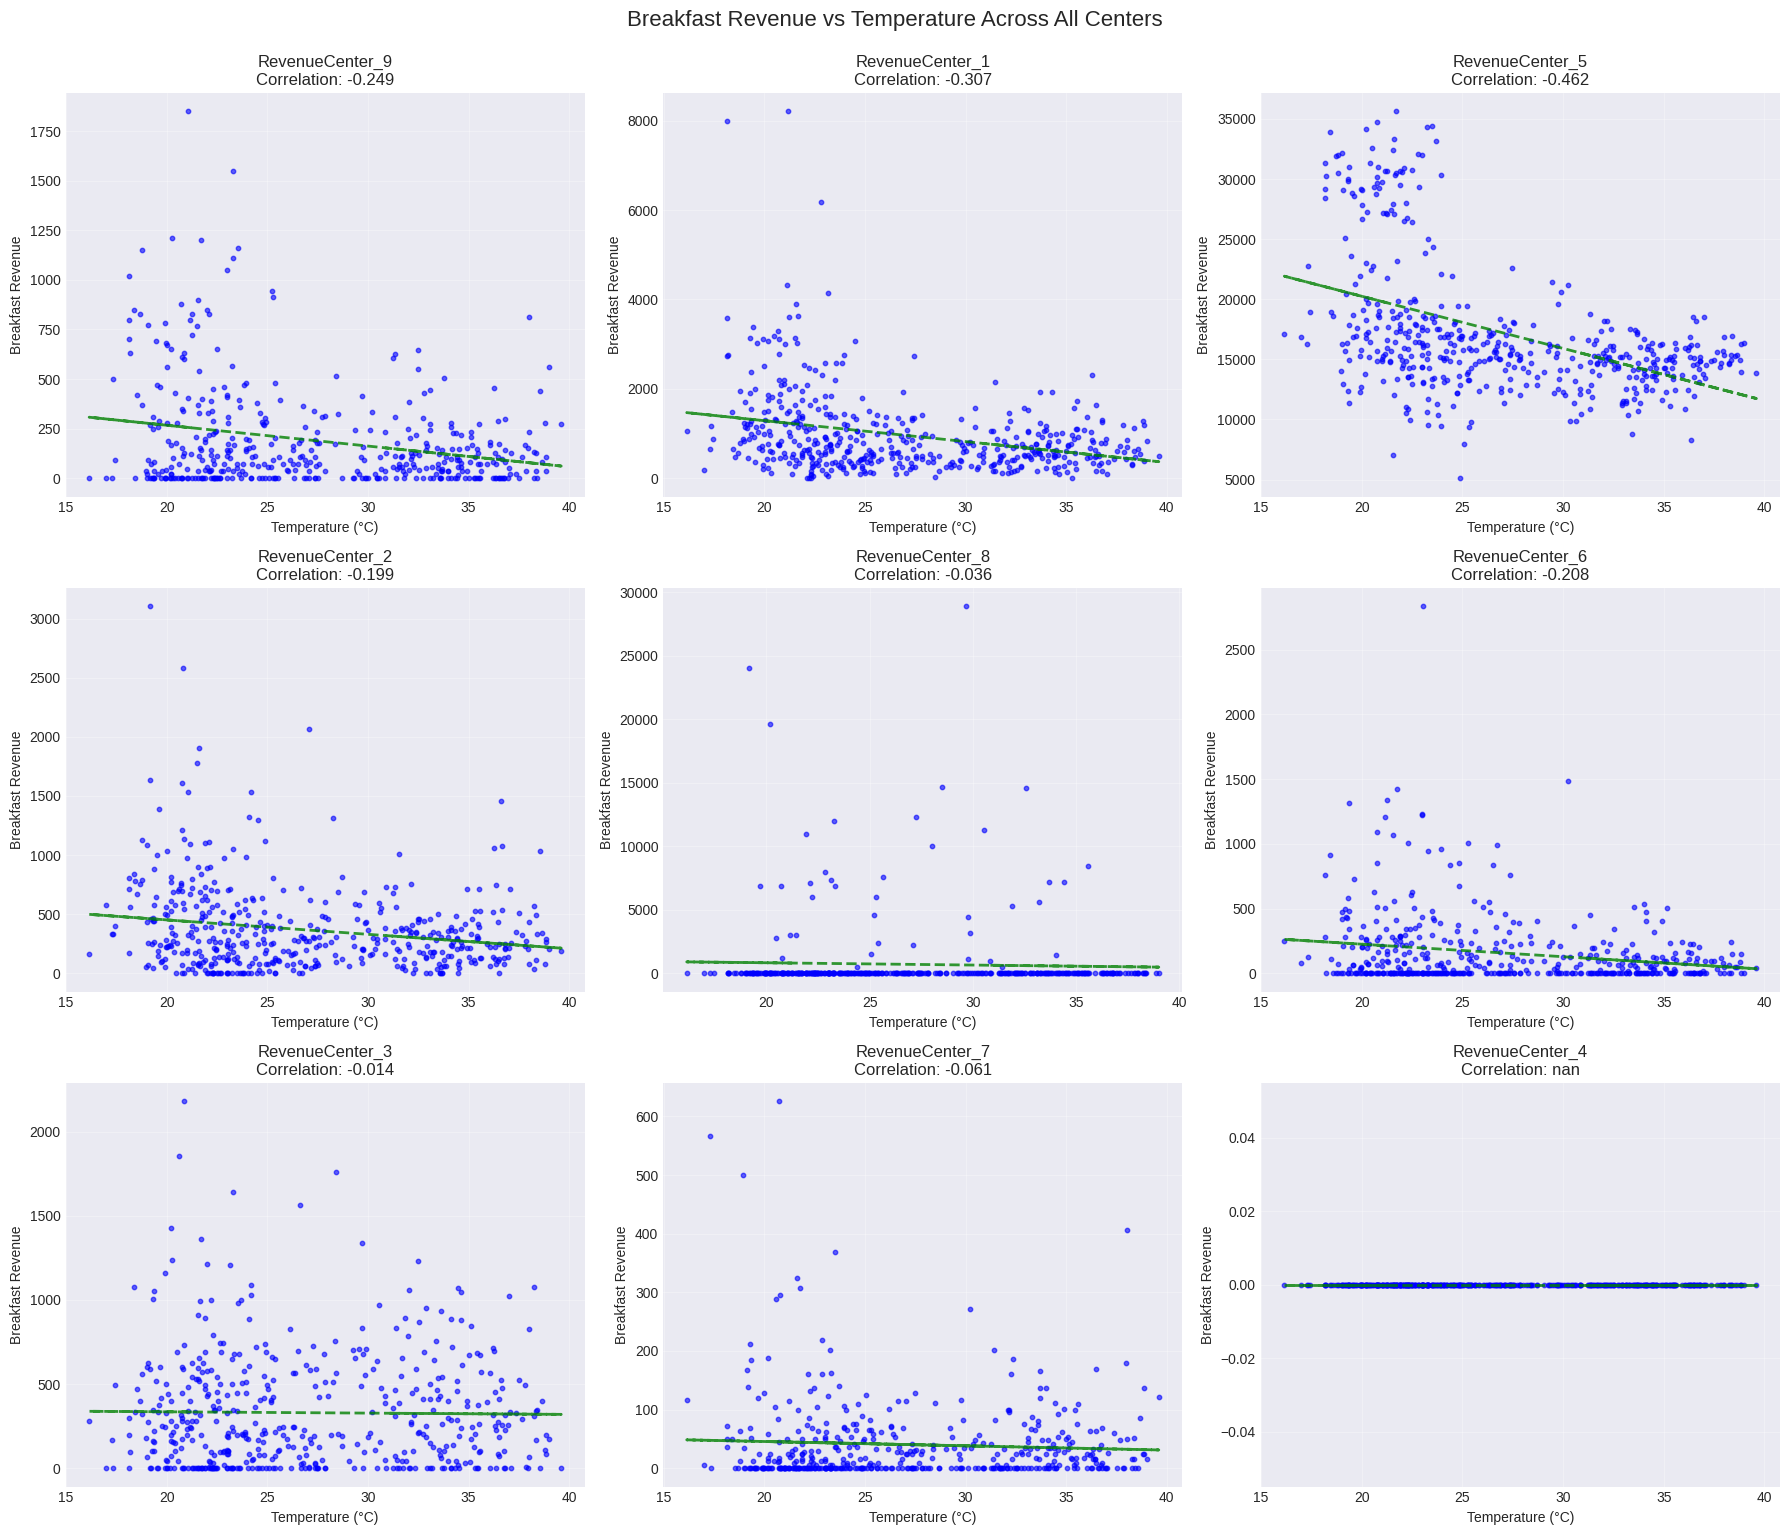

In [ ]:
# Breakfast vs Temperature Comparison
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()   # [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8] convert in to list, easy for using in loops

for idx, (dataset_name, df) in enumerate(datasets.items()):  # items returns pairs: ("Breakfast", df_breakfast)
    if idx >= 9:
        break

    ax = axes[idx]

    # Check if columns exist
    if 'BreakFast' in df.columns and 'average_temperature' in df.columns:
        # Scatter plot
        ax.scatter(df['average_temperature'], df['BreakFast'], alpha=0.6, s=10, color="blue") # to draw seperate plots for each sub plot

        # Add trend line
        z = np.polyfit(df['average_temperature'], df['BreakFast'], 1)  # get the best linear line
        p = np.poly1d(z)  # creates a function for the line.
        ax.plot(df['average_temperature'], p(df['average_temperature']),
                "g--", alpha=0.8, linewidth=2)      # r for red

        # Calculate correlation
        correlation = df['BreakFast'].corr(df['average_temperature'])

        ax.set_xlabel('Temperature (°C)')
        ax.set_ylabel('Breakfast Revenue')
        ax.set_title(f'{dataset_name}\nCorrelation: {correlation:.3f}')

        # Add grid
        ax.grid(True, alpha=0.3)    # alpha for transparancy
    else:
        ax.text(0.5, 0.5, 'Columns not found',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{dataset_name}')

plt.tight_layout()
plt.suptitle('Breakfast Revenue vs Temperature Across All Centers',
             fontsize=16, y=1.02)
plt.show()

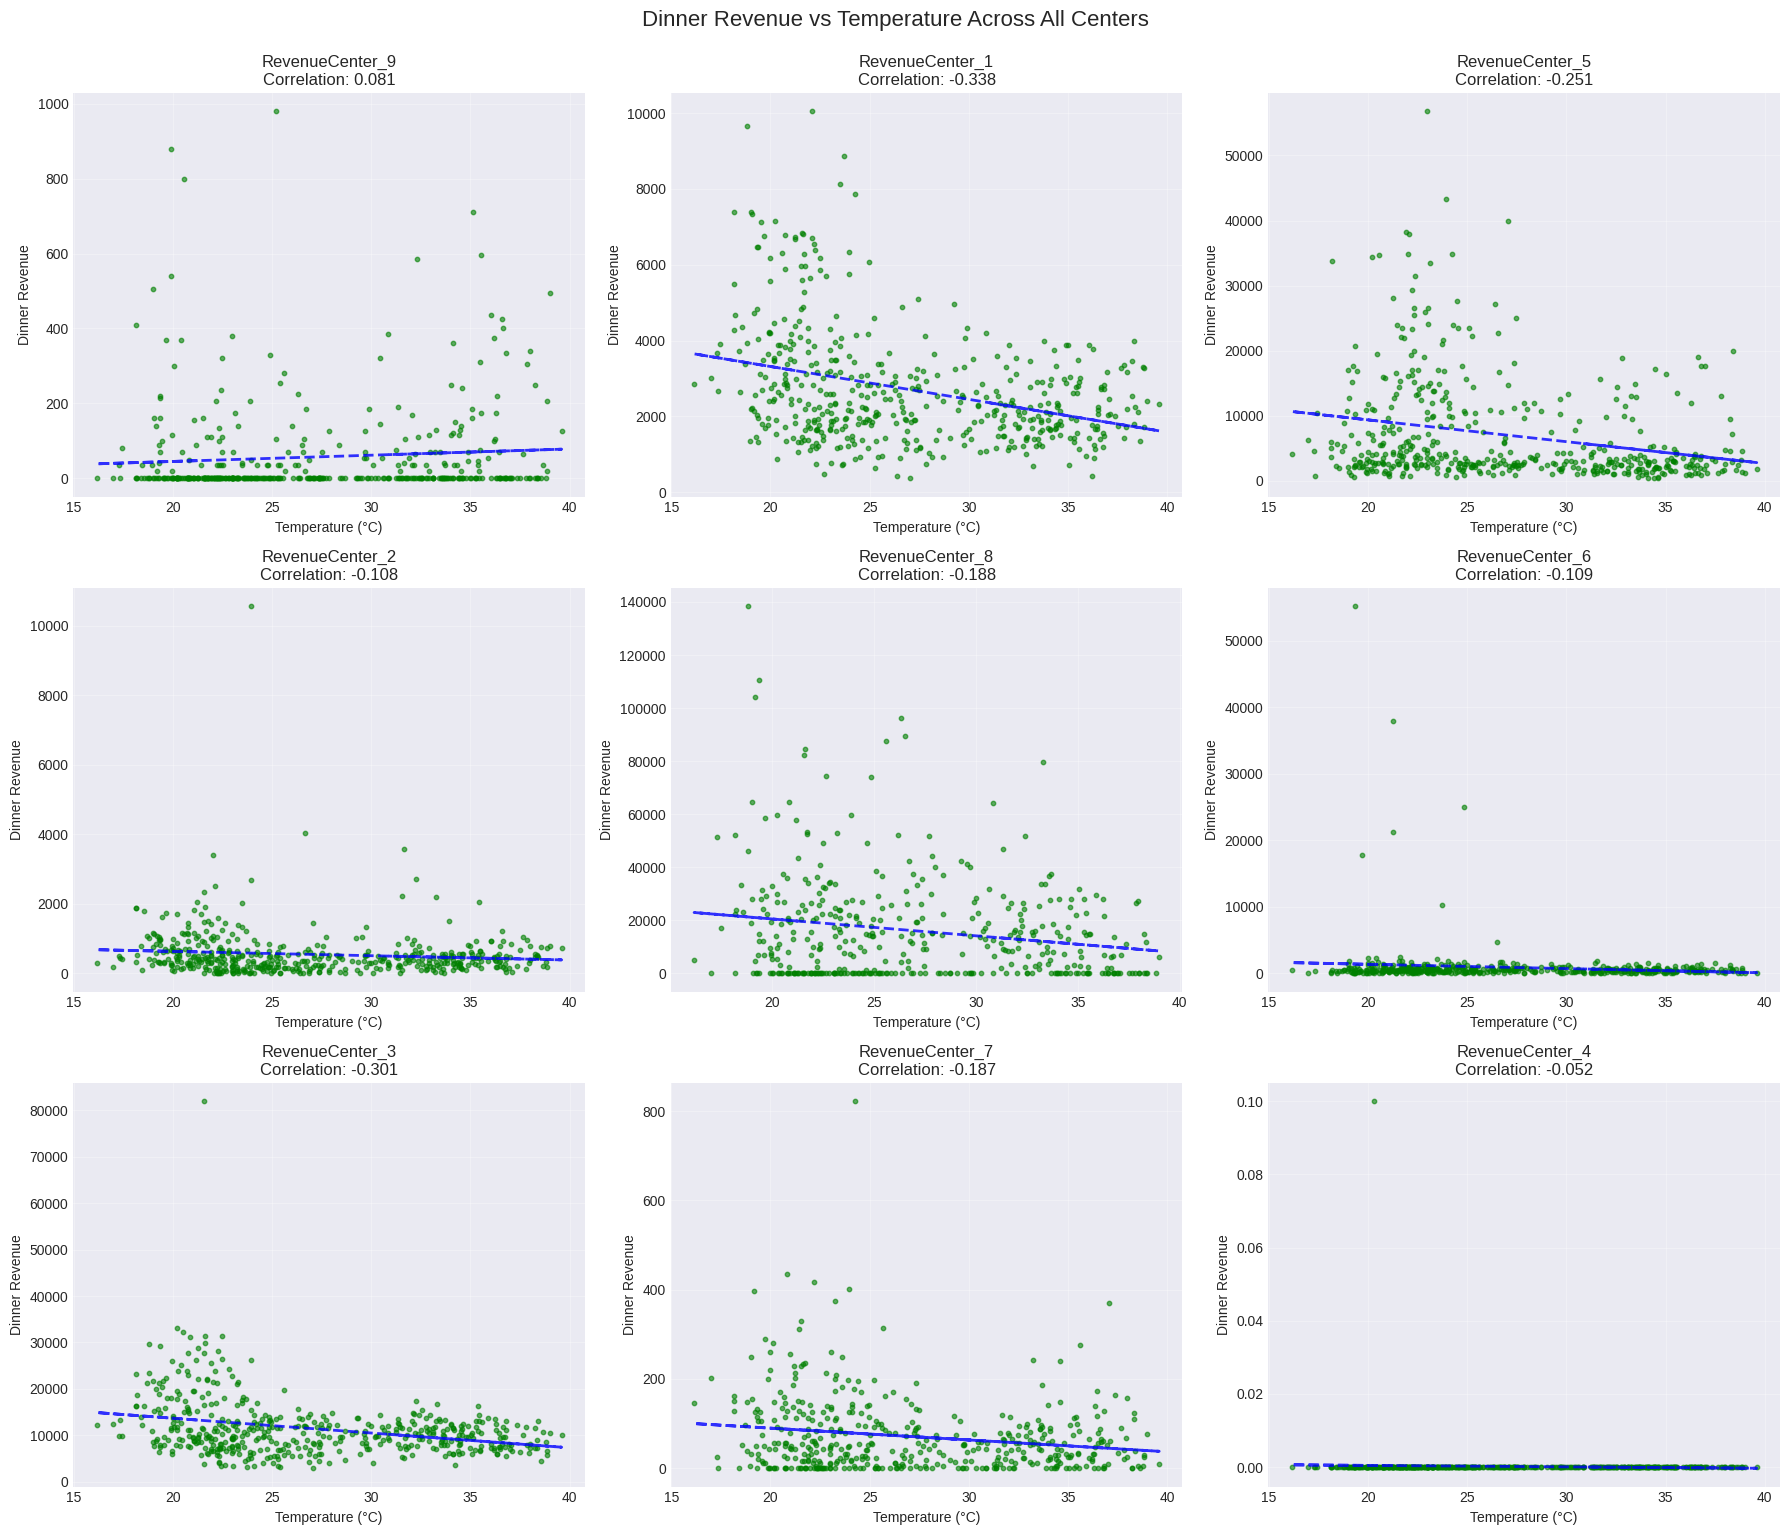

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets.items()):
    if idx >= 9:
        break

    ax = axes[idx]

    # Skip if required columns missing
    if not {'Dinner', 'average_temperature'}.issubset(df.columns):
        ax.text(0.5, 0.5, "Columns missing", ha='center')
        ax.set_title(name)
        continue

    x = df['average_temperature']
    y = df['Dinner']

    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=10, color='green')

    # Trend line
    z = np.polyfit(x, y, 1)
    ax.plot(x, np.poly1d(z)(x), "b--", alpha=0.8, linewidth=2)

    # Correlation
    corr = y.corr(x)

    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Dinner Revenue")
    ax.set_title(f"{name}\nCorrelation: {corr:.3f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Dinner Revenue vs Temperature Across All Centers", fontsize=16, y=1.02)
plt.show()


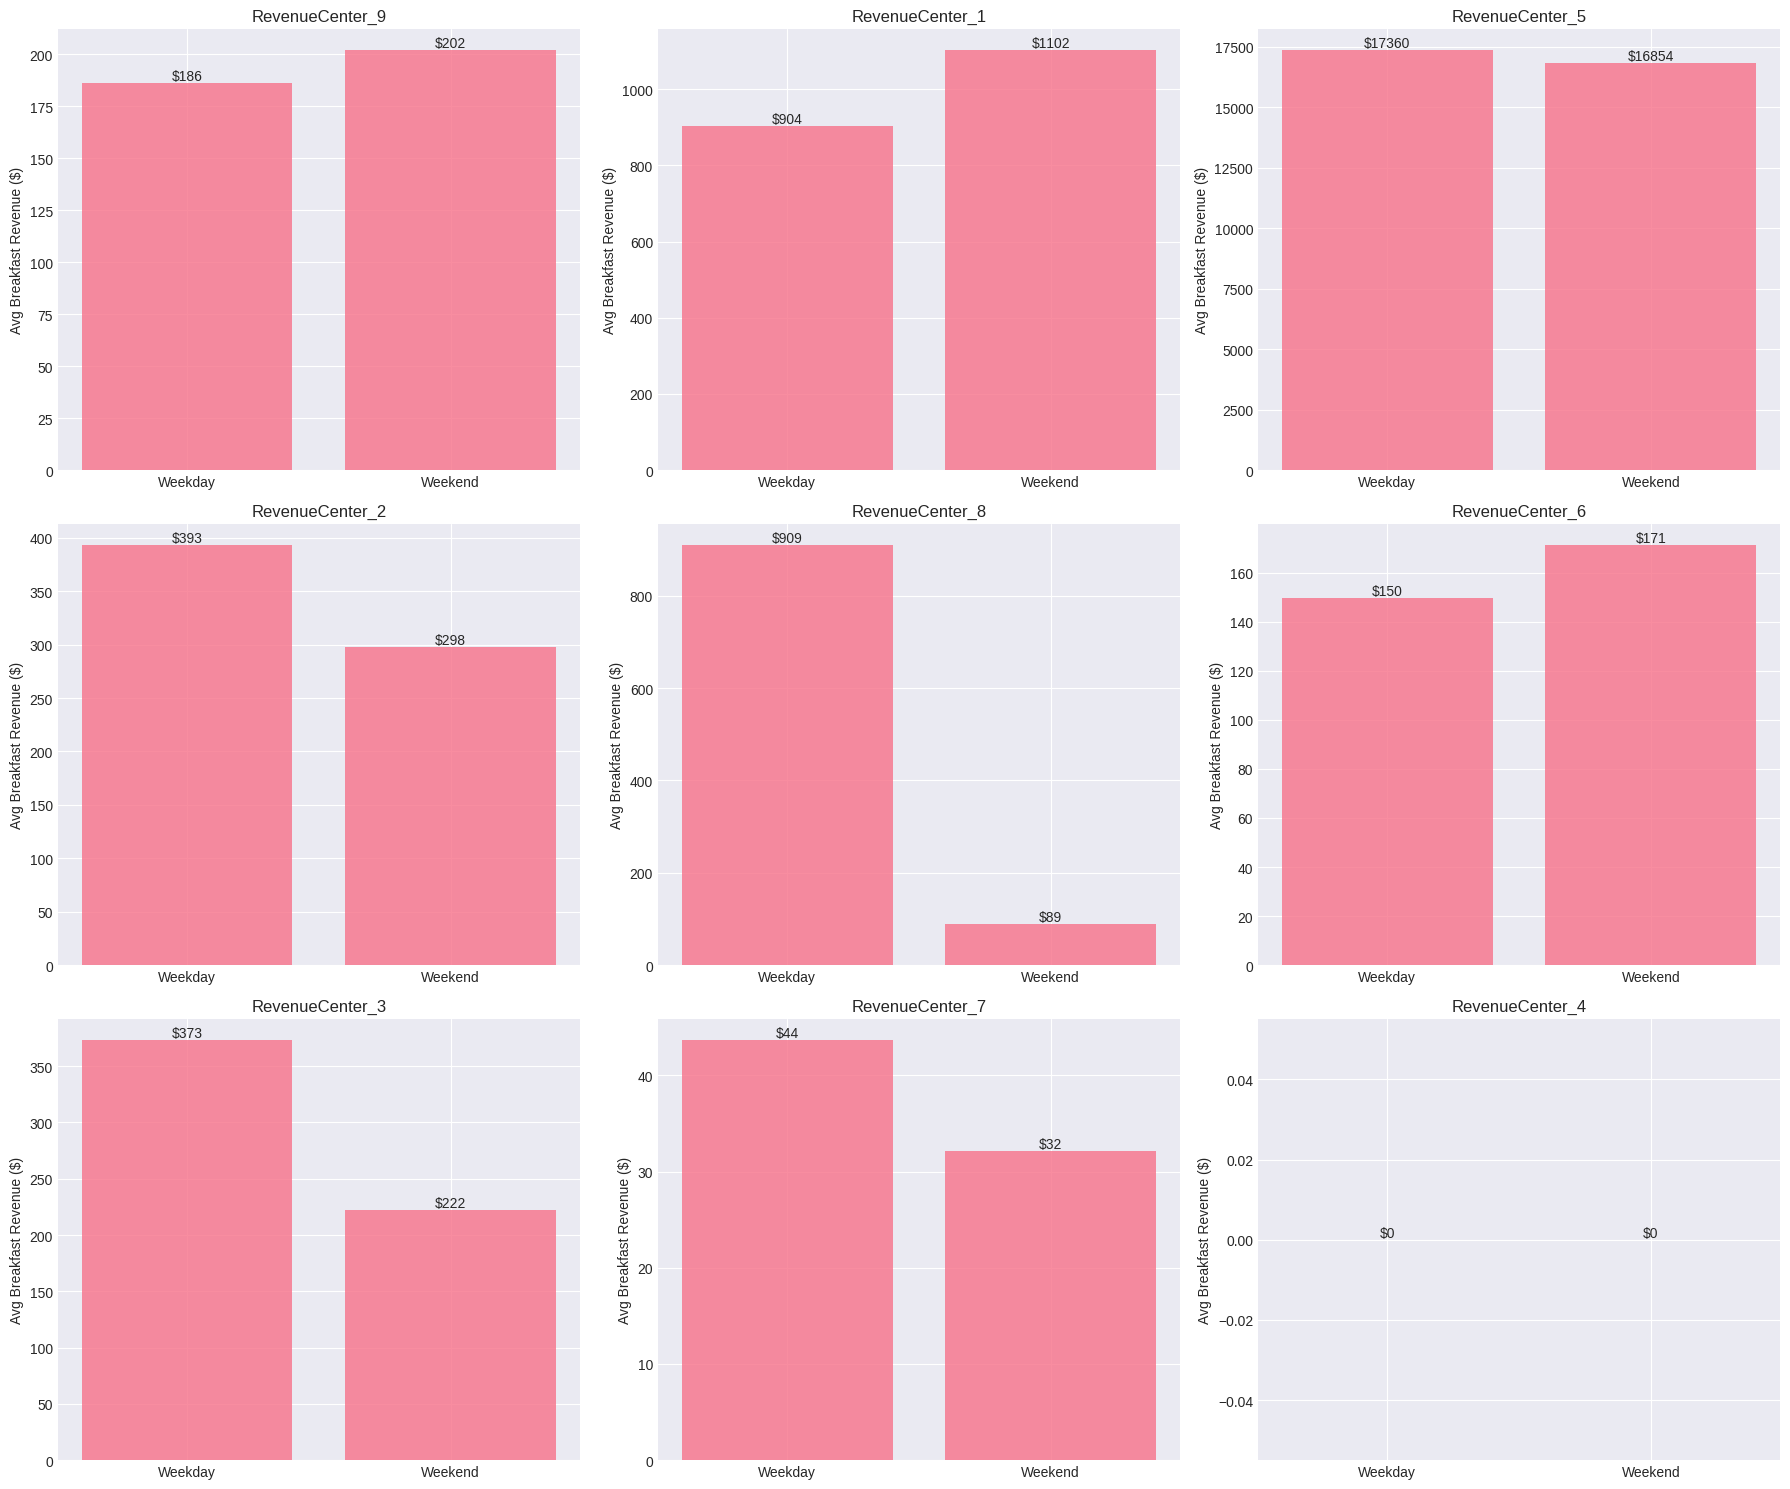

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets.items()):
    if idx >= 9:
        break

    ax = axes[idx]

    # Skip if required columns missing
    if not {'BreakFast', 'IsWeekend'}.issubset(df.columns):
        ax.text(0.5, 0.5, "Columns missing", ha='center')
        ax.set_title(name)
        continue

    # Average revenue for weekday vs weekend
    weekend_avg = df.groupby('IsWeekend')['BreakFast'].mean()

    # Bar plot
    ax.bar(['Weekday', 'Weekend'], weekend_avg.values, alpha=0.8)

    # Label bars
    for x, y in zip(['Weekday','Weekend'], weekend_avg.values):
        ax.text(x, y, f"${y:.0f}", ha='center', va='bottom')

    ax.set_title(name)
    ax.set_ylabel("Avg Breakfast Revenue ($)")

plt.tight_layout()
plt.show()


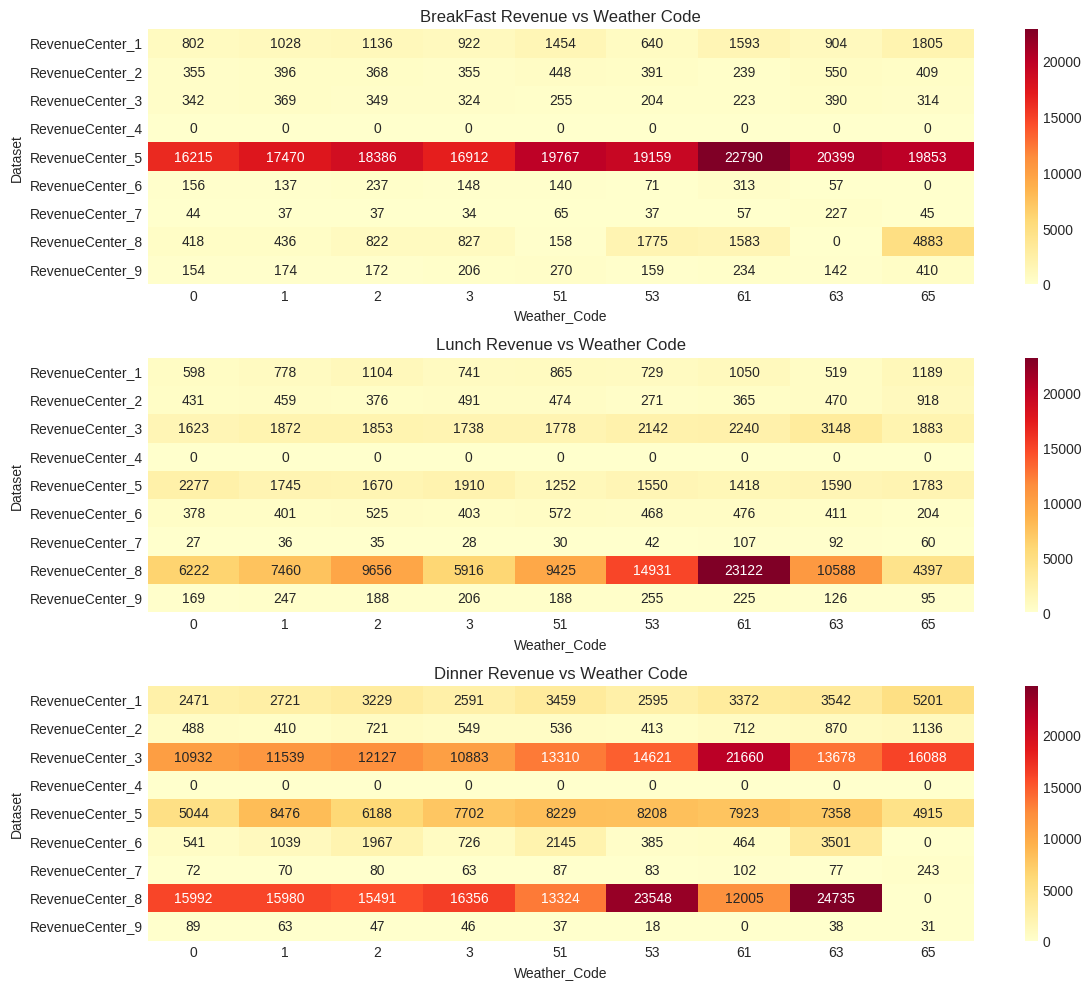

In [ ]:
weather_rows = []

# Build summary rows
for name, df in datasets.items():
    if 'weather_code' not in df.columns:
        continue

    for meal in ['BreakFast', 'Lunch', 'Dinner']:
        if meal not in df.columns:
            continue

        grouped = df.groupby('weather_code')[meal].mean()

        for wcode, avg in grouped.items():
            weather_rows.append([name, meal, wcode, avg])

# Convert to DataFrame
weather_df = pd.DataFrame(weather_rows,
                          columns=['Dataset', 'Meal', 'Weather_Code', 'Avg_Revenue'])

# Plot heatmaps
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, meal in enumerate(['BreakFast', 'Lunch', 'Dinner']):
    meal_data = weather_df[weather_df['Meal'] == meal]

    if meal_data.empty:
        continue

    pivot = meal_data.pivot(index='Dataset',
                            columns='Weather_Code',
                            values='Avg_Revenue')

    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[i])
    axes[i].set_title(f"{meal} Revenue vs Weather Code")

plt.tight_layout()
plt.show()


In [ ]:
# Overall correlations with TotalRevenue
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# CONFIGURATION - Using Colab's temporary storage
folder_path = '/content/data_sets'  # Colab path
pattern = "RevenueCenter_*.xlsx"

# Check if folder exists
if not os.path.exists(folder_path):
    print(f"Error: Folder '{folder_path}' does not exist.")
    print("Please make sure you have saved the Excel files to this location first.")
    print("\nYou can save files using:")
    print("output_dir = '/content/data_sets'")
    print("os.makedirs(output_dir, exist_ok=True)")
    print("# ... save your files ...")
else:
    # LOAD AND PROCESS ALL FILES
    file_list = glob.glob(os.path.join(folder_path, pattern))

    if not file_list:
        print(f"No files found matching pattern: {pattern}")
        print(f"Available files in {folder_path}:")
        if os.path.exists(folder_path):
            for f in os.listdir(folder_path):
                print(f"  - {f}")
        # Try loading all Excel files
        file_list = glob.glob(os.path.join(folder_path, "*.xlsx"))
        if file_list:
            print(f"\nFound {len(file_list)} Excel file(s). Processing...")

    if file_list:
        for file in file_list:
            # Extract center name from filename
            filename = os.path.basename(file)
            center_name = filename.replace('.xlsx', '')
            print(f"\nProcessing: {center_name}")

            try:
                df = pd.read_excel(file)

                # --- Feature Engineering ---
                # Check if Date column exists
                if 'Date' in df.columns:
                    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
                else:
                    print(f"  Warning: 'Date' column not found in {center_name}")

                # Check if meal columns exist
                meal_columns = ['BreakFast', 'Lunch', 'Dinner']
                existing_meals = [col for col in meal_columns if col in df.columns]

                if existing_meals:
                    df['TotalRevenue'] = df[existing_meals].sum(axis=1)

                    # --- Correlation Analysis (only vs TotalRevenue) ---
                    # Define all possible features
                    possible_features = ['BreakFast', 'Lunch', 'Dinner',
                                       'IsWeekend', 'IsHoliday',
                                       'average_temperature', 'weather_code',
                                       'Day_Monday', 'Day_Tuesday', 'Day_Wednesday',
                                       'Day_Thursday', 'Day_Friday', 'Day_Saturday', 'Day_Sunday']

                    # Keep only features that exist in the dataframe
                    corr_features = [feat for feat in possible_features if feat in df.columns]

                    correlations = {}
                    for feat in corr_features:
                        correlations[feat] = df['TotalRevenue'].corr(df[feat])

                    # Print all correlations
                    print(f"\nCorrelation values with TotalRevenue for {center_name}:")
                    for feat, val in correlations.items():
                        print(f"  TotalRevenue vs {feat}: {val:.4f}")

                    # --- Top 5 strongest correlations ---
                    sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
                    print(f"\nTop 5 strongest correlations with TotalRevenue for {center_name}:")
                    for feat, val in sorted_corr[:5]:
                        print(f"  TotalRevenue vs {feat}: {val:.4f}")

                    print(f"\n" + "-" * 80)

                    # --- Save heatmap (only vs TotalRevenue) ---
                    corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
                    plt.figure(figsize=(8, 10))
                    sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".3f",
                                cbar=True, center=0, square=True, linewidths=0.5)
                    plt.title(f"Correlations with TotalRevenue - {center_name}", fontsize=14, pad=20)
                    plt.xlabel('')
                    plt.tight_layout()

                    # Save the plot
                    plot_filename = f"{center_name}_totalRevenue_correlation.png"
                    plot_path = os.path.join(folder_path, plot_filename)
                    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
                    plt.close()

                    print(f"  Saved correlation plot: {plot_filename}")

                else:
                    print(f"  Error: No meal columns found in {center_name}")

            except Exception as e:
                print(f"  Error processing {center_name}: {str(e)}")

        print(f"\nProcess completed!")
        print(f"Correlation plots saved in: {folder_path}")

        # Display saved plots
        print("\nSaved correlation plots:")
        png_files = glob.glob(os.path.join(folder_path, "*_correlation.png"))
        for png in png_files:
            print(f"  - {os.path.basename(png)}")

    else:
        print("No Excel files found to process.")


Processing: RevenueCenter_9

Correlation values with TotalRevenue for RevenueCenter_9:
  TotalRevenue vs BreakFast: 0.7390
  TotalRevenue vs Lunch: 0.5421
  TotalRevenue vs Dinner: 0.3113
  TotalRevenue vs IsWeekend: 0.1008
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.1455
  TotalRevenue vs weather_code: 0.0201
  TotalRevenue vs Day_Monday: -0.0246
  TotalRevenue vs Day_Tuesday: -0.0425
  TotalRevenue vs Day_Wednesday: -0.0058
  TotalRevenue vs Day_Thursday: 0.0132
  TotalRevenue vs Day_Friday: -0.0722
  TotalRevenue vs Day_Saturday: 0.0852
  TotalRevenue vs Day_Sunday: 0.0446

Top 5 strongest correlations with TotalRevenue for RevenueCenter_9:
  TotalRevenue vs BreakFast: 0.7390
  TotalRevenue vs Lunch: 0.5421
  TotalRevenue vs Dinner: 0.3113
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.1455

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Saved correlation plot: RevenueCenter_9_totalRevenue_correlation.png

Processing: RevenueCenter_1

Correlation values with TotalRevenue for RevenueCenter_1:
  TotalRevenue vs BreakFast: 0.7333
  TotalRevenue vs Lunch: 0.7214
  TotalRevenue vs Dinner: 0.9005
  TotalRevenue vs IsWeekend: 0.0218
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.3746
  TotalRevenue vs weather_code: 0.1782
  TotalRevenue vs Day_Monday: -0.0143
  TotalRevenue vs Day_Tuesday: -0.0161
  TotalRevenue vs Day_Wednesday: -0.0484
  TotalRevenue vs Day_Thursday: 0.0607
  TotalRevenue vs Day_Friday: -0.0101
  TotalRevenue vs Day_Saturday: 0.0139
  TotalRevenue vs Day_Sunday: 0.0143

Top 5 strongest correlations with TotalRevenue for RevenueCenter_1:
  TotalRevenue vs Dinner: 0.9005
  TotalRevenue vs BreakFast: 0.7333
  TotalRevenue vs Lunch: 0.7214
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.3746

---------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Saved correlation plot: RevenueCenter_1_totalRevenue_correlation.png

Processing: RevenueCenter_5

Correlation values with TotalRevenue for RevenueCenter_5:
  TotalRevenue vs BreakFast: 0.6392
  TotalRevenue vs Lunch: 0.2643
  TotalRevenue vs Dinner: 0.7780
  TotalRevenue vs IsWeekend: -0.0012
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.4264
  TotalRevenue vs weather_code: 0.1059
  TotalRevenue vs Day_Monday: -0.0914
  TotalRevenue vs Day_Tuesday: -0.0726
  TotalRevenue vs Day_Wednesday: -0.0462
  TotalRevenue vs Day_Thursday: -0.0678
  TotalRevenue vs Day_Friday: 0.2805
  TotalRevenue vs Day_Saturday: 0.0780
  TotalRevenue vs Day_Sunday: -0.0790

Top 5 strongest correlations with TotalRevenue for RevenueCenter_5:
  TotalRevenue vs Dinner: 0.7780
  TotalRevenue vs BreakFast: 0.6392
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.4264
  TotalRevenue vs Day_Friday: 0.2805

--------------------------------------------------------

...

  Saved correlation plot: RevenueCenter_3_totalRevenue_correlation.png

Processing: RevenueCenter_7

Correlation values with TotalRevenue for RevenueCenter_7:
  TotalRevenue vs BreakFast: 0.5849
  TotalRevenue vs Lunch: 0.4508
  TotalRevenue vs Dinner: 0.6820
  TotalRevenue vs IsWeekend: -0.0412
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.2070
  TotalRevenue vs weather_code: 0.2269
  TotalRevenue vs Day_Monday: -0.0556
  TotalRevenue vs Day_Tuesday: 0.0309
  TotalRevenue vs Day_Wednesday: 0.0000
  TotalRevenue vs Day_Thursday: 0.0062
  TotalRevenue vs Day_Friday: 0.0718
  TotalRevenue vs Day_Saturday: -0.0311
  TotalRevenue vs Day_Sunday: -0.0219

Top 5 strongest correlations with TotalRevenue for RevenueCenter_7:
  TotalRevenue vs Dinner: 0.6820
  TotalRevenue vs BreakFast: 0.5849
  TotalRevenue vs Lunch: 0.4508
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs weather_code: 0.2269

-----------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Saved correlation plot: RevenueCenter_7_totalRevenue_correlation.png

Processing: RevenueCenter_4

Correlation values with TotalRevenue for RevenueCenter_4:
  TotalRevenue vs BreakFast: nan
  TotalRevenue vs Lunch: nan
  TotalRevenue vs Dinner: 1.0000
  TotalRevenue vs IsWeekend: -0.0292
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs average_temperature: -0.0517
  TotalRevenue vs weather_code: -0.0200
  TotalRevenue vs Day_Monday: -0.0186
  TotalRevenue vs Day_Tuesday: -0.0188
  TotalRevenue vs Day_Wednesday: -0.0186
  TotalRevenue vs Day_Thursday: -0.0186
  TotalRevenue vs Day_Friday: 0.1134
  TotalRevenue vs Day_Saturday: -0.0186
  TotalRevenue vs Day_Sunday: -0.0190

Top 5 strongest correlations with TotalRevenue for RevenueCenter_4:
  TotalRevenue vs BreakFast: nan
  TotalRevenue vs Lunch: nan
  TotalRevenue vs Dinner: 1.0000
  TotalRevenue vs IsHoliday: nan
  TotalRevenue vs Day_Friday: 0.1134

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Saved correlation plot: RevenueCenter_4_totalRevenue_correlation.png

Process completed!
Correlation plots saved in: /content/data_sets

Saved correlation plots:
  - RevenueCenter_4_totalRevenue_correlation.png
  - RevenueCenter_2_totalRevenue_correlation.png
  - RevenueCenter_3_totalRevenue_correlation.png
  - RevenueCenter_9_totalRevenue_correlation.png
  - RevenueCenter_5_totalRevenue_correlation.png
  - RevenueCenter_7_totalRevenue_correlation.png
  - RevenueCenter_1_totalRevenue_correlation.png
  - RevenueCenter_6_totalRevenue_correlation.png
  - RevenueCenter_8_totalRevenue_correlation.png


Found 9 files

Processing → RevenueCenter_9

Training → BreakFast

BreakFast Validation
  MAE  : 416.82
  RMSE : 545.10
  R²   : -1.001
  MAPE : 83.67%

BreakFast Test
  MAE  : 228.59
  RMSE : 342.29
  R²   : -0.256
  MAPE : 80.26%

Training → Lunch

Lunch Validation
  MAE  : 207.09
  RMSE : 265.15
  R²   : -0.101
  MAPE : 83.67%

Lunch Test
  MAE  : 174.74
  RMSE : 251.87
  R²   : -0.338
  MAPE : 130.65%

Training → Dinner

Dinner Validation
  MAE  : 202.79
  RMSE : 261.81
  R²   : -11.951
  MAPE : 159.11%

Dinner Test
  MAE  : 118.20
  RMSE : 204.77
  R²   : -0.334
  MAPE : 176.83%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
363 2024-03-01              80.0      100.999924           250  587.222717   
364 2024-03-02             370.0      107.773170           140  196.532089   
365 2024-03-03             800.0       83.823280           650   65.681557   
366 2024-03-04             540.0      199.150940           510 

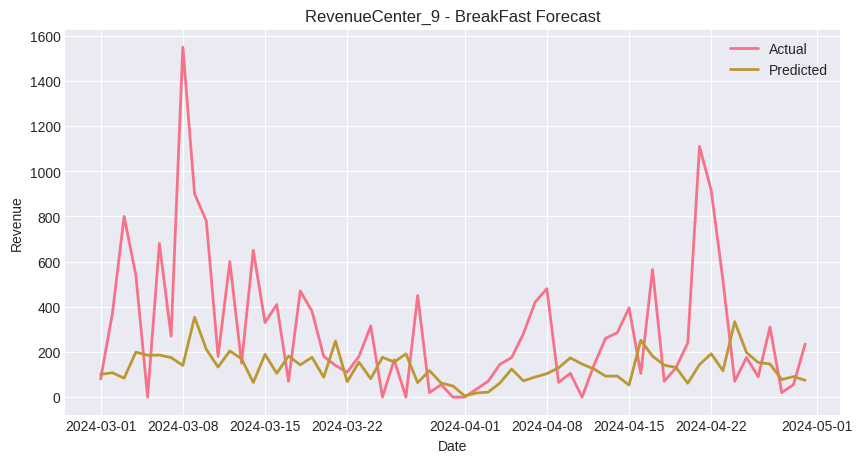

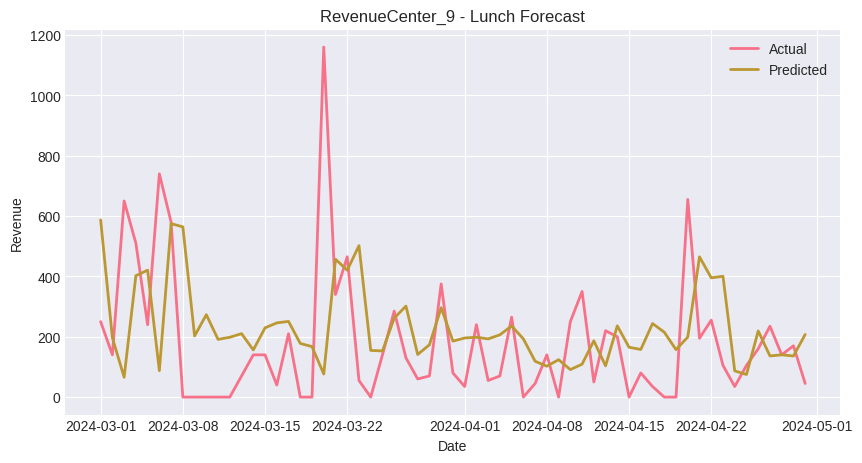

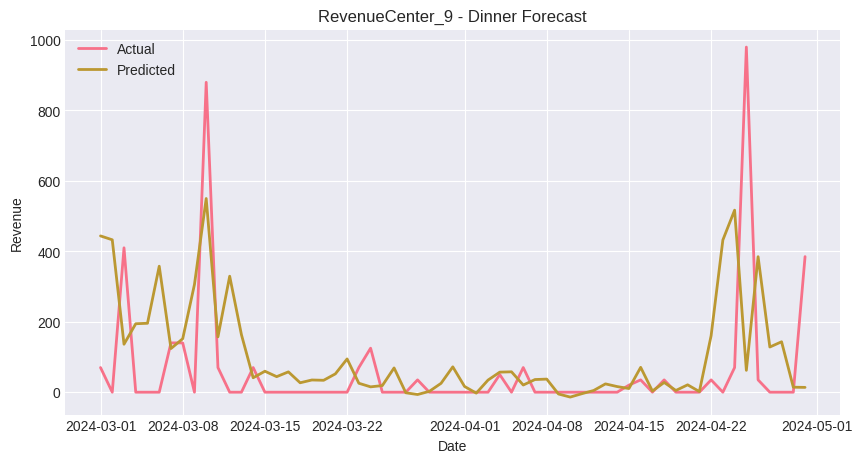

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_1

Training → BreakFast

BreakFast Validation
  MAE  : 1203.28
  RMSE : 1698.13
  R²   : -0.635
  MAPE : 46.22%

BreakFast Test
  MAE  : 658.34
  RMSE : 1216.54
  R²   : 0.013
  MAPE : 97.67%

Training → Lunch

Lunch Validation
  MAE  : 986.77
  RMSE : 1325.94
  R²   : -0.678
  MAPE : 78.99%

Lunch Test
  MAE  : 493.70
  RMSE : 708.87
  R²   : -0.050
  MAPE : 121.01%

Training → Dinner

Dinner Validation
  MAE  : 2489.41
  RMSE : 2948.70
  R²   : -2.262
  MAPE : 42.51%

Dinner Test
  MAE  : 1197.81
  RMSE : 1758.32
  R²   : 0.072
  MAPE : 54.67%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
418 2024-03-01            2372.0     1094.922119        1767.0  981.957092   
419 2024-03-02            1944.0     1333.872681        3482.0  827.049194   
420 2024-03-03            7984.0     1411.292114        3586.0  589.216797   
421 2024-03-04            12

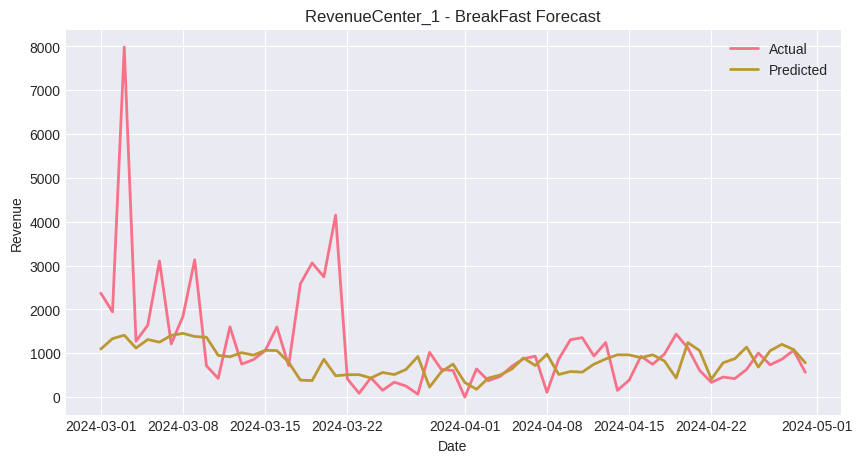

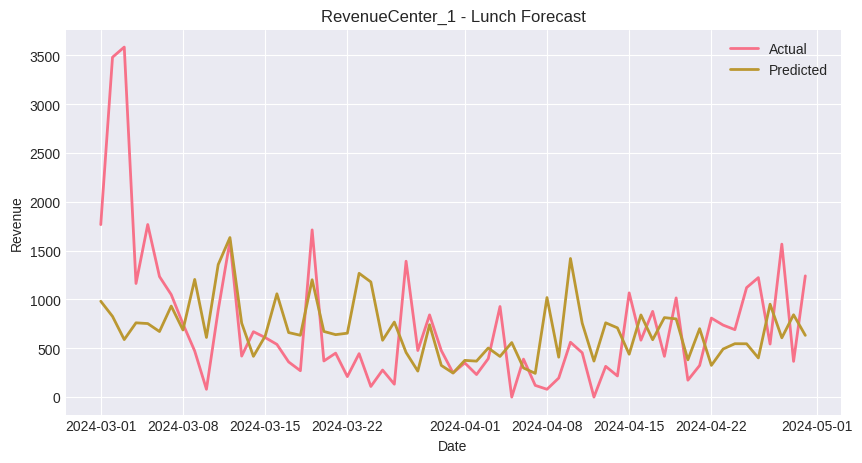

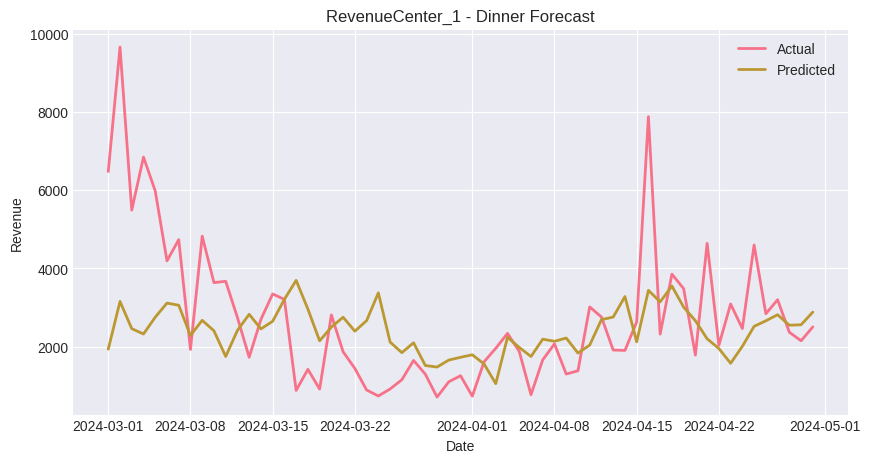

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_5

Training → BreakFast

BreakFast Validation
  MAE  : 13277.93
  RMSE : 13869.67
  R²   : -18.639
  MAPE : 44.53%

BreakFast Test
  MAE  : 4271.45
  RMSE : 5927.54
  R²   : -0.172
  MAPE : 23.30%

Training → Lunch

Lunch Validation
  MAE  : 1837.35
  RMSE : 3032.03
  R²   : -0.270
  MAPE : 75.95%

Lunch Test
  MAE  : 1659.21
  RMSE : 3663.03
  R²   : -0.113
  MAPE : 198.08%

Training → Dinner

Dinner Validation
  MAE  : 8032.94
  RMSE : 11076.35
  R²   : -0.457
  MAPE : 119.25%

Dinner Test
  MAE  : 6153.64
  RMSE : 8720.42
  R²   : 0.364
  MAPE : 64.35%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch   Pred_Lunch  \
418 2024-03-01           30976.0    17301.685547        1830.0  1381.477417   
419 2024-03-02           30478.0    18728.054688       14564.0  1104.553955   
420 2024-03-03           29210.0    18775.931641        2517.0  1558.083130   
421 2024-03-04

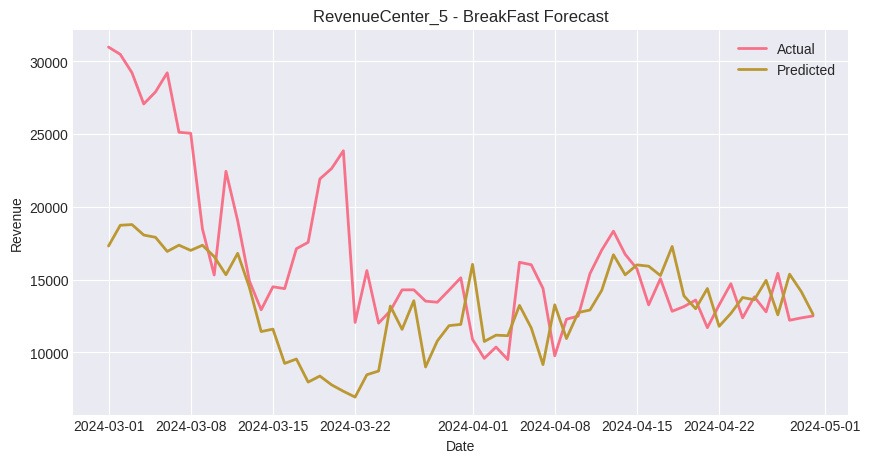

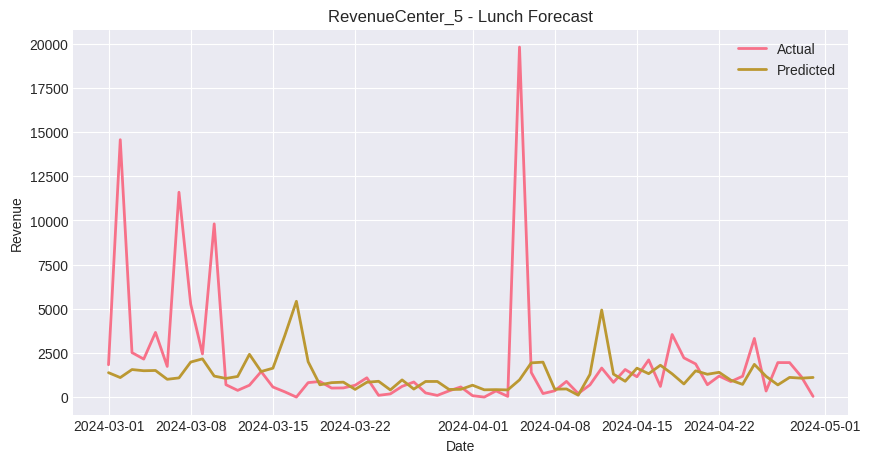

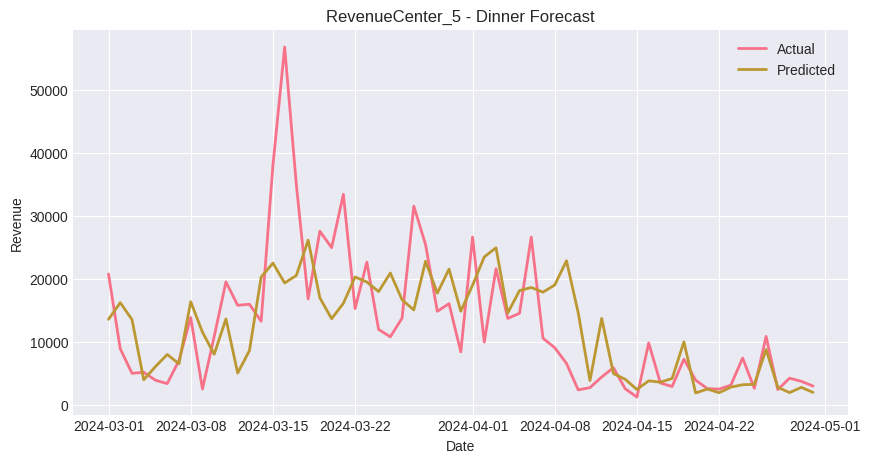

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_2

Training → BreakFast

BreakFast Validation
  MAE  : 337.18
  RMSE : 479.37
  R²   : -0.168
  MAPE : 83.26%

BreakFast Test
  MAE  : 383.08
  RMSE : 587.75
  R²   : -0.390
  MAPE : 182.63%

Training → Lunch

Lunch Validation
  MAE  : 456.37
  RMSE : 651.30
  R²   : -0.491
  MAPE : 77.04%

Lunch Test
  MAE  : 421.83
  RMSE : 938.65
  R²   : 0.037
  MAPE : 151.15%

Training → Dinner

Dinner Validation
  MAE  : 762.86
  RMSE : 1536.46
  R²   : -0.311
  MAPE : 76.48%

Dinner Test
  MAE  : 368.89
  RMSE : 582.95
  R²   : 0.093
  MAPE : 206.71%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
416 2024-03-01             438.0      294.453156         330.0  433.162415   
417 2024-03-02            1129.0      264.897430        1274.0  397.181396   
418 2024-03-03             709.0      502.333801         574.0  545.184509   
419 2024-03-04            1910.0 

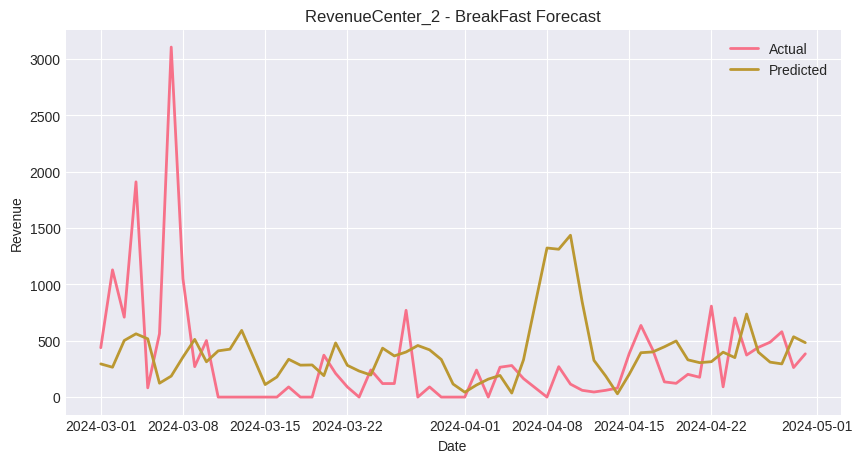

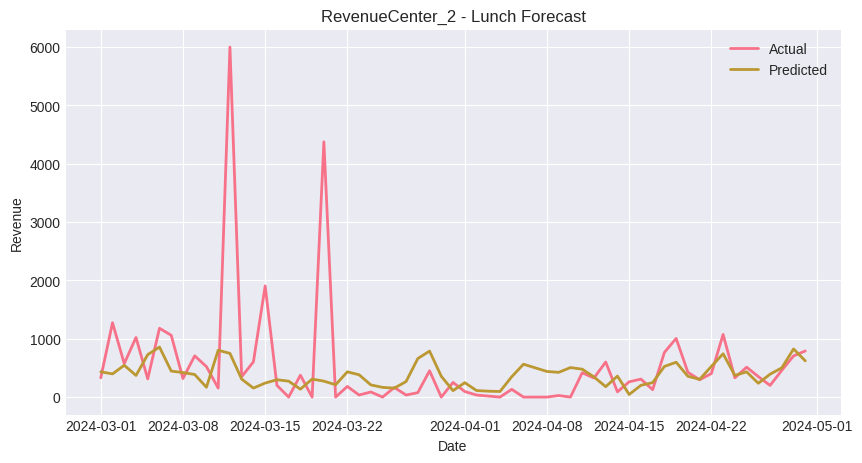

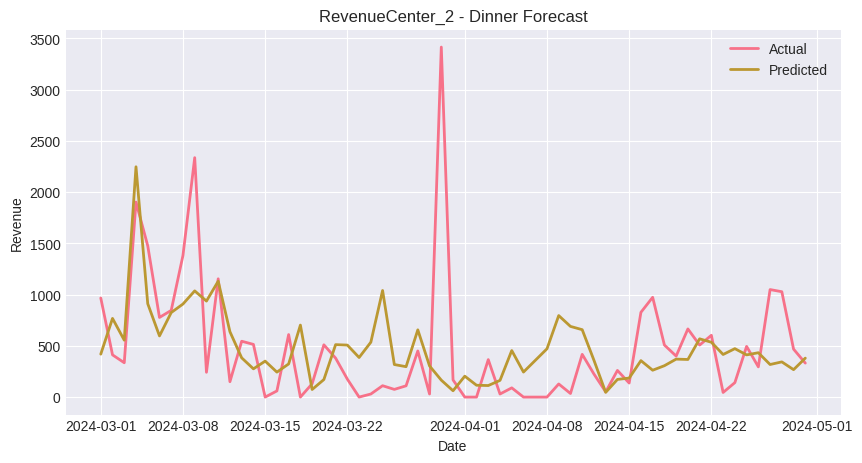

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_8

Training → BreakFast

BreakFast Validation
  MAE  : 1862.98
  RMSE : 2544.84
  R²   : -3.657
  MAPE : 90.43%

BreakFast Test
  MAE  : 2411.81
  RMSE : 4460.87
  R²   : -0.326
  MAPE : 80.75%

Training → Lunch

Lunch Validation
  MAE  : 16015.92
  RMSE : 23986.14
  R²   : -0.167
  MAPE : 66.17%

Lunch Test
  MAE  : 9169.84
  RMSE : 16833.52
  R²   : 0.092
  MAPE : 130.84%

Training → Dinner

Dinner Validation
  MAE  : 20993.60
  RMSE : 29904.37
  R²   : -0.127
  MAPE : 57.68%

Dinner Test
  MAE  : 16089.41
  RMSE : 24716.34
  R²   : 0.009
  MAPE : 80.84%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch    Pred_Lunch  \
348 2024-03-01                 0     1356.721558        5600.0   7068.494629   
349 2024-03-02                 0     5295.014648           0.0  -1822.242188   
350 2024-03-03                 0     4884.660645       13000.0  23159.173828   
351 2024-

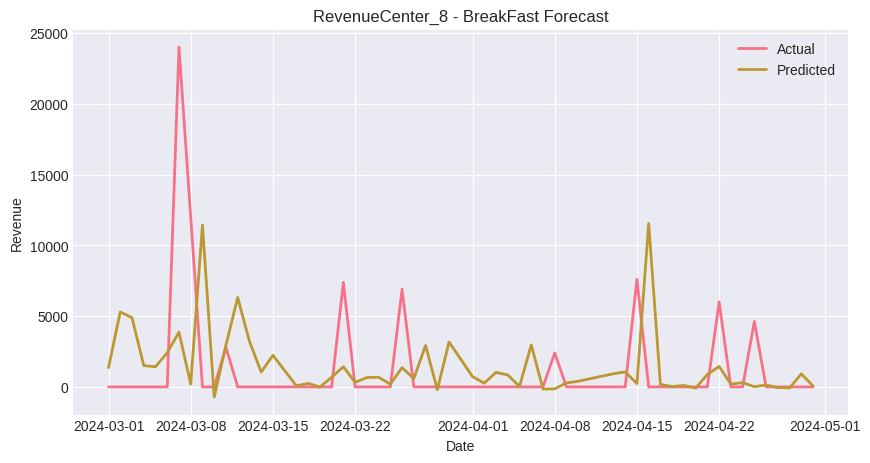

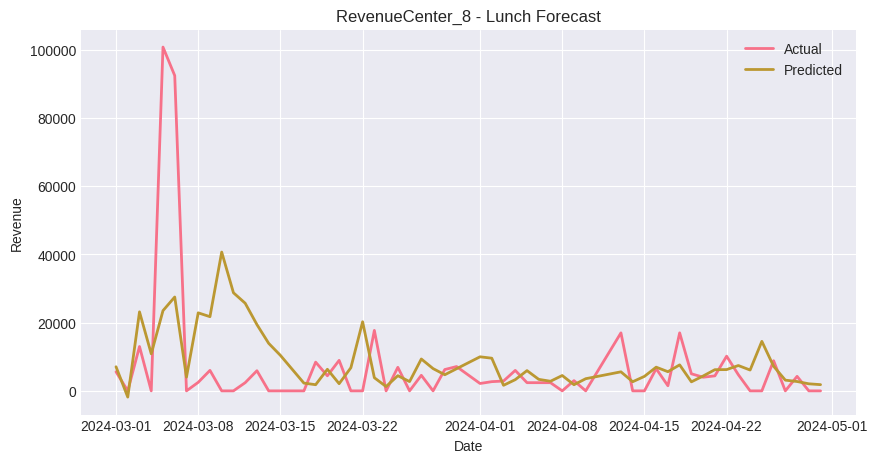

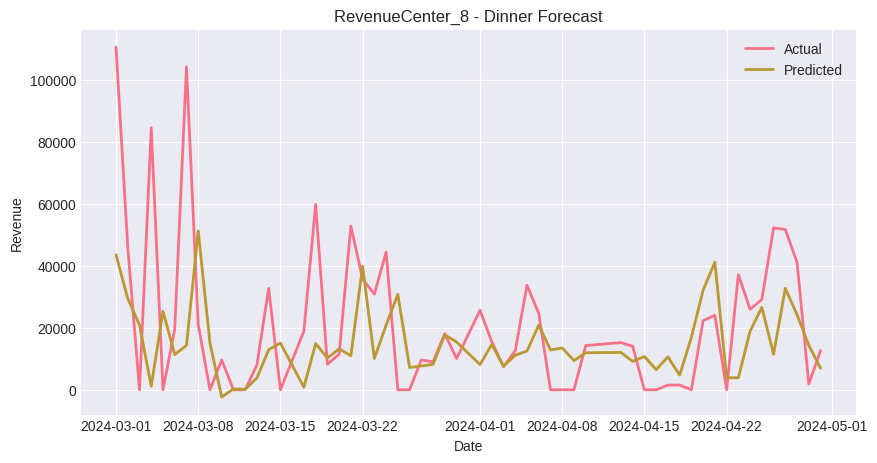

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_6

Training → BreakFast

BreakFast Validation
  MAE  : 289.23
  RMSE : 361.52
  R²   : -0.246
  MAPE : 107.28%

BreakFast Test
  MAE  : 238.56
  RMSE : 447.26
  R²   : 0.059
  MAPE : 141.43%

Training → Lunch

Lunch Validation
  MAE  : 511.28
  RMSE : 743.96
  R²   : -0.372
  MAPE : 87.73%

Lunch Test
  MAE  : 437.48
  RMSE : 784.71
  R²   : 0.003
  MAPE : 136.20%

Training → Dinner

Dinner Validation
  MAE  : 1667.08
  RMSE : 5598.62
  R²   : -0.343
  MAPE : 183.69%

Dinner Test
  MAE  : 1673.98
  RMSE : 7421.15
  R²   : -0.044
  MAPE : 304.69%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch   Pred_Lunch  \
413 2024-03-01            1316.0      121.484718         128.0   301.429901   
414 2024-03-02               0.0      698.663025         982.0  1167.992920   
415 2024-03-03             758.0      233.608078         578.0   297.063477   
416 2024-03-04          

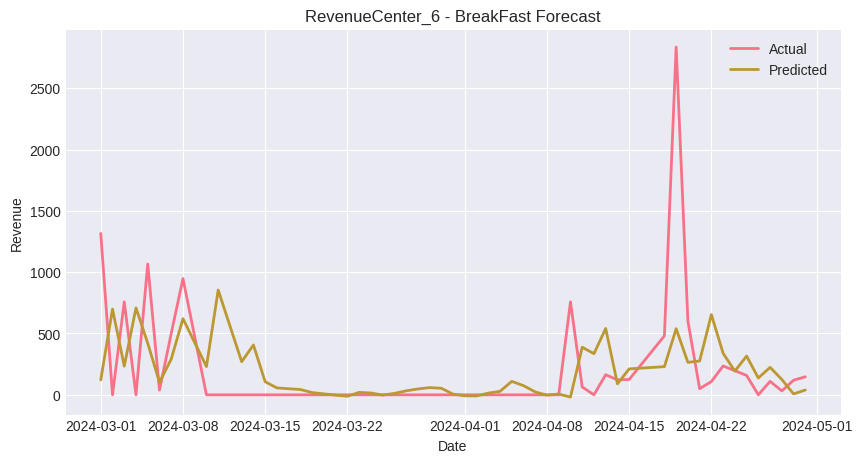

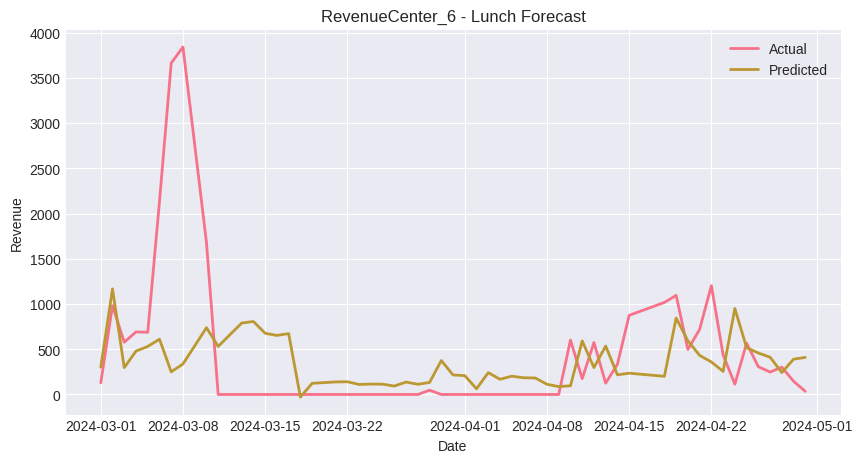

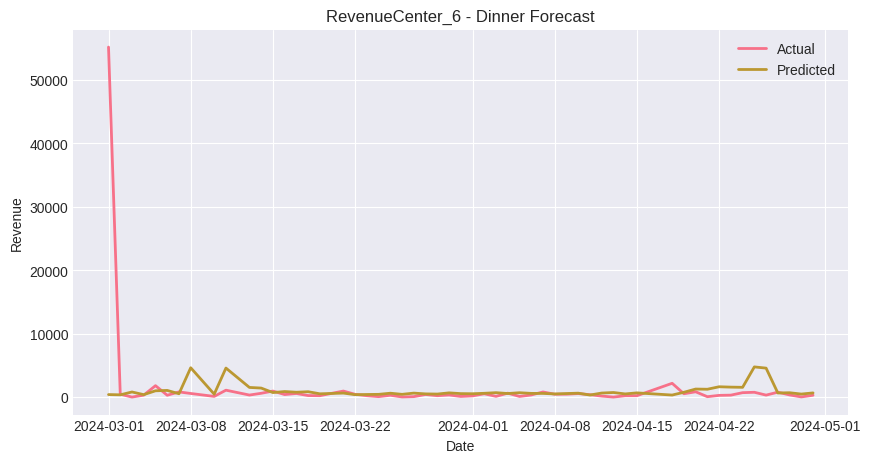

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_3

Training → BreakFast

BreakFast Validation
  MAE  : 381.81
  RMSE : 509.44
  R²   : -0.340
  MAPE : 127.43%

BreakFast Test
  MAE  : 314.25
  RMSE : 404.46
  R²   : -0.579
  MAPE : 122.64%

Training → Lunch

Lunch Validation
  MAE  : 1259.00
  RMSE : 1862.55
  R²   : -0.370
  MAPE : 40.42%

Lunch Test
  MAE  : 891.76
  RMSE : 1275.13
  R²   : 0.012
  MAPE : 51.20%

Training → Dinner

Dinner Validation
  MAE  : 7950.71
  RMSE : 9600.22
  R²   : -1.977
  MAPE : 33.70%

Dinner Test
  MAE  : 4913.24
  RMSE : 10163.67
  R²   : 0.139
  MAPE : 40.75%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch   Pred_Lunch  \
418 2024-03-01             154.0      325.657104        3426.0  1921.691772   
419 2024-03-02             324.0      801.718872        2176.0  1200.171875   
420 2024-03-03               0.0      729.427673        3688.0  1878.416016   
421 2024-03-04         

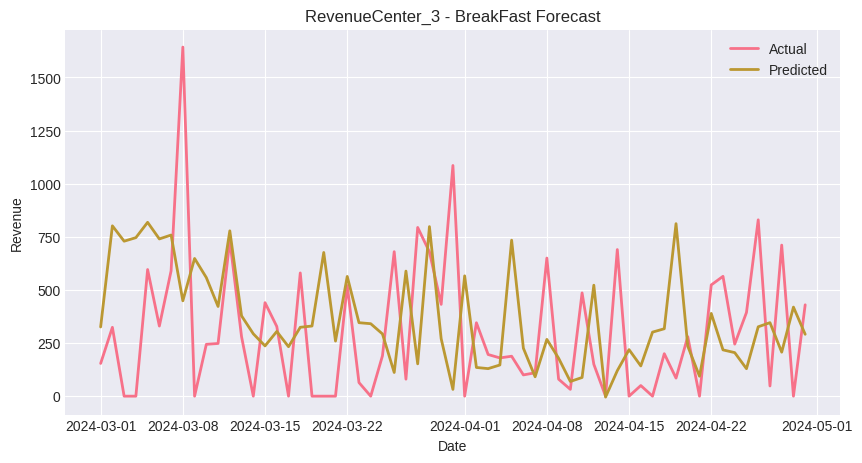

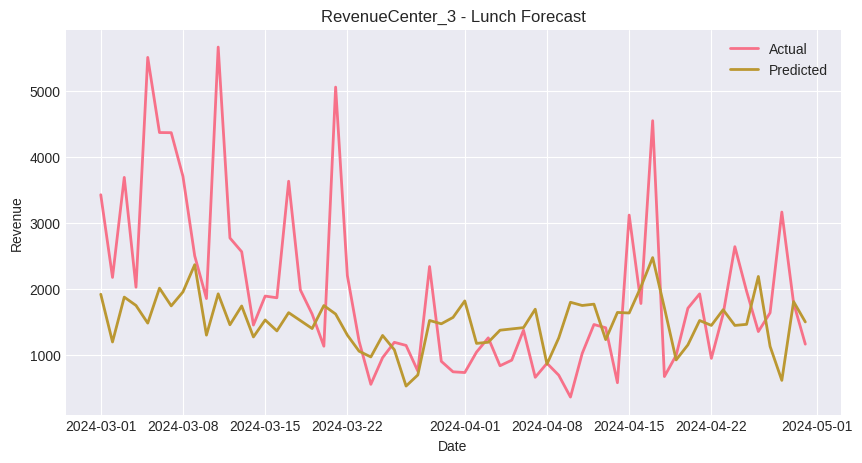

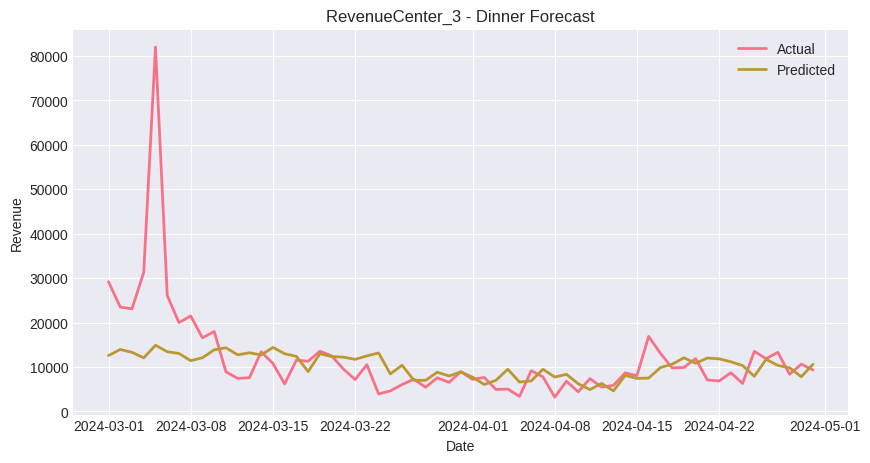

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_7

Training → BreakFast

BreakFast Validation
  MAE  : 70.86
  RMSE : 108.99
  R²   : -0.584
  MAPE : 191.56%

BreakFast Test
  MAE  : 42.83
  RMSE : 58.16
  R²   : -1.498
  MAPE : 166.95%

Training → Lunch

Lunch Validation
  MAE  : 65.41
  RMSE : 93.26
  R²   : -0.427
  MAPE : 77.30%

Lunch Test
  MAE  : 47.50
  RMSE : 76.83
  R²   : -0.153
  MAPE : 126.12%

Training → Dinner

Dinner Validation
  MAE  : 97.15
  RMSE : 131.37
  R²   : -0.557
  MAPE : 76.78%

Dinner Test
  MAE  : 82.29
  RMSE : 143.99
  R²   : -0.177
  MAPE : 86.23%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
392 2024-03-01               184       18.117819           206   42.804230   
393 2024-03-02                64      253.216263           254   65.199806   
394 2024-03-03                72      270.069458            50   24.343000   
395 2024-03-04                12       -8

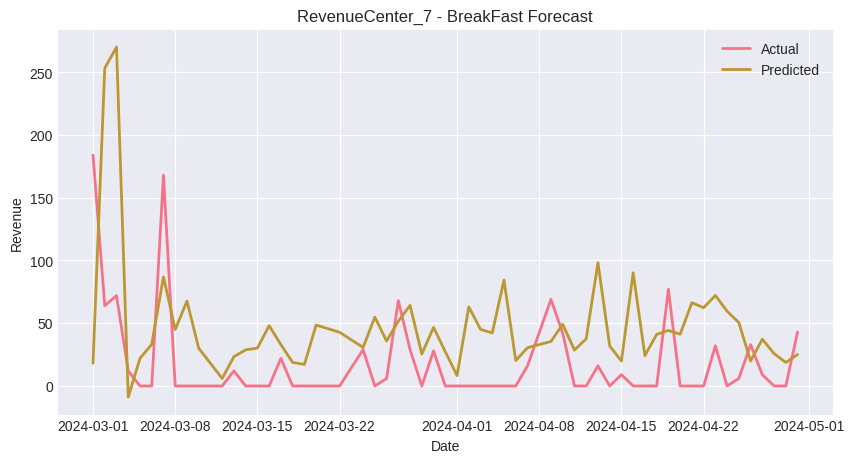

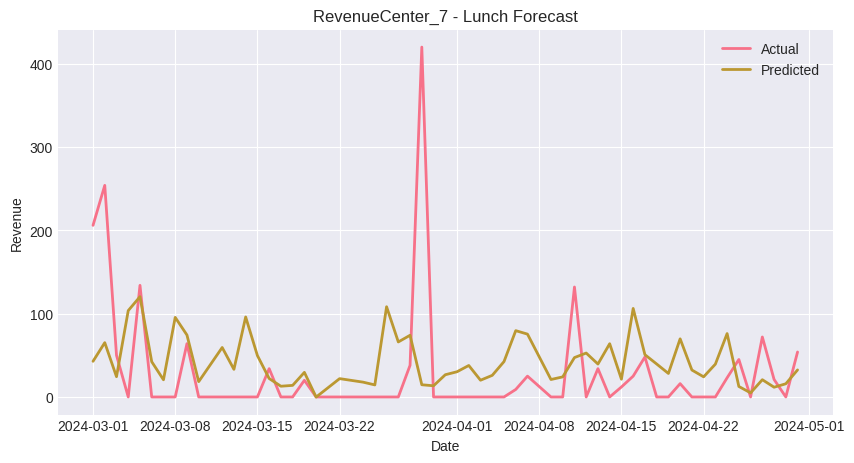

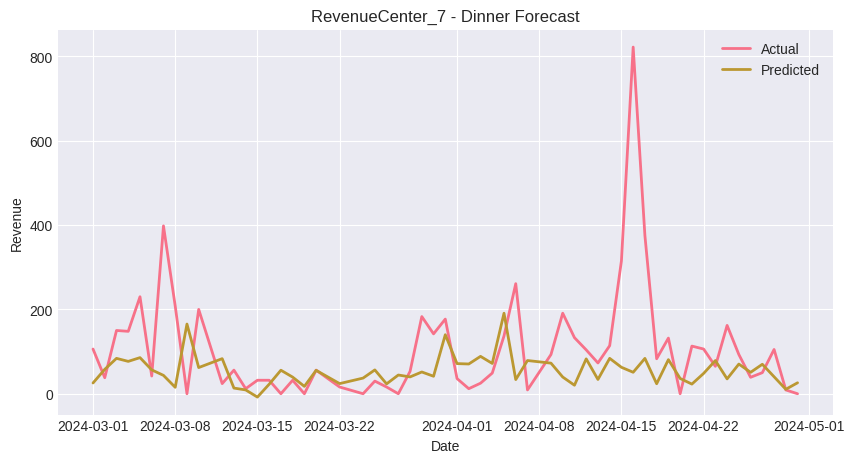

✓ Saved plots to: /content/prediction_results

Processing → RevenueCenter_4

Training → BreakFast

BreakFast Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

BreakFast Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Lunch

Lunch Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Lunch Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Dinner


/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mas


Dinner Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 0.000
  MAPE : nan%

Dinner Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 0.000
  MAPE : nan%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
410 2024-03-01                 0             0.0             0         0.0   
411 2024-03-02                 0             0.0             0         0.0   
412 2024-03-03                 0             0.0             0         0.0   
413 2024-03-04                 0             0.0             0         0.0   
414 2024-03-05                 0             0.0             0         0.0   

     Actual_Dinner  Pred_Dinner  
410            0.0     0.000016  
411            0.0     0.000016  
412            0.0     0.000016  
413            0.0     0.000016  
414            0.0     0.000016  


/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3558818339.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


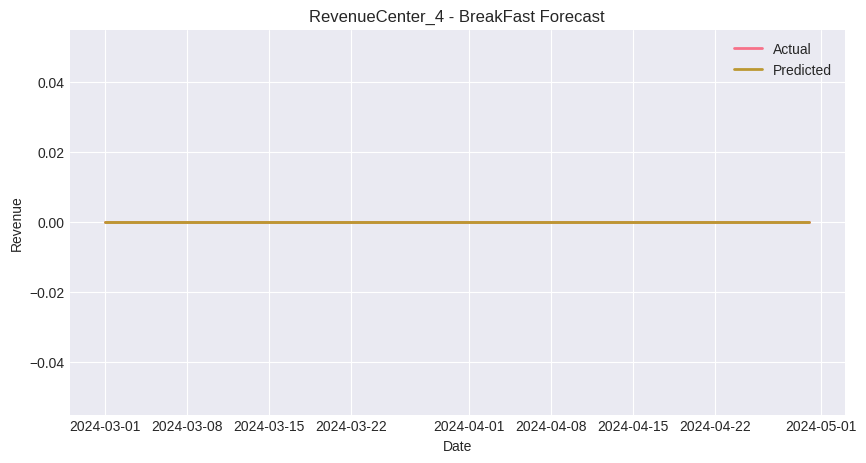

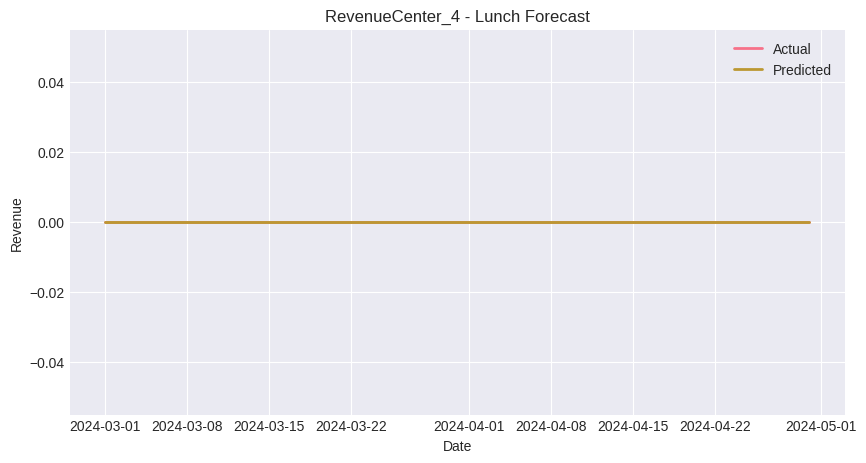

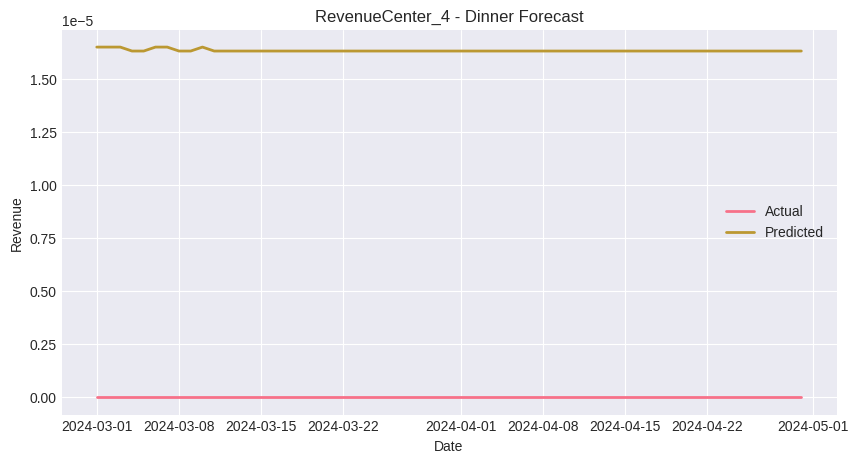

✓ Saved plots to: /content/prediction_results

All Revenue Centers Completed!


In [ ]:
# Train the model (Simplified version to match PC code)

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import glob, os
import matplotlib.pyplot as plt

# SETTINGS
input_folder = '/content/data_sets'
output_folder = '/content/prediction_results'
os.makedirs(output_folder, exist_ok=True)

file_pattern = "RevenueCenter_*"

LEARNING_RATE = 0.08
N_ESTIMATORS  = 900
MAX_DEPTH     = 5
RANDOM_STATE  = 42

# METRICS
def mape(y, p):
    y, p = np.array(y), np.array(p)
    mask = y != 0
    return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100

def evaluate(title, y, p):
    print(f"\n{title}")
    print(f"  MAE  : {mean_absolute_error(y, p):.2f}")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y, p)):.2f}")
    print(f"  R²   : {r2_score(y, p):.3f}")
    print(f"  MAPE : {mape(y, p):.2f}%")


# MAIN LOOP
files = glob.glob(os.path.join(input_folder, file_pattern + ".xlsx"))

print(f"Found {len(files)} files")

for file in files:
    center_name = os.path.basename(file).split(".xlsx")[0]
    print("\n" + "="*100)
    print(f"Processing → {center_name}")

    df = pd.read_excel(file)

    # Convert & Sort Date
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Add lag & rolling features
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:
        df[f"{meal}_lag_1"] = df[meal].shift(1)
        df[f"{meal}_lag_7"] = df[meal].shift(7)
        df[f"{meal}_roll_3"] = df[meal].shift(1).rolling(3).mean()
        df[f"{meal}_roll_7"] = df[meal].shift(1).rolling(7).mean()

    # Drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # Split data (fixed)
    train_df = df[df["Date"] < "2024-01-01"]
    val_df   = df[(df["Date"] >= "2024-01-01") & (df["Date"] <= "2024-02-29")]
    test_df  = df[(df["Date"] >= "2024-03-01") & (df["Date"] <= "2024-04-30")]

    if train_df.empty or val_df.empty or test_df.empty:
        print("Not enough data for training. Skipping this file.")
        continue

    # Fixed feature list (same as PC version)
    feature_cols = [
        "average_temperature", "weather_code",
        "Day_Monday","Day_Tuesday","Day_Wednesday","Day_Thursday",
        "Day_Friday","Day_Saturday","Day_Sunday",
        "IsWeekend", "IsHoliday",
        #"BreakFast_lag_1","BreakFast_lag_7","BreakFast_roll_3","BreakFast_roll_7",
        #"Lunch_lag_1","Lunch_lag_7","Lunch_roll_3","Lunch_roll_7",
        #"Dinner_lag_1","Dinner_lag_7","Dinner_roll_3","Dinner_roll_7"
    ]

    predictions = {}

    # Train one model per meal
    for meal in meals:
        print(f"\nTraining → {meal}")

        X_train = train_df[feature_cols]
        X_val   = val_df[feature_cols]
        X_test  = test_df[feature_cols]

        y_train = train_df[meal]
        y_val   = val_df[meal]
        y_test  = test_df[meal]

        model = XGBRegressor(
            n_estimators=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            max_depth=MAX_DEPTH,
            random_state=RANDOM_STATE,
            eval_metric="rmse"
        )

        model.fit(X_train, y_train)

        val_pred  = model.predict(X_val)
        test_pred = model.predict(X_test)

        evaluate(f"{meal} Validation", y_val, val_pred)
        evaluate(f"{meal} Test", y_test, test_pred)

        predictions[meal] = test_pred

    # Make result table
    result = pd.DataFrame({
        "Date": test_df["Date"],
        "Actual_BreakFast": test_df["BreakFast"],
        "Pred_BreakFast": predictions["BreakFast"],
        "Actual_Lunch": test_df["Lunch"],
        "Pred_Lunch": predictions["Lunch"],
        "Actual_Dinner": test_df["Dinner"],
        "Pred_Dinner": predictions["Dinner"]
    })

    print("\n🔍 Preview of Prediction Results:")
    print(result.head())

    # Save CSV
    save_path = os.path.join(output_folder, f"{center_name}_predictions.csv")
    result.to_csv(save_path, index=False)

    # Save plots
    for meal in meals:
        y_test = test_df[meal]
        test_pred = predictions[meal]

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test, label="Actual", linewidth=2)
        plt.plot(test_df["Date"], test_pred, label="Predicted", linewidth=2)
        plt.title(f"{center_name} - {meal} Forecast")
        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(True)

        plot_path = os.path.join(output_folder, f"{center_name}_{meal}_plot.png")
        plt.savefig(plot_path, dpi=300)
        plt.show()
        plt.close()

    print(f"✓ Saved plots to: {output_folder}")

print("\nAll Revenue Centers Completed!")


In [ ]:
import pandas as pd
import numpy as np
import os

# Create a folder in Colab
folder_path = '/content/data_sets'
output_folder = '/content/data_set_spikes'
os.makedirs(output_folder, exist_ok=True)

# Get all Excel files
import glob
files = glob.glob(os.path.join(folder_path, "*.xlsx"))

# If no files found, upload them
if not files:
    print("No files found. Please upload Excel files:")
    from google.colab import files
    uploaded = files.upload()

    # Move uploaded files to folder
    os.makedirs(folder_path, exist_ok=True)
    for filename in uploaded.keys():
        os.rename(filename, os.path.join(folder_path, filename))

    # Get file list again
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))

# Process each file
for file in files:
    filename = os.path.basename(file)
    print(f"Processing: {filename}")

    # Read file
    df = pd.read_excel(file)

    # Process meal columns
    for meal in ["BreakFast", "Lunch", "Dinner"]:
        if meal in df.columns:
            mean_val = df[meal].mean()

            # Set threshold
            if mean_val > 1000:
                threshold = 4 * mean_val
            else:
                threshold = 1.5 * mean_val

            # Keep only spikes
            df[meal] = np.where(df[meal] > threshold, df[meal], 0)

    # Save result
    save_path = os.path.join(output_folder, filename)
    df.to_excel(save_path, index=False)
    print(f"Saved: {save_path}\n")

print("Done! All files processed.")

Processing: RevenueCenter_9.xlsx
Saved: /content/data_set_spikes/RevenueCenter_9.xlsx

Processing: RevenueCenter_1.xlsx
Saved: /content/data_set_spikes/RevenueCenter_1.xlsx

Processing: RevenueCenter_5.xlsx
Saved: /content/data_set_spikes/RevenueCenter_5.xlsx

Processing: RevenueCenter_2.xlsx
Saved: /content/data_set_spikes/RevenueCenter_2.xlsx

Processing: RevenueCenter_8.xlsx
Saved: /content/data_set_spikes/RevenueCenter_8.xlsx

Processing: RevenueCenter_6.xlsx
Saved: /content/data_set_spikes/RevenueCenter_6.xlsx

Processing: RevenueCenter_3.xlsx
Saved: /content/data_set_spikes/RevenueCenter_3.xlsx

Processing: RevenueCenter_7.xlsx
Saved: /content/data_set_spikes/RevenueCenter_7.xlsx

Processing: RevenueCenter_4.xlsx
Saved: /content/data_set_spikes/RevenueCenter_4.xlsx

Done! All files processed.


Found 9 spike-cleaned files

Processing → RevenueCenter_9

Training → BreakFast

BreakFast Validation
  MAE  : 441.11
  RMSE : 574.21
  R²   : -0.798
  MAPE : 88.40%

BreakFast Test
  MAE  : 250.00
  RMSE : 408.77
  R²   : -0.414
  MAPE : 90.49%

Training → Lunch

Lunch Validation
  MAE  : 247.76
  RMSE : 349.21
  R²   : -0.534
  MAPE : 88.09%

Lunch Test
  MAE  : 159.21
  RMSE : 269.14
  R²   : -0.307
  MAPE : 82.21%

Training → Dinner

Dinner Validation
  MAE  : 90.52
  RMSE : 161.09
  R²   : -3.903
  MAPE : 91.99%

Dinner Test
  MAE  : 92.96
  RMSE : 181.62
  R²   : -0.031
  MAPE : 90.01%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
363 2024-03-01               0.0        1.895213             0  -36.586590   
364 2024-03-02             370.0      351.738129             0  -65.907372   
365 2024-03-03             800.0      323.130371           650 -107.855354   
366 2024-03-04             540.0       31.895992       

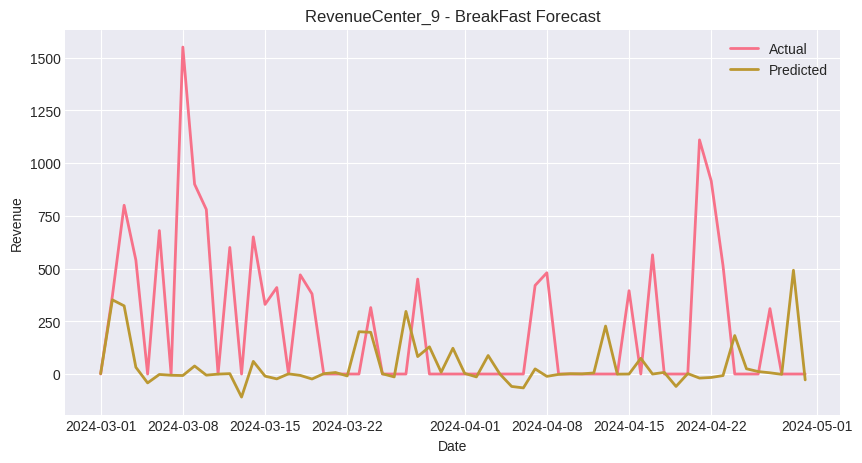

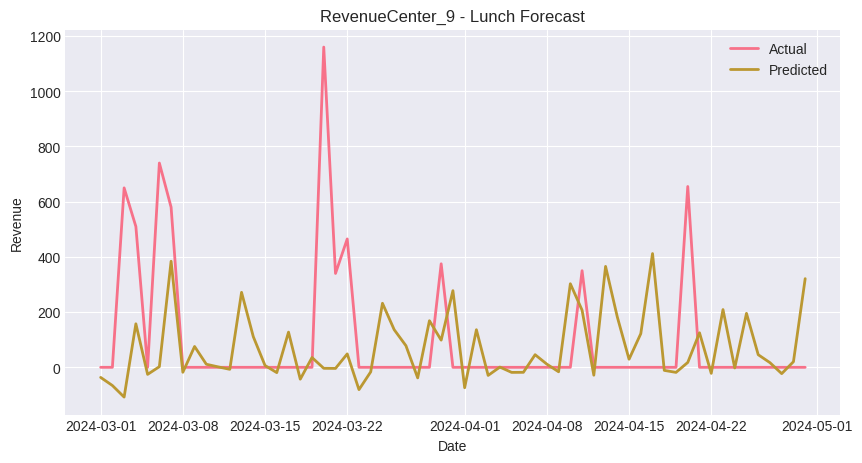

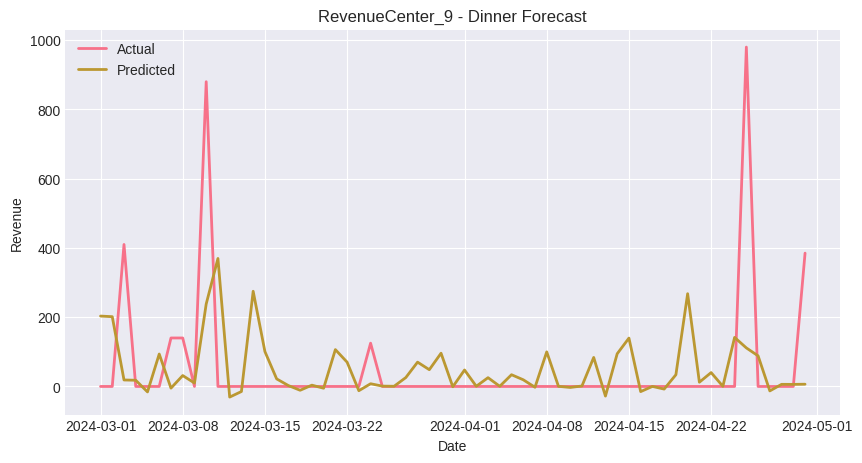

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_1

Training → BreakFast

BreakFast Validation
  MAE  : 1839.31
  RMSE : 2309.72
  R²   : -0.979
  MAPE : 90.56%

BreakFast Test
  MAE  : 746.18
  RMSE : 1588.92
  R²   : -0.270
  MAPE : 99.08%

Training → Lunch

Lunch Validation
  MAE  : 1367.35
  RMSE : 1783.24
  R²   : -1.053
  MAPE : 93.27%

Lunch Test
  MAE  : 547.52
  RMSE : 980.35
  R²   : -0.492
  MAPE : 87.29%

Training → Dinner

Dinner Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Dinner Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch   Pred_Lunch  \
418 2024-03-01            2372.0       82.404289        1767.0    -6.507008   
419 2024-03-02            1944.0       -6.164455        3482.0    -0.075762   
420 2024-03-03            7984.0      -65.735886        3586.0     6.809258   
421 2024-03-04               0.0  

/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


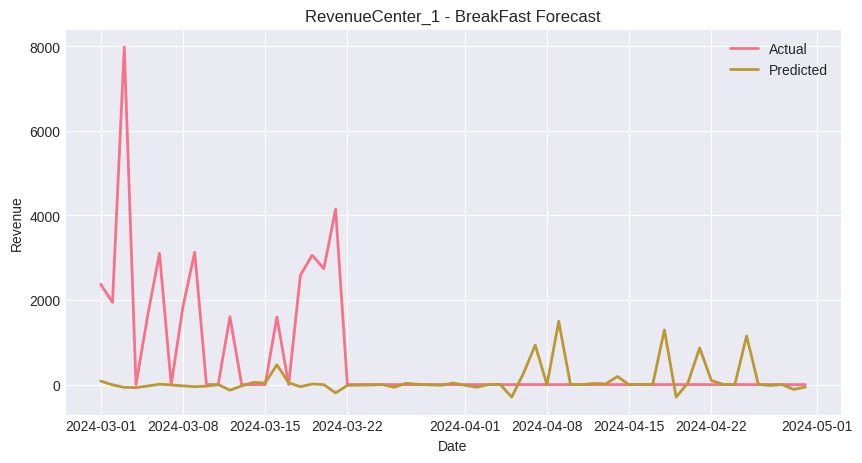

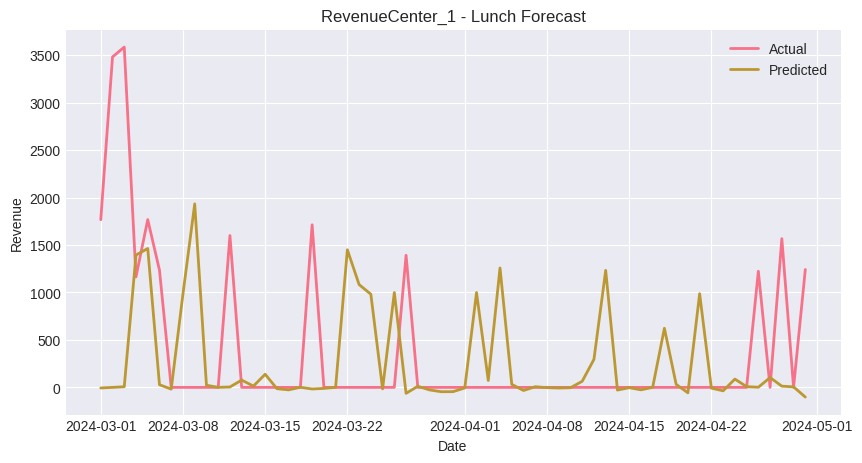

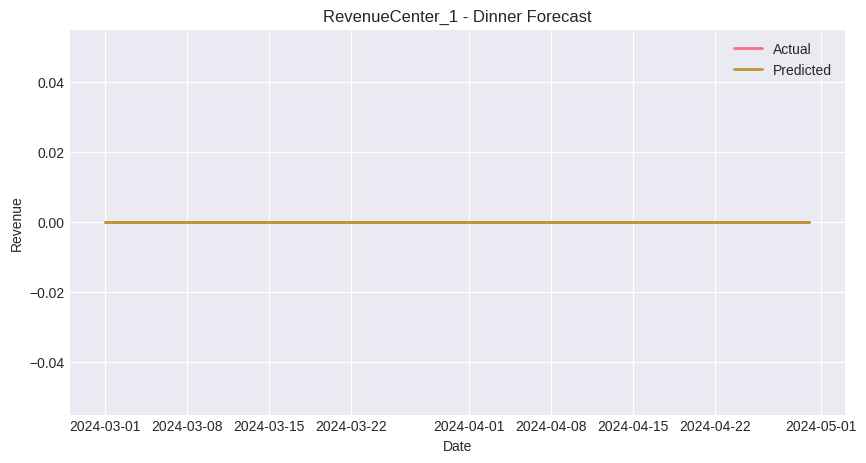

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_5

Training → BreakFast

BreakFast Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

BreakFast Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Lunch


/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Lunch Validation
  MAE  : 944.45
  RMSE : 3386.98
  R²   : -0.506
  MAPE : 99.95%

Lunch Test
  MAE  : 1175.22
  RMSE : 4127.15
  R²   : -0.326
  MAPE : 100.00%

Training → Dinner

Dinner Validation
  MAE  : 4630.16
  RMSE : 10786.64
  R²   : -0.378
  MAPE : 101.30%

Dinner Test
  MAE  : 4201.00
  RMSE : 12579.98
  R²   : -0.309
  MAPE : 100.98%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
418 2024-03-01                 0             0.0           0.0    0.053016   
419 2024-03-02                 0             0.0       14564.0    0.122236   
420 2024-03-03                 0             0.0           0.0   -0.044717   
421 2024-03-04                 0             0.0           0.0   34.116615   
422 2024-03-05                 0             0.0           0.0    0.174330   

     Actual_Dinner  Pred_Dinner  
418            0.0    -0.508644  
419            0.0     3.094639  
420            0.0    59.209118  
421         

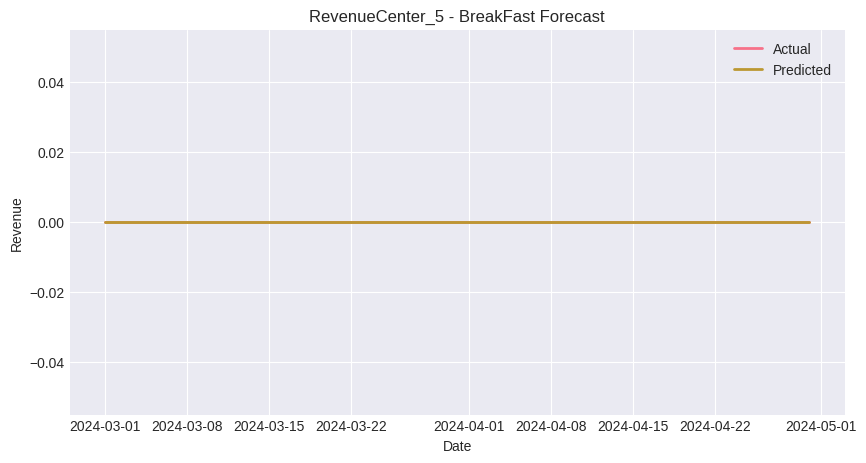

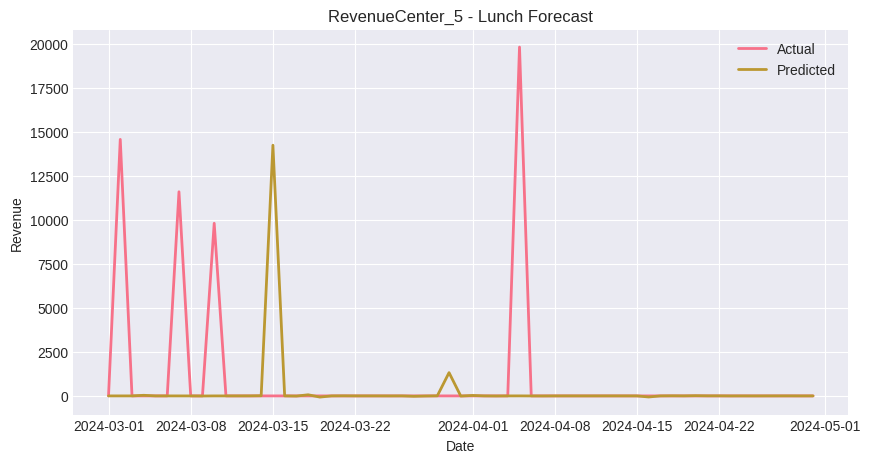

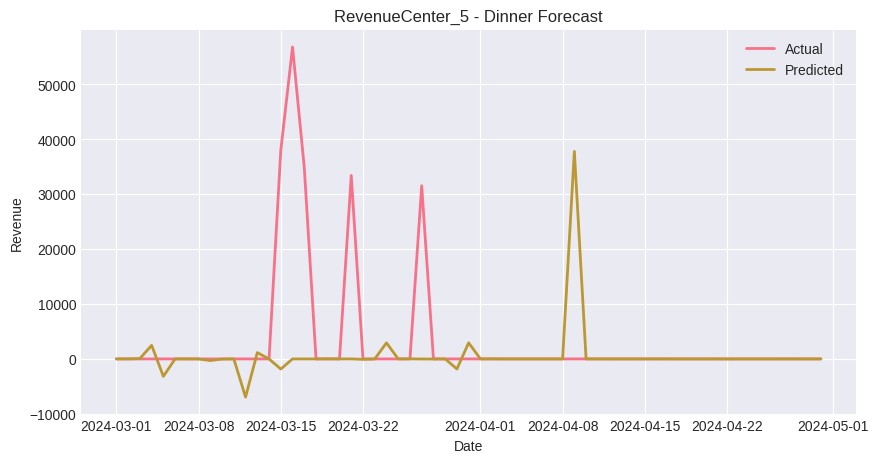

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_2

Training → BreakFast

BreakFast Validation
  MAE  : 517.90
  RMSE : 691.88
  R²   : -0.592
  MAPE : 74.91%

BreakFast Test
  MAE  : 406.42
  RMSE : 635.94
  R²   : -0.463
  MAPE : 79.89%

Training → Lunch

Lunch Validation
  MAE  : 532.43
  RMSE : 763.96
  R²   : -0.225
  MAPE : 80.68%

Lunch Test
  MAE  : 424.27
  RMSE : 1051.39
  R²   : -0.099
  MAPE : 83.27%

Training → Dinner

Dinner Validation
  MAE  : 880.13
  RMSE : 1666.02
  R²   : -0.308
  MAPE : 75.20%

Dinner Test
  MAE  : 369.85
  RMSE : 749.55
  R²   : -0.268
  MAPE : 83.01%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
416 2024-03-01               0.0      582.908081           0.0  -37.466118   
417 2024-03-02            1129.0       66.152321        1274.0    6.252632   
418 2024-03-03             709.0      327.498810           0.0  -26.971043   
419 2024-03-04            1

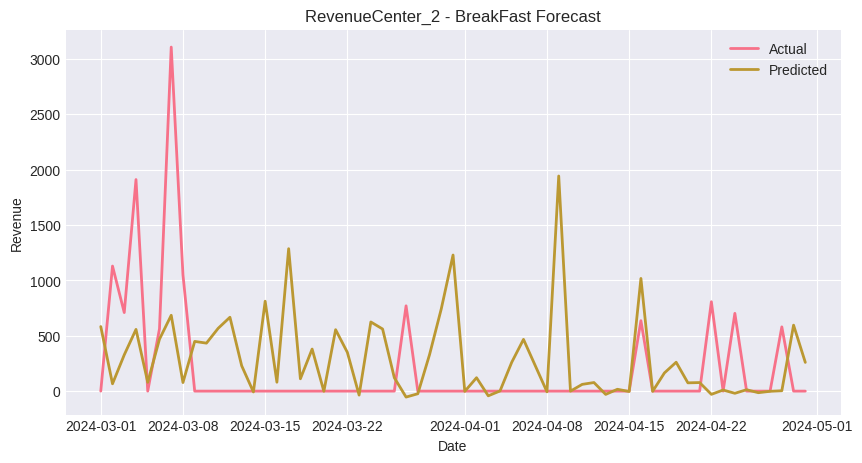

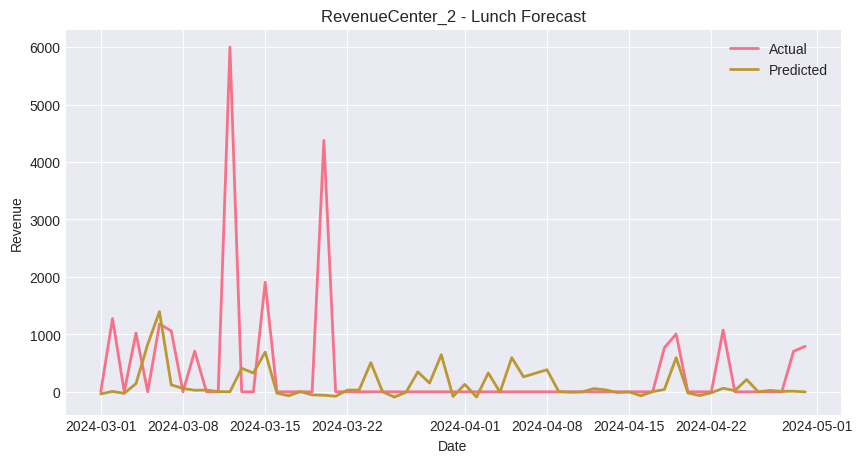

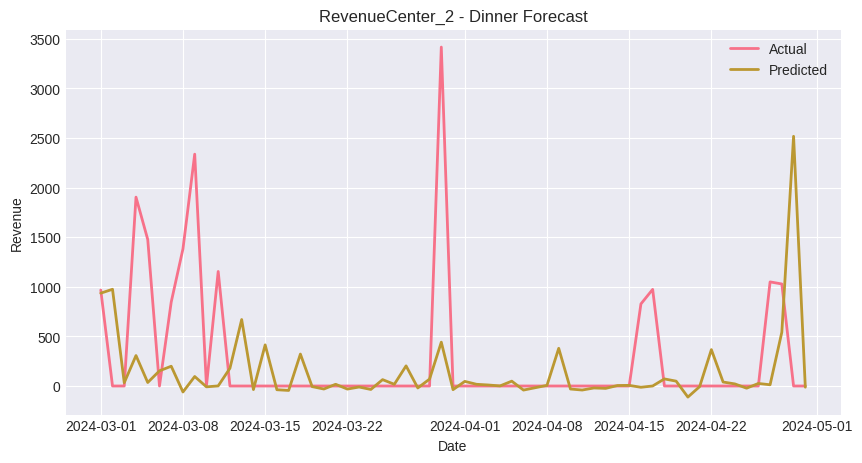

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_8

Training → BreakFast

BreakFast Validation
  MAE  : 1928.08
  RMSE : 3312.87
  R²   : -6.892
  MAPE : 99.76%

BreakFast Test
  MAE  : 2200.62
  RMSE : 4782.41
  R²   : -0.524
  MAPE : 99.35%

Training → Lunch

Lunch Validation
  MAE  : 14610.77
  RMSE : 26533.96
  R²   : -0.295
  MAPE : 95.18%

Lunch Test
  MAE  : 5847.96
  RMSE : 17457.02
  R²   : 0.037
  MAPE : 85.28%

Training → Dinner

Dinner Validation
  MAE  : 9126.67
  RMSE : 28095.91
  R²   : -0.127
  MAPE : 99.89%

Dinner Test
  MAE  : 8465.01
  RMSE : 26929.28
  R²   : -0.444
  MAPE : 99.98%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch    Pred_Lunch  \
348 2024-03-01                 0      -25.311972             0    -65.886742   
349 2024-03-02                 0     -245.657379             0    -88.858200   
350 2024-03-03                 0     -128.907547             0   -286.065186   
351 2

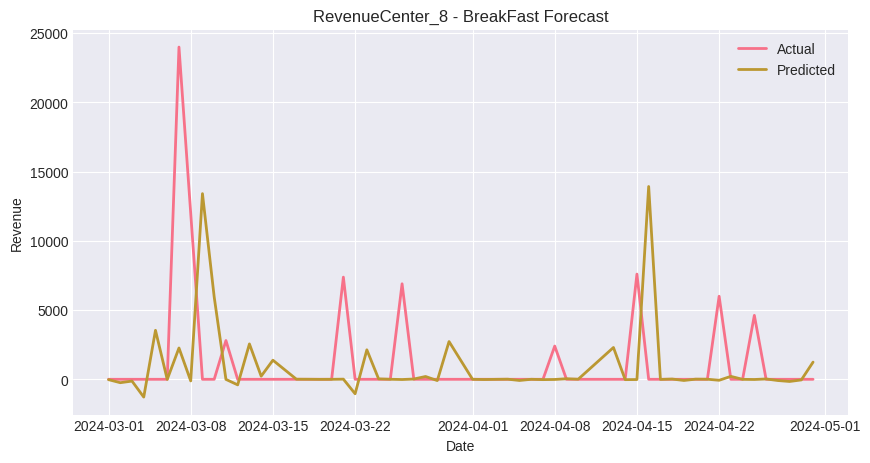

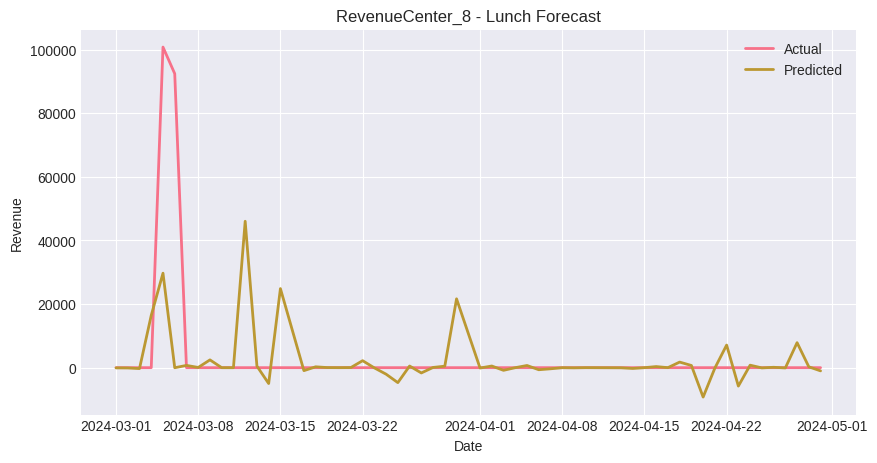

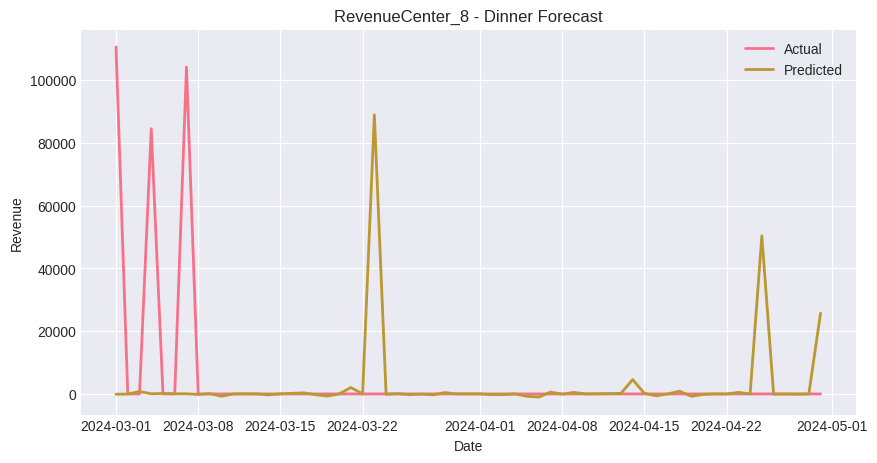

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_6

Training → BreakFast

BreakFast Validation
  MAE  : 234.70
  RMSE : 345.71
  R²   : -0.055
  MAPE : 78.34%

BreakFast Test
  MAE  : 264.16
  RMSE : 519.38
  R²   : -0.234
  MAPE : 80.69%

Training → Lunch

Lunch Validation
  MAE  : 658.55
  RMSE : 939.12
  R²   : -0.522
  MAPE : 74.86%

Lunch Test
  MAE  : 443.53
  RMSE : 842.53
  R²   : -0.095
  MAPE : 79.40%

Training → Dinner

Dinner Validation
  MAE  : 1982.80
  RMSE : 6050.22
  R²   : -0.527
  MAPE : 113.17%

Dinner Test
  MAE  : 1238.03
  RMSE : 7395.97
  R²   : -0.024
  MAPE : 89.50%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
413 2024-03-01            1316.0       86.498047           0.0   62.597149   
414 2024-03-02               0.0      141.638428         982.0  383.743713   
415 2024-03-03             758.0      204.089539           0.0  637.029358   
416 2024-03-04          

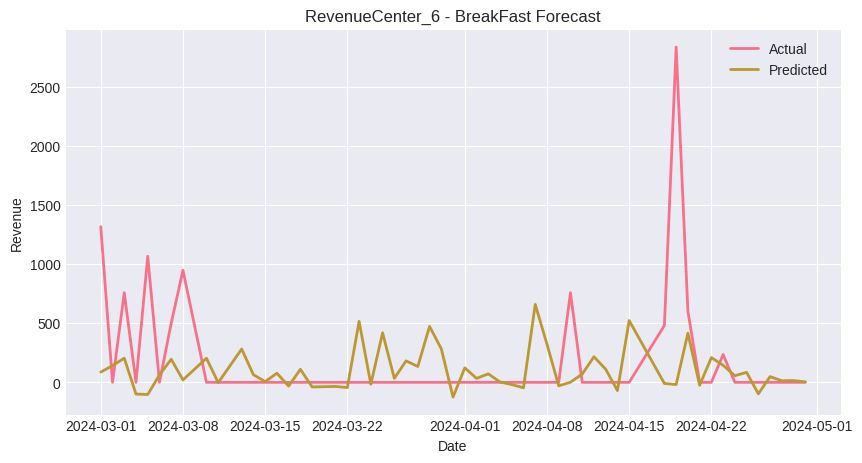

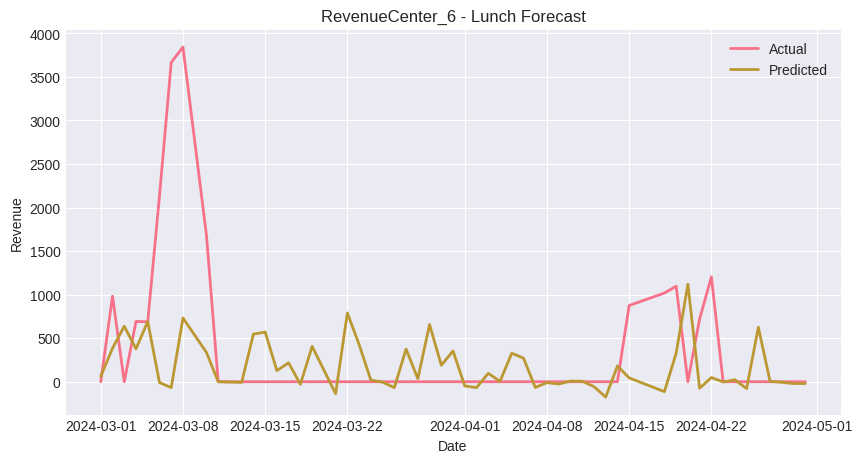

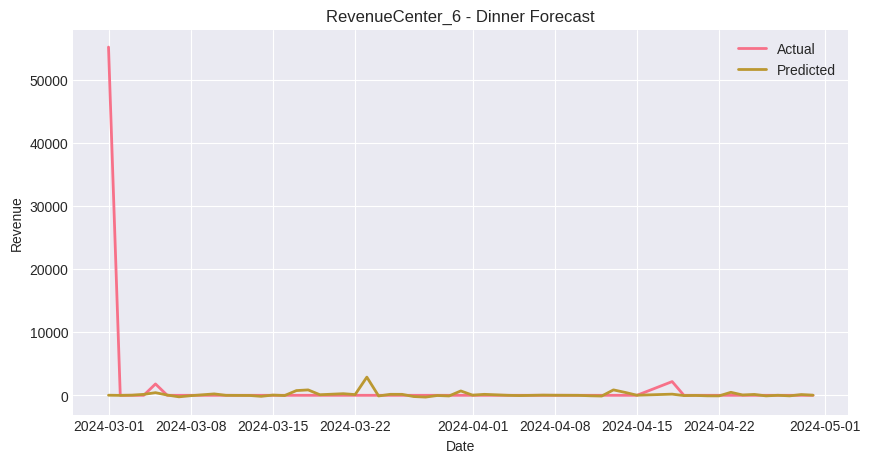

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_3

Training → BreakFast

BreakFast Validation
  MAE  : 405.78
  RMSE : 616.32
  R²   : -0.476
  MAPE : 88.17%

BreakFast Test
  MAE  : 311.96
  RMSE : 463.46
  R²   : -0.711
  MAPE : 88.31%

Training → Lunch

Lunch Validation
  MAE  : 150.72
  RMSE : 1167.51
  R²   : -0.017
  MAPE : 100.00%

Lunch Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Dinner


/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Dinner Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Dinner Test
  MAE  : 1344.15
  RMSE : 10498.13
  R²   : -0.017
  MAPE : 100.00%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
418 2024-03-01               0.0     1079.142944           0.0         0.0   
419 2024-03-02               0.0       21.158220           0.0         0.0   
420 2024-03-03               0.0        7.385538           0.0         0.0   
421 2024-03-04               0.0      451.758331           0.0         0.0   
422 2024-03-05             596.0      402.271057           0.0         0.0   

     Actual_Dinner  Pred_Dinner  
418              0          0.0  
419              0          0.0  
420              0          0.0  
421              0          0.0  
422          81993          0.0  


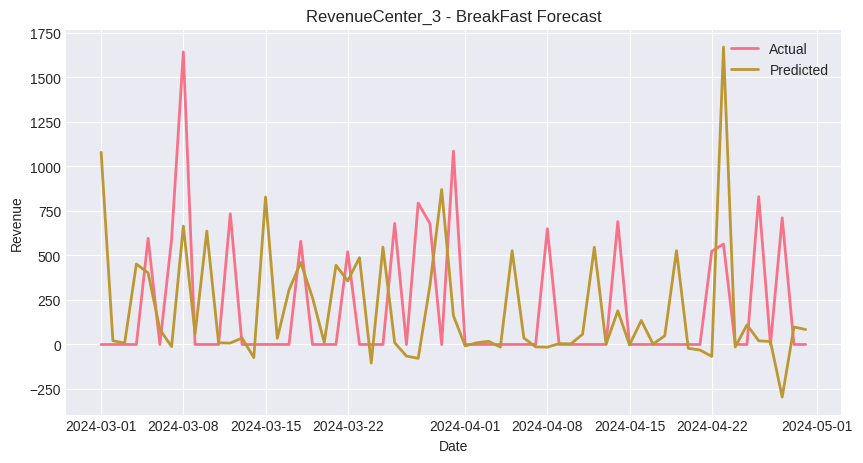

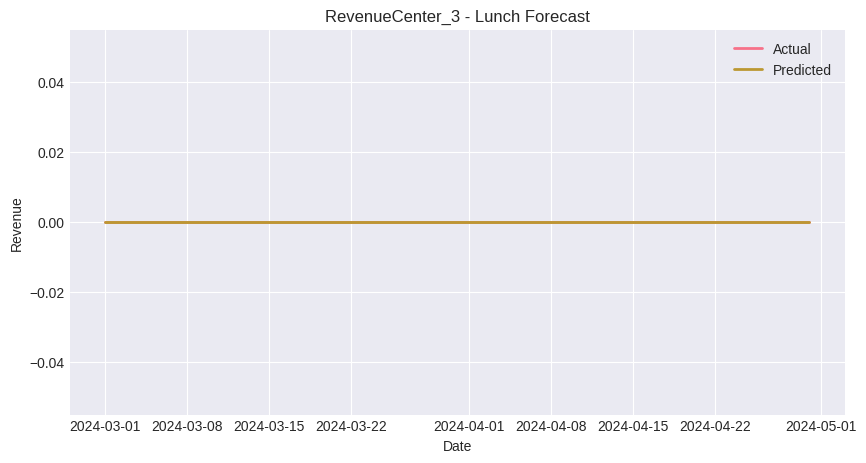

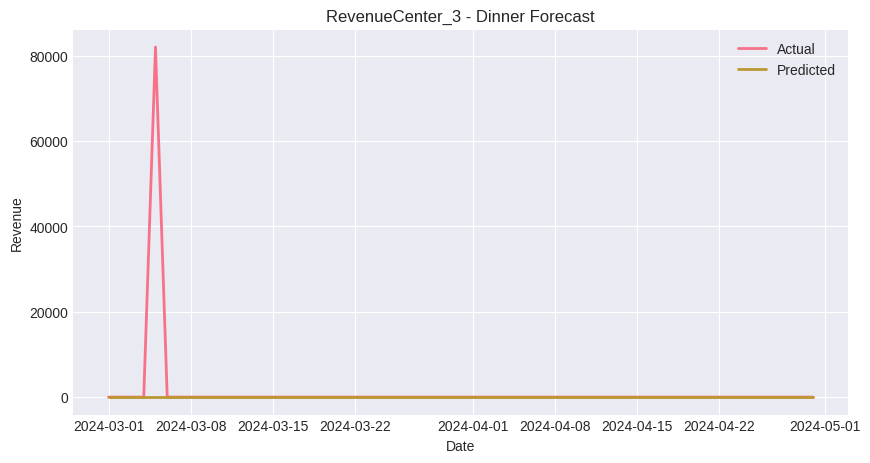

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_7

Training → BreakFast

BreakFast Validation
  MAE  : 80.39
  RMSE : 143.71
  R²   : -1.553
  MAPE : 84.74%

BreakFast Test
  MAE  : 33.60
  RMSE : 51.04
  R²   : -0.903
  MAPE : 70.78%

Training → Lunch

Lunch Validation
  MAE  : 56.31
  RMSE : 89.84
  R²   : -0.242
  MAPE : 79.77%

Lunch Test
  MAE  : 35.90
  RMSE : 77.70
  R²   : -0.148
  MAPE : 96.96%

Training → Dinner

Dinner Validation
  MAE  : 101.78
  RMSE : 144.22
  R²   : -0.436
  MAPE : 74.16%

Dinner Test
  MAE  : 90.06
  RMSE : 158.00
  R²   : -0.206
  MAPE : 78.30%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
392 2024-03-01               184        8.091892           206   -1.996590   
393 2024-03-02                64        5.488959           254    2.224802   
394 2024-03-03                72       -1.711266            50    5.397530   
395 2024-03-04                 0     

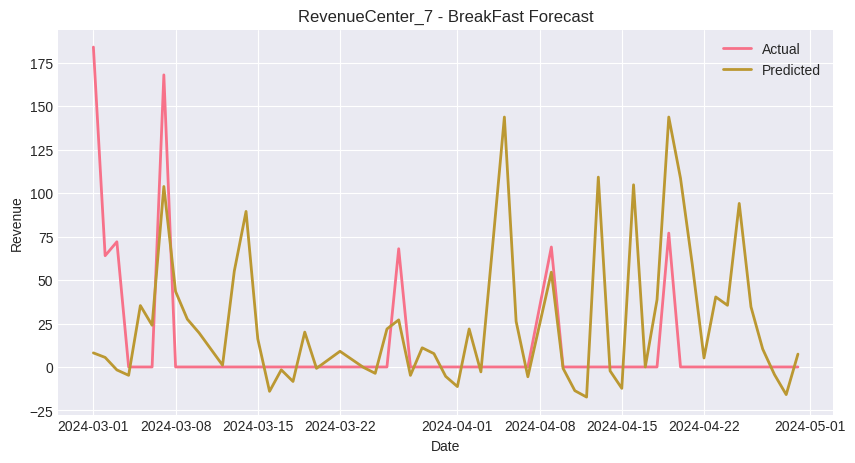

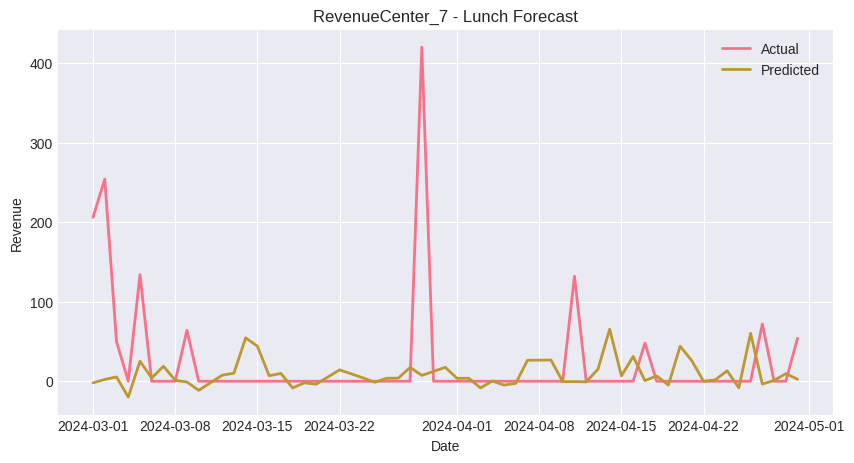

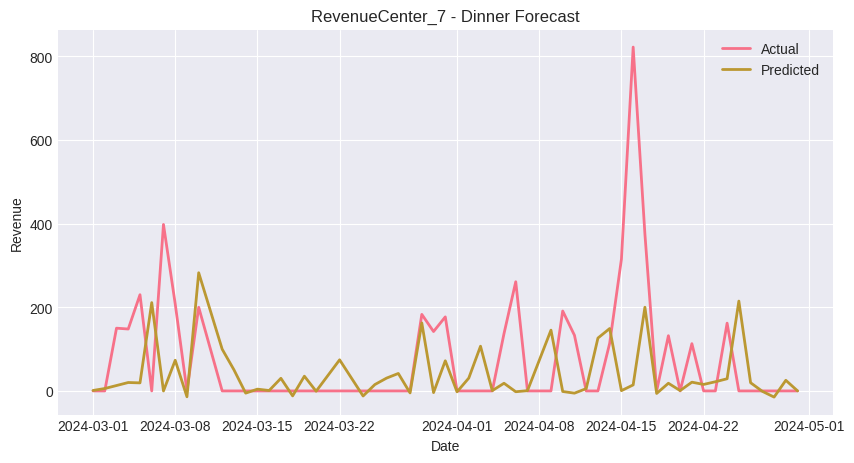

✓ Saved plots to: /content/prediction_results_spike

Processing → RevenueCenter_4

Training → BreakFast

BreakFast Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

BreakFast Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Lunch


/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] -


Lunch Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Lunch Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 1.000
  MAPE : nan%

Training → Dinner

Dinner Validation
  MAE  : 0.00
  RMSE : 0.00
  R²   : 0.000
  MAPE : nan%

Dinner Test
  MAE  : 0.00
  RMSE : 0.00
  R²   : 0.000
  MAPE : nan%

🔍 Preview of Prediction Results:
          Date  Actual_BreakFast  Pred_BreakFast  Actual_Lunch  Pred_Lunch  \
410 2024-03-01                 0             0.0             0         0.0   
411 2024-03-02                 0             0.0             0         0.0   
412 2024-03-03                 0             0.0             0         0.0   
413 2024-03-04                 0             0.0             0         0.0   
414 2024-03-05                 0             0.0             0         0.0   

     Actual_Dinner  Pred_Dinner  
410            0.0     0.000016  
411            0.0     0.000016  
412            0.0     0.000016  
413            0.0     0.000016  
414            0.0

/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-591741973.py:26: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


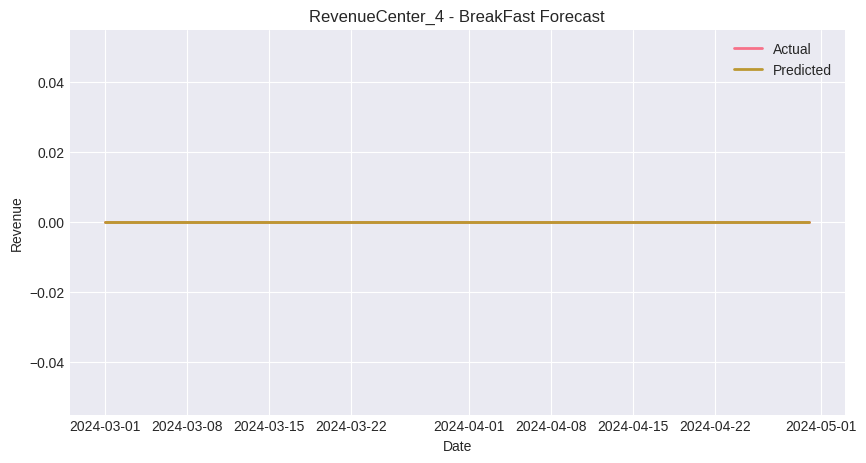

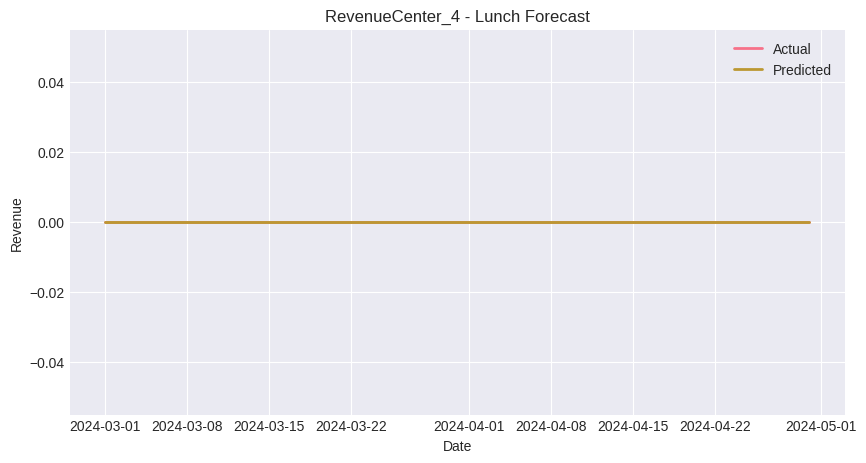

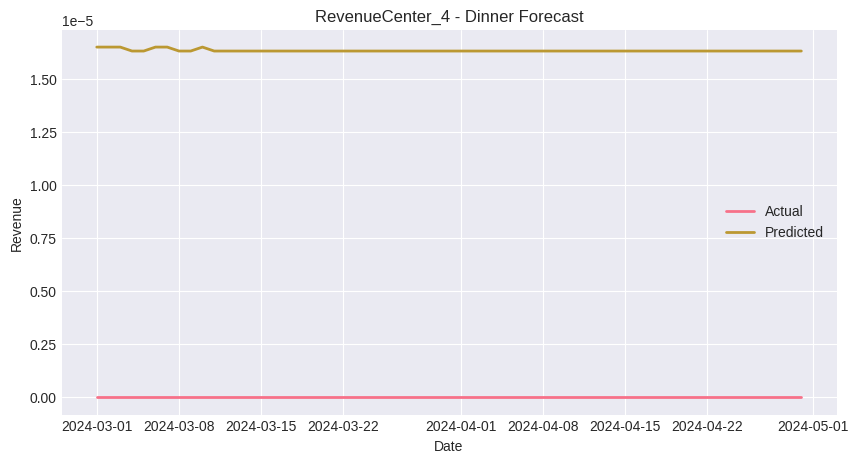

✓ Saved plots to: /content/prediction_results_spike

All Spike-Processed Revenue Centers Completed!


In [ ]:
# Train the model (Simplified version to match the normal script)

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import glob, os
import matplotlib.pyplot as plt

# SETTINGS (Spike version)
input_folder = '/content/data_set_spikes'
output_folder = '/content/prediction_results_spike'
os.makedirs(output_folder, exist_ok=True)

file_pattern = "RevenueCenter_*"

LEARNING_RATE = 0.08
N_ESTIMATORS  = 900
MAX_DEPTH     = 5
RANDOM_STATE  = 42

# METRICS
def mape(y, p):
    y, p = np.array(y), np.array(p)
    mask = y != 0
    return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100

def evaluate(title, y, p):
    print(f"\n{title}")
    print(f"  MAE  : {mean_absolute_error(y, p):.2f}")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y, p)):.2f}")
    print(f"  R²   : {r2_score(y, p):.3f}")
    print(f"  MAPE : {mape(y, p):.2f}%")


# MAIN LOOP
files = glob.glob(os.path.join(input_folder, file_pattern + ".xlsx"))

print(f"Found {len(files)} spike-cleaned files")

for file in files:
    center_name = os.path.basename(file).split(".xlsx")[0]
    print("\n" + "="*100)
    print(f"Processing → {center_name}")

    df = pd.read_excel(file)

    # Convert & Sort Date
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Add lag & rolling features
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:
        df[f"{meal}_lag_1"] = df[meal].shift(1)
        df[f"{meal}_lag_7"] = df[meal].shift(7)
        df[f"{meal}_roll_3"] = df[meal].shift(1).rolling(3).mean()
        df[f"{meal}_roll_7"] = df[meal].shift(1).rolling(7).mean()

    # Drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # Split data (fixed)
    train_df = df[df["Date"] < "2024-01-01"]
    val_df   = df[(df["Date"] >= "2024-01-01") & (df["Date"] <= "2024-02-29")]
    test_df  = df[(df["Date"] >= "2024-03-01") & (df["Date"] <= "2024-04-30")]

    if train_df.empty or val_df.empty or test_df.empty:
        print("Not enough data for training. Skipping this file.")
        continue

    # Fixed feature list (same as normal script)
    feature_cols = [
        "average_temperature", "weather_code",
        "Day_Monday","Day_Tuesday","Day_Wednesday","Day_Thursday",
        "Day_Friday","Day_Saturday","Day_Sunday",
        "IsWeekend", "IsHoliday",


        #"BreakFast_lag_1","BreakFast_lag_7","BreakFast_roll_3","BreakFast_roll_7",
        #"Lunch_lag_1","Lunch_lag_7","Lunch_roll_3","Lunch_roll_7",
        #"Dinner_lag_1","Dinner_lag_7","Dinner_roll_3","Dinner_roll_7"


    ]

    predictions = {}

    # Train one model per meal
    for meal in meals:
        print(f"\nTraining → {meal}")

        X_train = train_df[feature_cols]
        X_val   = val_df[feature_cols]
        X_test  = test_df[feature_cols]

        y_train = train_df[meal]
        y_val   = val_df[meal]
        y_test  = test_df[meal]

        model = XGBRegressor(
            n_estimators=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            max_depth=MAX_DEPTH,
            random_state=RANDOM_STATE,
            eval_metric="rmse"
        )

        model.fit(X_train, y_train)

        val_pred  = model.predict(X_val)
        test_pred = model.predict(X_test)

        evaluate(f"{meal} Validation", y_val, val_pred)
        evaluate(f"{meal} Test", y_test, test_pred)

        predictions[meal] = test_pred

    # Make result table
    result = pd.DataFrame({
        "Date": test_df["Date"],
        "Actual_BreakFast": test_df["BreakFast"],
        "Pred_BreakFast": predictions["BreakFast"],
        "Actual_Lunch": test_df["Lunch"],
        "Pred_Lunch": predictions["Lunch"],
        "Actual_Dinner": test_df["Dinner"],
        "Pred_Dinner": predictions["Dinner"]
    })

    print("\n🔍 Preview of Prediction Results:")
    print(result.head())

    # Save CSV
    save_path = os.path.join(output_folder, f"{center_name}_predictions.csv")
    result.to_csv(save_path, index=False)

    # Save plots
    for meal in meals:
        y_test = test_df[meal]
        test_pred = predictions[meal]

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test, label="Actual", linewidth=2)
        plt.plot(test_df["Date"], test_pred, label="Predicted", linewidth=2)
        plt.title(f"{center_name} - {meal} Forecast")
        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(True)

        plot_path = os.path.join(output_folder, f"{center_name}_{meal}_plot.png")
        plt.savefig(plot_path, dpi=300)
        plt.show()
        plt.close()

    print(f"✓ Saved plots to: {output_folder}")

print("\nAll Spike-Processed Revenue Centers Completed!")



Processing normal dataset...

Processing: RevenueCenter_9

BreakFast Validation:
MAE: 416.82, RMSE: 545.10, R2: -1.001, MAPE: 83.67%
BreakFast Test:
MAE: 228.59, RMSE: 342.29, R2: -0.256, MAPE: 80.26%

Lunch Validation:
MAE: 207.09, RMSE: 265.15, R2: -0.101, MAPE: 83.67%
Lunch Test:
MAE: 174.74, RMSE: 251.87, R2: -0.338, MAPE: 130.65%

Dinner Validation:
MAE: 202.79, RMSE: 261.81, R2: -11.951, MAPE: 159.11%
Dinner Test:
MAE: 118.20, RMSE: 204.77, R2: -0.334, MAPE: 176.83%


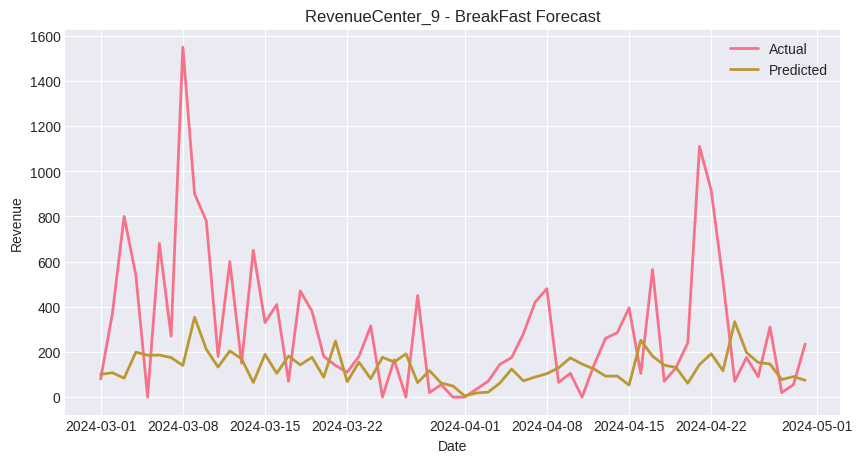

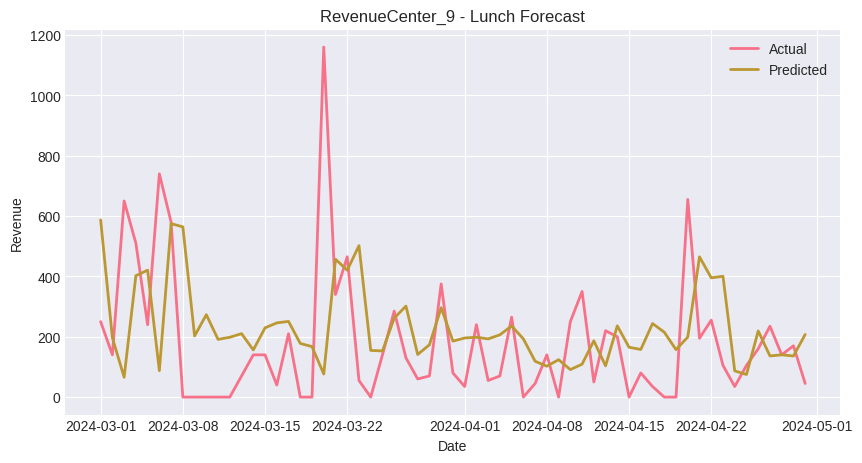

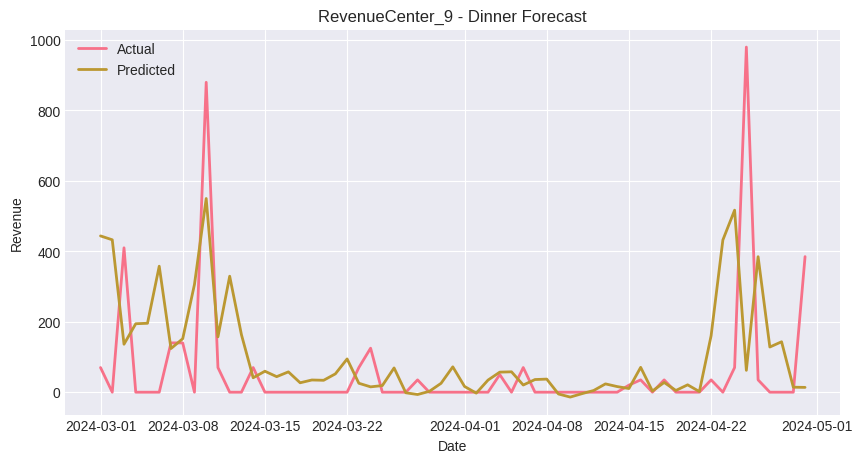


Processing: RevenueCenter_1

BreakFast Validation:
MAE: 1203.28, RMSE: 1698.13, R2: -0.635, MAPE: 46.22%
BreakFast Test:
MAE: 658.34, RMSE: 1216.54, R2: 0.013, MAPE: 97.67%

Lunch Validation:
MAE: 986.77, RMSE: 1325.94, R2: -0.678, MAPE: 78.99%
Lunch Test:
MAE: 493.70, RMSE: 708.87, R2: -0.050, MAPE: 121.01%

Dinner Validation:
MAE: 2489.41, RMSE: 2948.70, R2: -2.262, MAPE: 42.51%
Dinner Test:
MAE: 1197.81, RMSE: 1758.32, R2: 0.072, MAPE: 54.67%


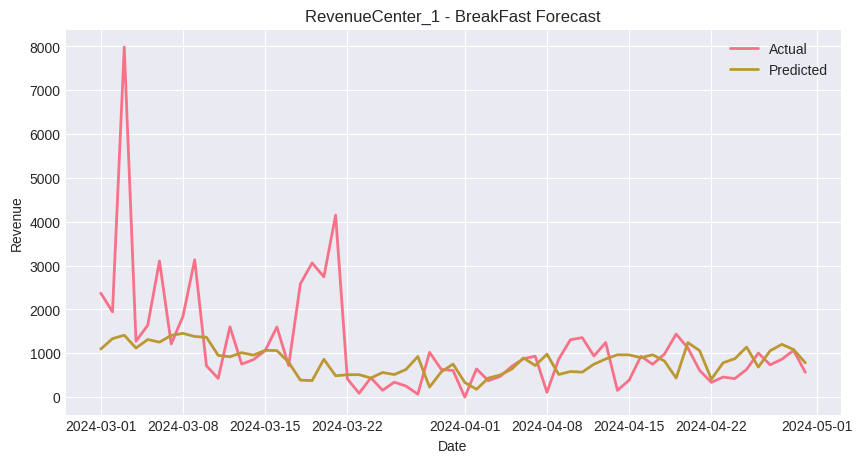

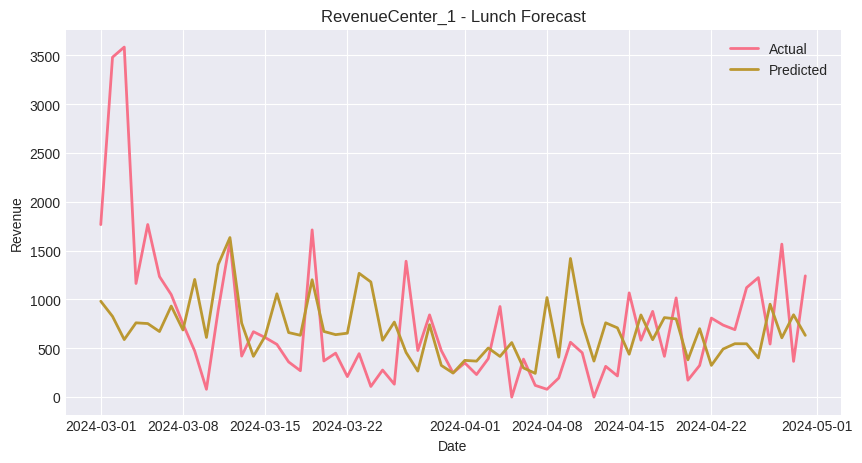

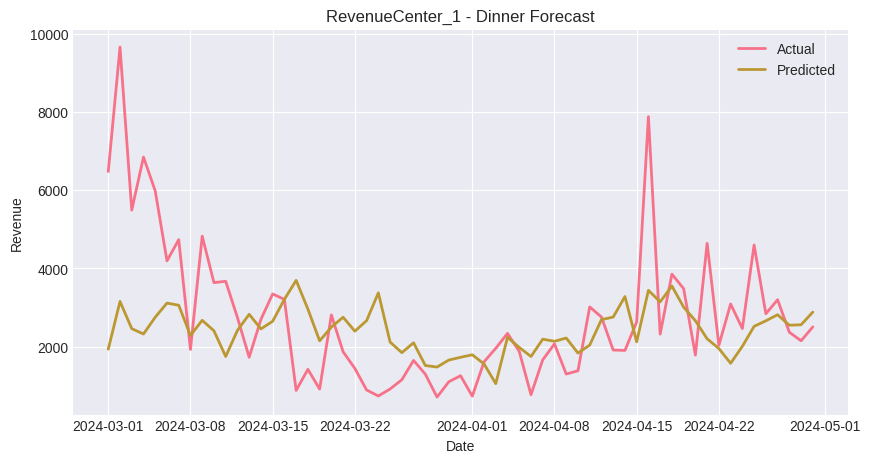


Processing: RevenueCenter_5

BreakFast Validation:
MAE: 13277.93, RMSE: 13869.67, R2: -18.639, MAPE: 44.53%
BreakFast Test:
MAE: 4271.45, RMSE: 5927.54, R2: -0.172, MAPE: 23.30%

Lunch Validation:
MAE: 1837.35, RMSE: 3032.03, R2: -0.270, MAPE: 75.95%
Lunch Test:
MAE: 1659.21, RMSE: 3663.03, R2: -0.113, MAPE: 198.08%

Dinner Validation:
MAE: 8032.94, RMSE: 11076.35, R2: -0.457, MAPE: 119.25%
Dinner Test:
MAE: 6153.64, RMSE: 8720.42, R2: 0.364, MAPE: 64.35%


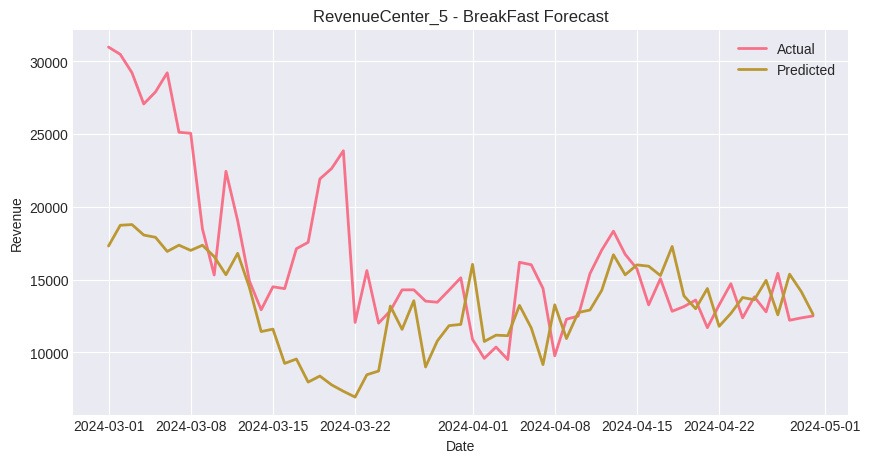

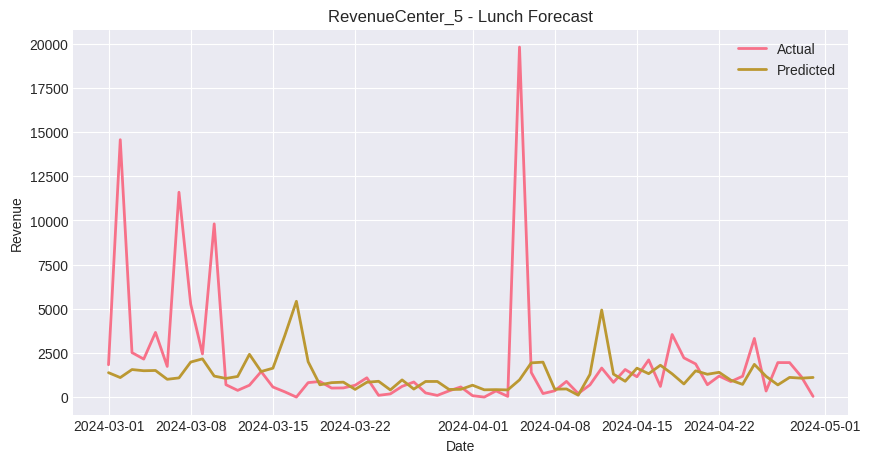

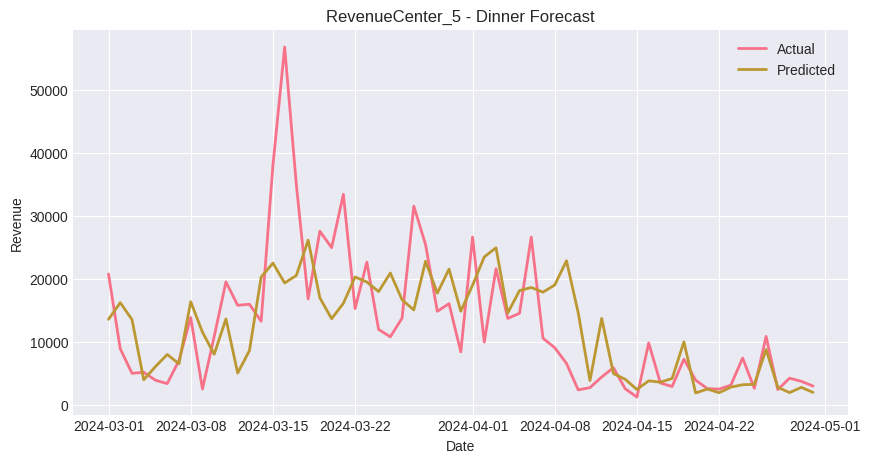


Processing: RevenueCenter_2

BreakFast Validation:
MAE: 337.18, RMSE: 479.37, R2: -0.168, MAPE: 83.26%
BreakFast Test:
MAE: 383.08, RMSE: 587.75, R2: -0.390, MAPE: 182.63%

Lunch Validation:
MAE: 456.37, RMSE: 651.30, R2: -0.491, MAPE: 77.04%
Lunch Test:
MAE: 421.83, RMSE: 938.65, R2: 0.037, MAPE: 151.15%

Dinner Validation:
MAE: 762.86, RMSE: 1536.46, R2: -0.311, MAPE: 76.48%
Dinner Test:
MAE: 368.89, RMSE: 582.95, R2: 0.093, MAPE: 206.71%


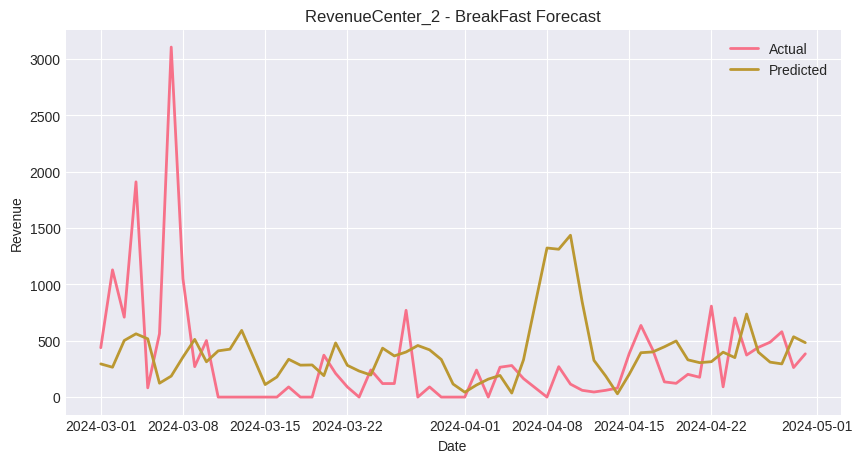

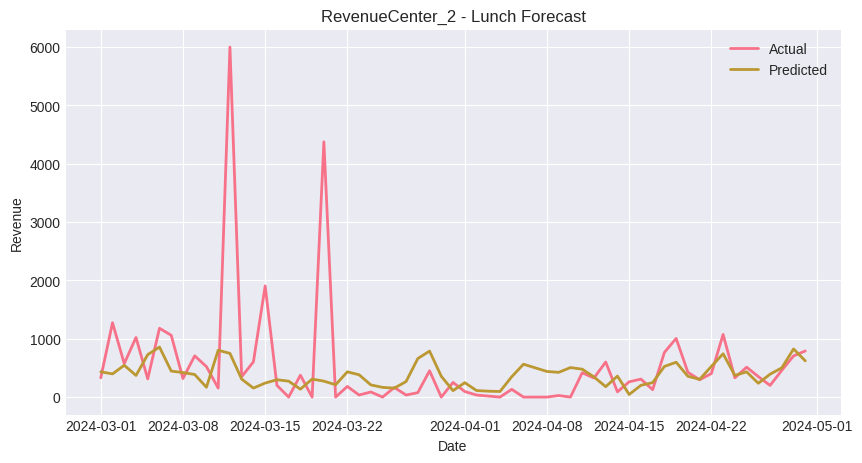

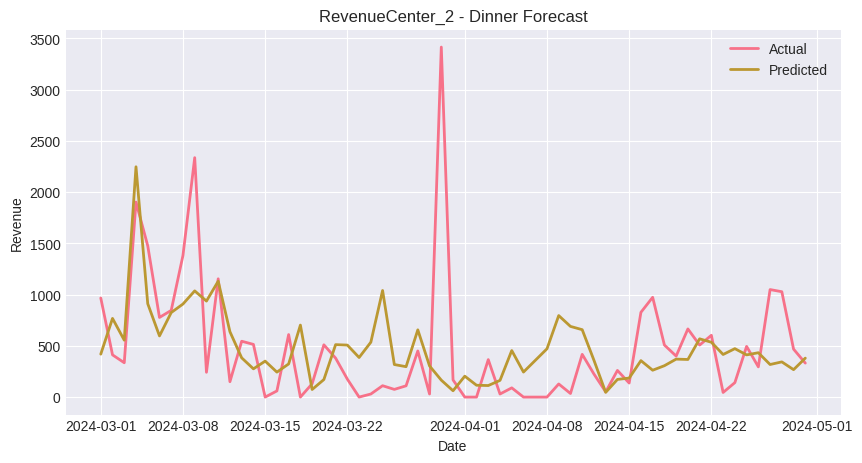


Processing: RevenueCenter_8

BreakFast Validation:
MAE: 1862.98, RMSE: 2544.84, R2: -3.657, MAPE: 90.43%
BreakFast Test:
MAE: 2411.81, RMSE: 4460.87, R2: -0.326, MAPE: 80.75%

Lunch Validation:
MAE: 16015.92, RMSE: 23986.14, R2: -0.167, MAPE: 66.17%
Lunch Test:
MAE: 9169.84, RMSE: 16833.52, R2: 0.092, MAPE: 130.84%

Dinner Validation:
MAE: 20993.60, RMSE: 29904.37, R2: -0.127, MAPE: 57.68%
Dinner Test:
MAE: 16089.41, RMSE: 24716.34, R2: 0.009, MAPE: 80.84%


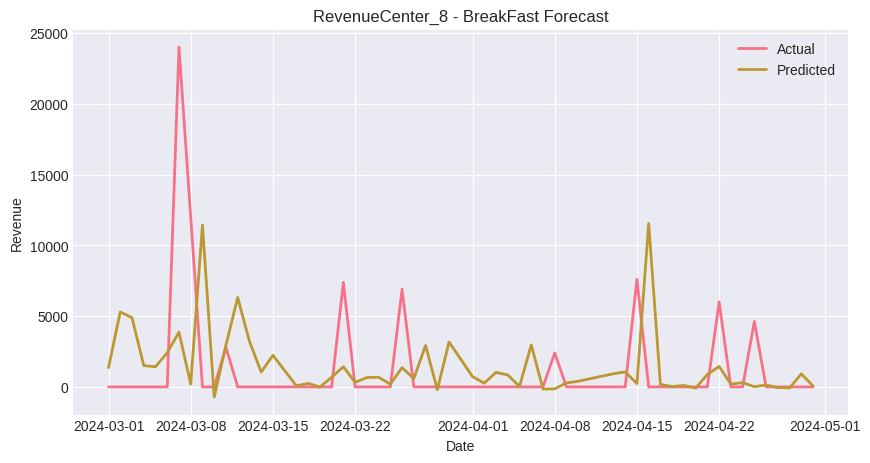

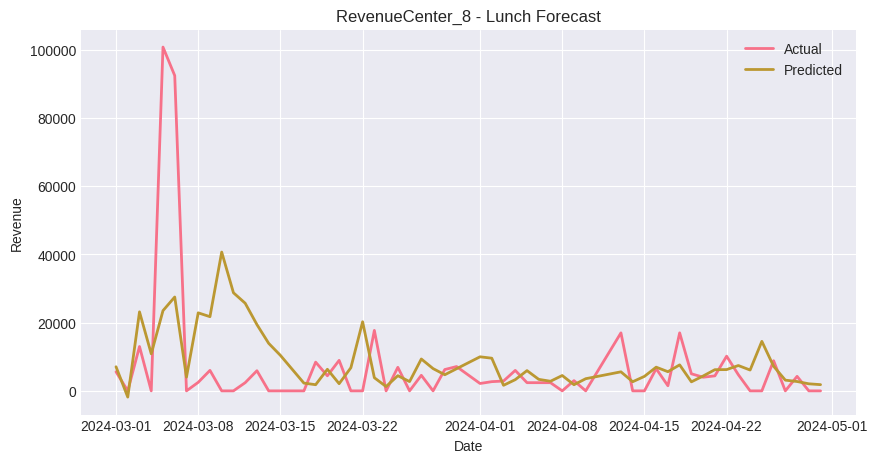

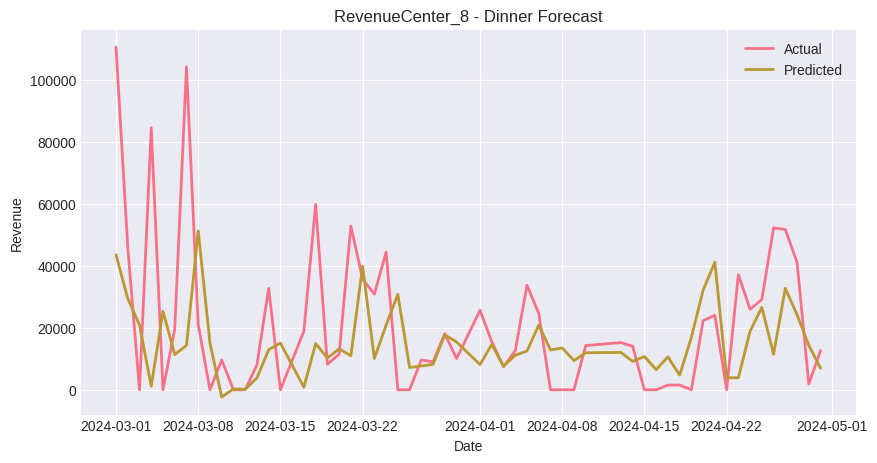


Processing: RevenueCenter_6

BreakFast Validation:
MAE: 289.23, RMSE: 361.52, R2: -0.246, MAPE: 107.28%
BreakFast Test:
MAE: 238.56, RMSE: 447.26, R2: 0.059, MAPE: 141.43%

Lunch Validation:
MAE: 511.28, RMSE: 743.96, R2: -0.372, MAPE: 87.73%
Lunch Test:
MAE: 437.48, RMSE: 784.71, R2: 0.003, MAPE: 136.20%

Dinner Validation:
MAE: 1667.08, RMSE: 5598.62, R2: -0.343, MAPE: 183.69%
Dinner Test:
MAE: 1673.98, RMSE: 7421.15, R2: -0.044, MAPE: 304.69%


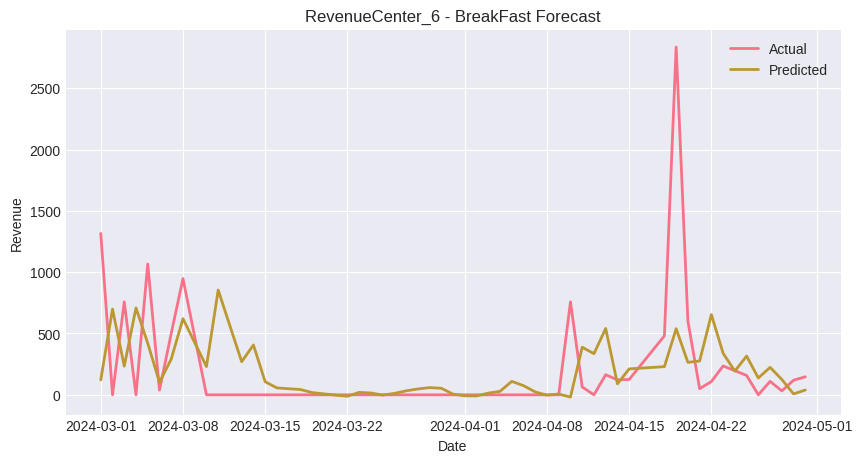

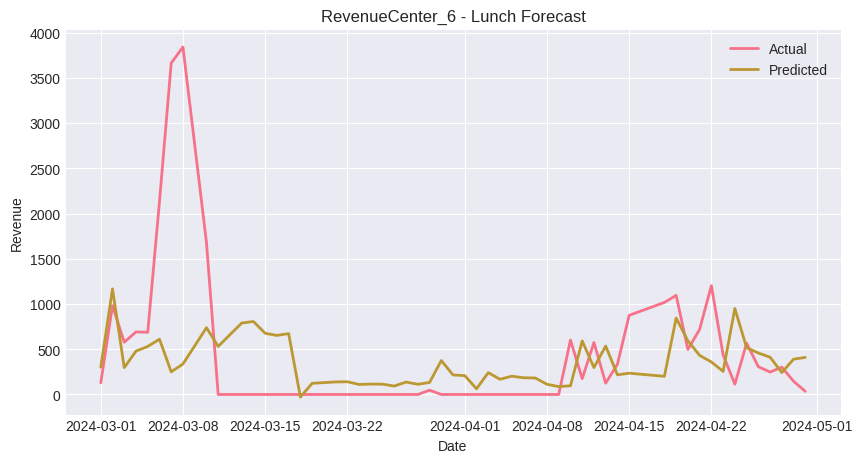

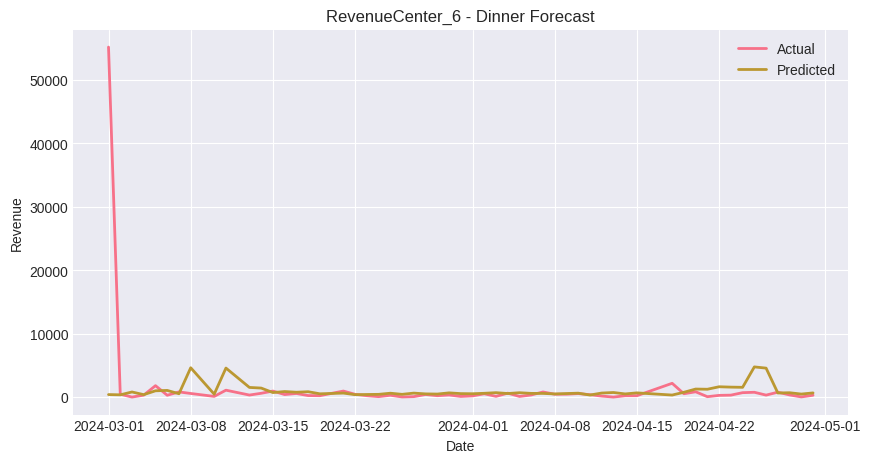


Processing: RevenueCenter_3

BreakFast Validation:
MAE: 381.81, RMSE: 509.44, R2: -0.340, MAPE: 127.43%
BreakFast Test:
MAE: 314.25, RMSE: 404.46, R2: -0.579, MAPE: 122.64%

Lunch Validation:
MAE: 1259.00, RMSE: 1862.55, R2: -0.370, MAPE: 40.42%
Lunch Test:
MAE: 891.76, RMSE: 1275.13, R2: 0.012, MAPE: 51.20%

Dinner Validation:
MAE: 7950.71, RMSE: 9600.22, R2: -1.977, MAPE: 33.70%
Dinner Test:
MAE: 4913.24, RMSE: 10163.67, R2: 0.139, MAPE: 40.75%


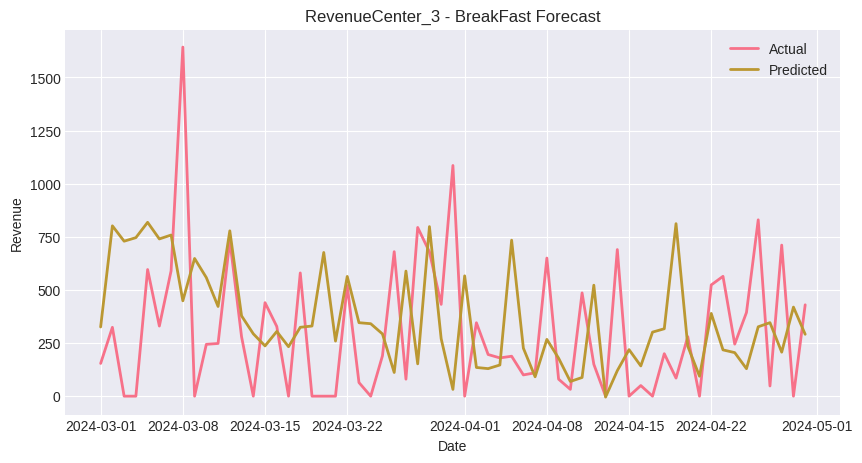

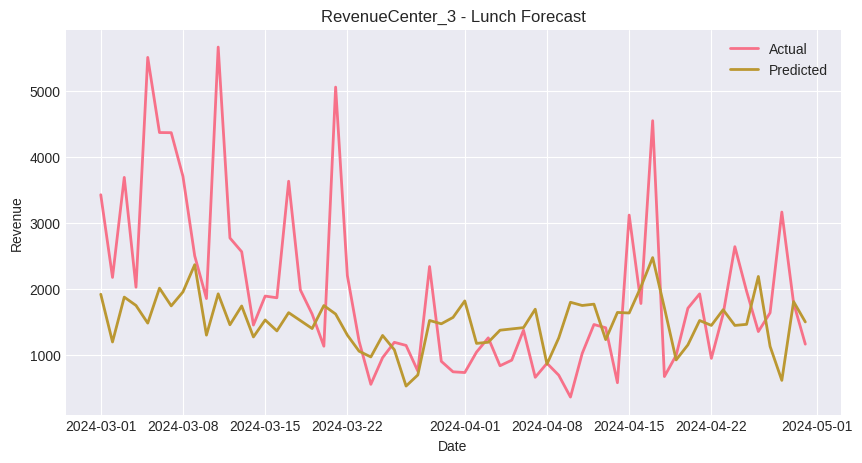

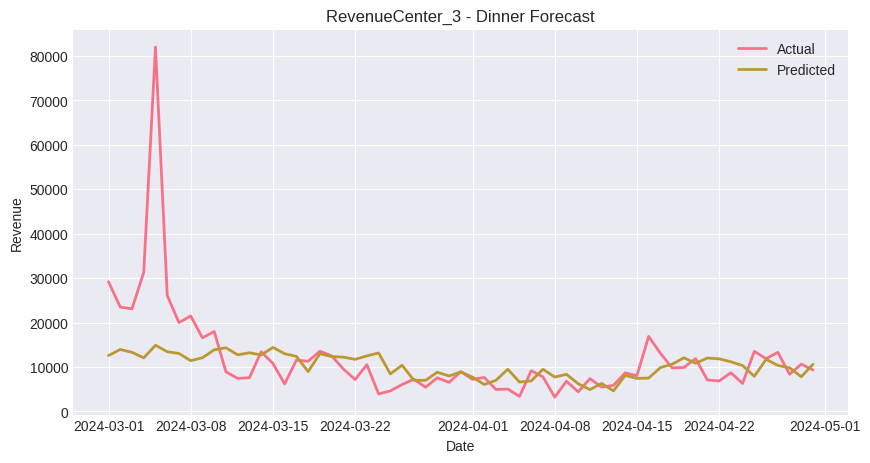


Processing: RevenueCenter_7

BreakFast Validation:
MAE: 70.86, RMSE: 108.99, R2: -0.584, MAPE: 191.56%
BreakFast Test:
MAE: 42.83, RMSE: 58.16, R2: -1.498, MAPE: 166.95%

Lunch Validation:
MAE: 65.41, RMSE: 93.26, R2: -0.427, MAPE: 77.30%
Lunch Test:
MAE: 47.50, RMSE: 76.83, R2: -0.153, MAPE: 126.12%

Dinner Validation:
MAE: 97.15, RMSE: 131.37, R2: -0.557, MAPE: 76.78%
Dinner Test:
MAE: 82.29, RMSE: 143.99, R2: -0.177, MAPE: 86.23%


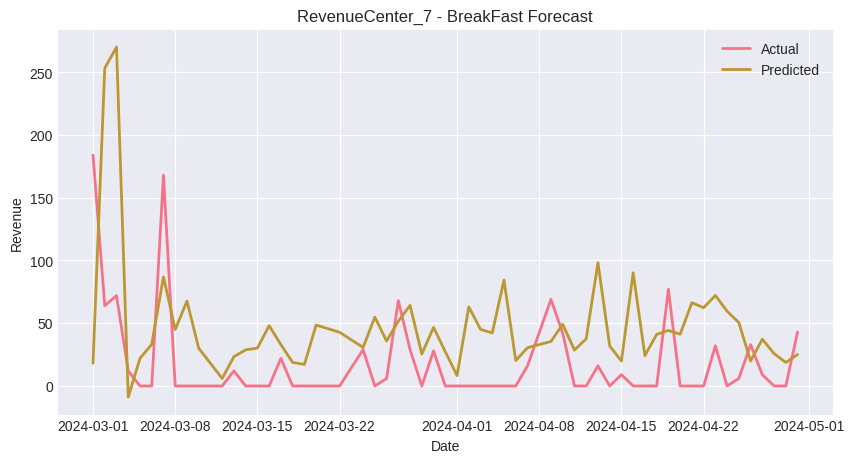

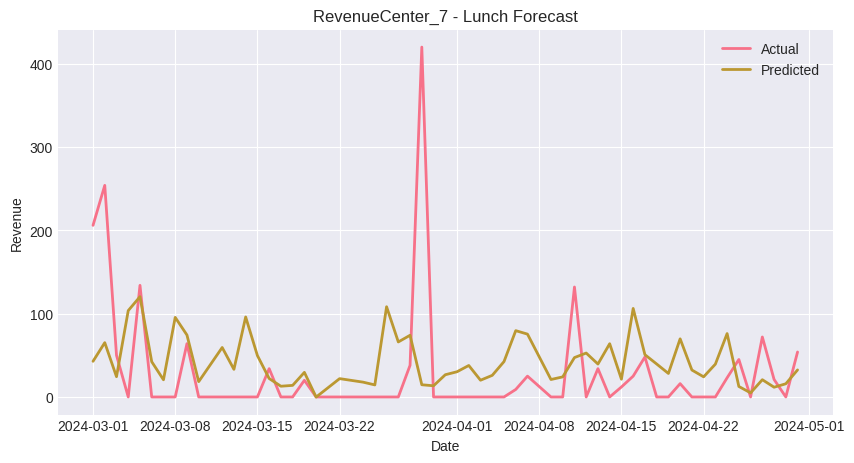

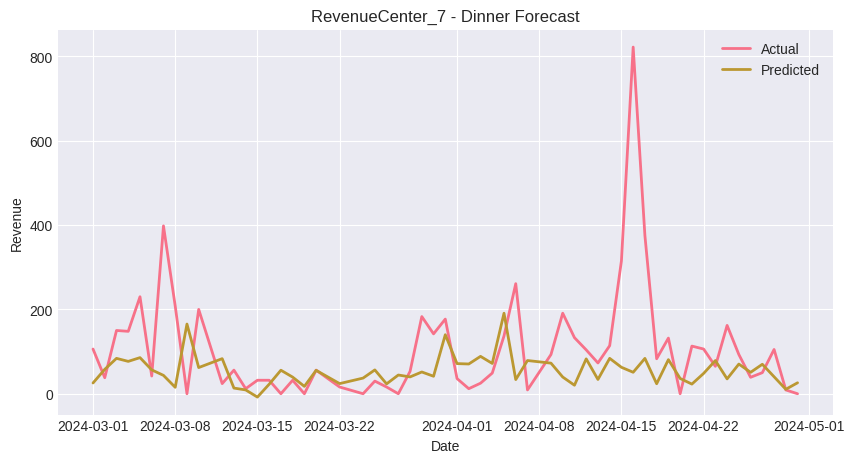


Processing: RevenueCenter_4

BreakFast Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
BreakFast Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%

Lunch Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
Lunch Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mas


Dinner Validation:
MAE: 0.00, RMSE: 0.00, R2: 0.000, MAPE: nan%
Dinner Test:
MAE: 0.00, RMSE: 0.00, R2: 0.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


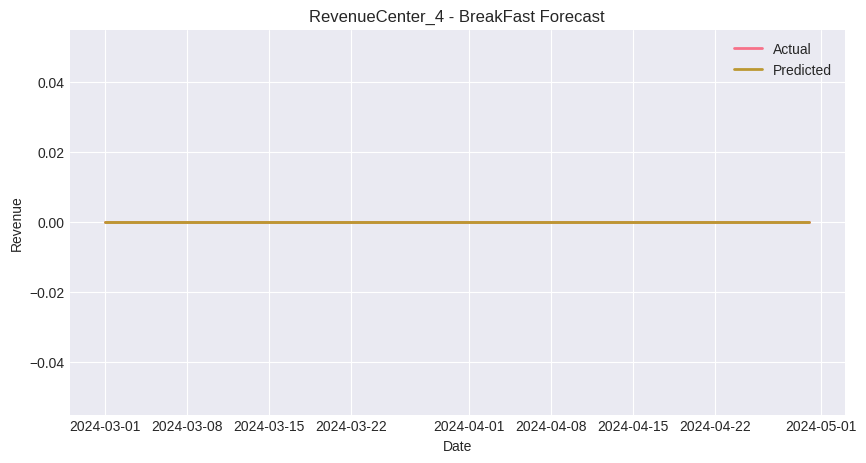

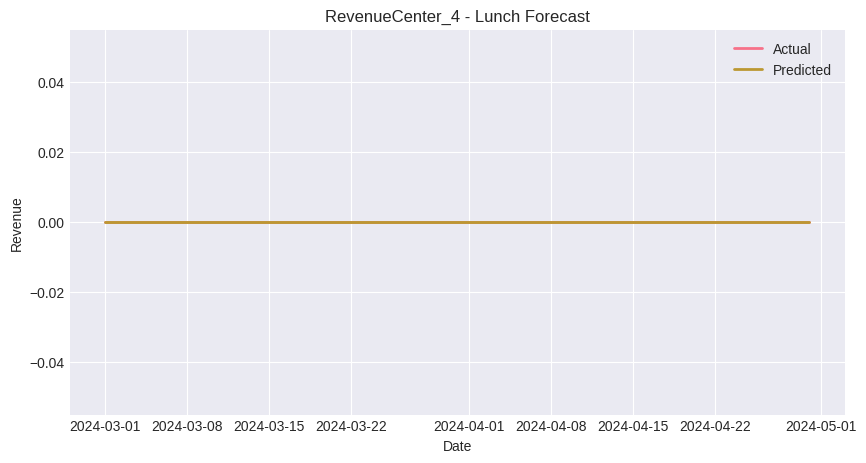

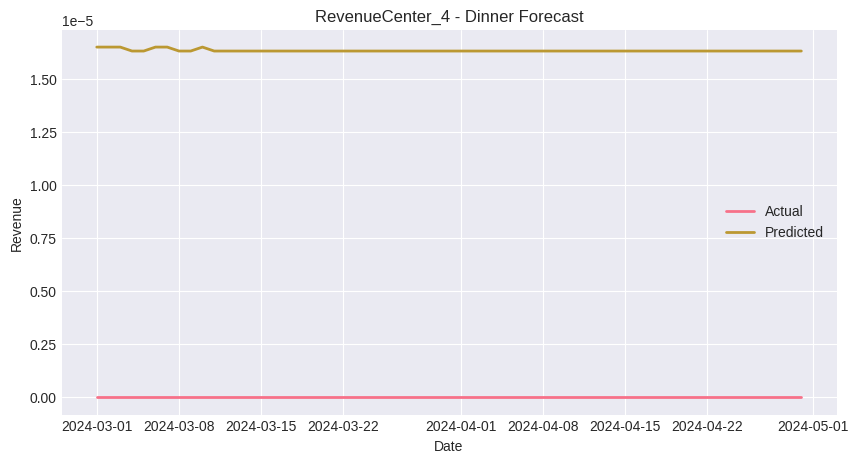


Processing spike dataset...

Processing: RevenueCenter_9

BreakFast Validation:
MAE: 445.20, RMSE: 603.89, R2: -0.989, MAPE: 93.62%
BreakFast Test:
MAE: 257.40, RMSE: 403.90, R2: -0.381, MAPE: 87.88%

Lunch Validation:
MAE: 254.13, RMSE: 328.81, R2: -0.360, MAPE: 78.67%
Lunch Test:
MAE: 144.47, RMSE: 241.51, R2: -0.053, MAPE: 67.00%

Dinner Validation:
MAE: 212.91, RMSE: 264.64, R2: -12.232, MAPE: 149.88%
Dinner Test:
MAE: 132.24, RMSE: 209.27, R2: -0.368, MAPE: 77.57%


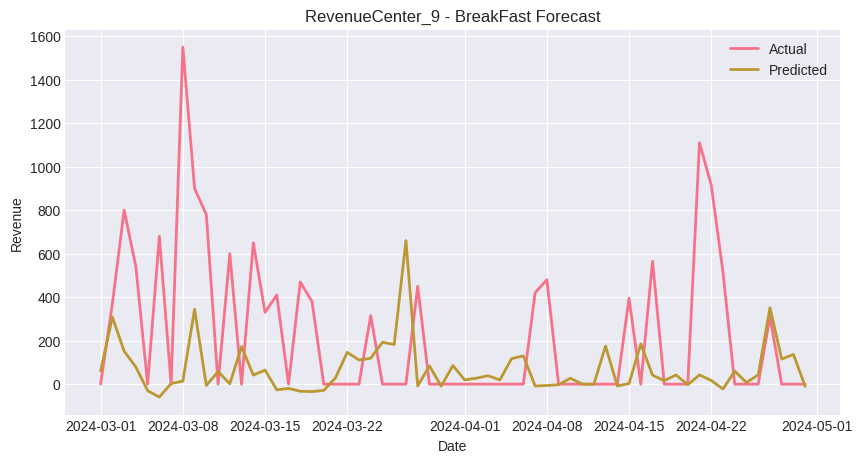

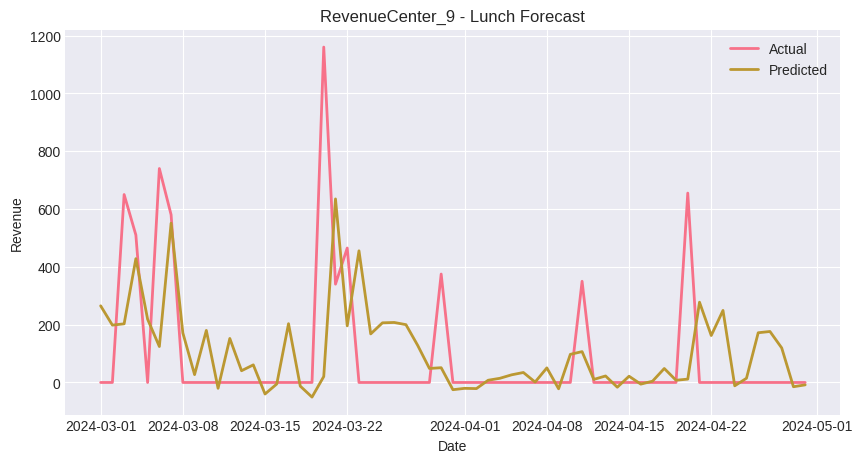

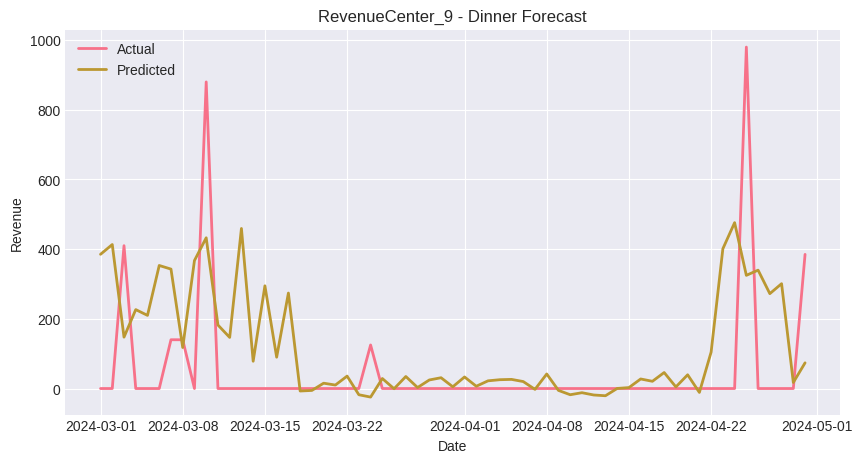


Processing: RevenueCenter_1

BreakFast Validation:
MAE: 1607.63, RMSE: 2053.64, R2: -0.565, MAPE: 69.79%
BreakFast Test:
MAE: 662.72, RMSE: 1401.42, R2: 0.012, MAPE: 81.81%

Lunch Validation:
MAE: 1281.58, RMSE: 1617.92, R2: -0.690, MAPE: 68.08%
Lunch Test:
MAE: 586.17, RMSE: 973.22, R2: -0.470, MAPE: 79.23%

Dinner Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
Dinner Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


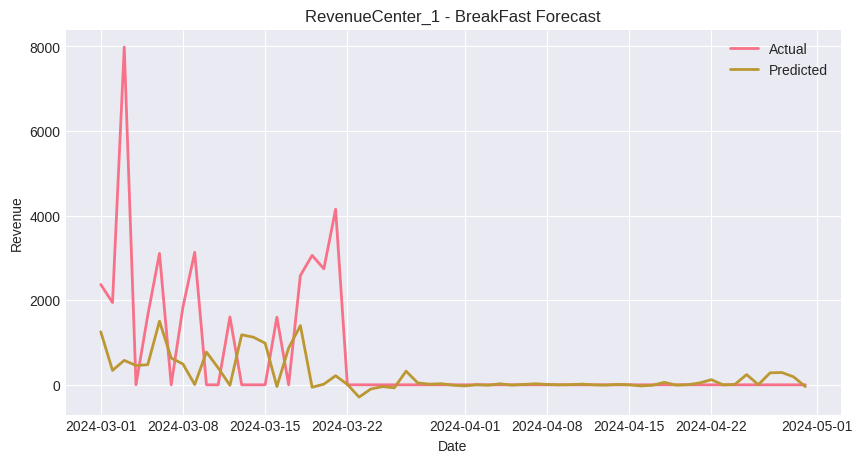

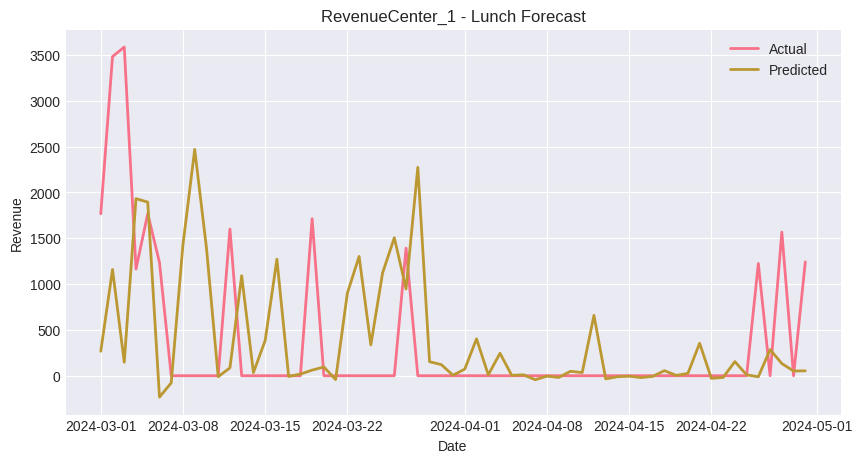

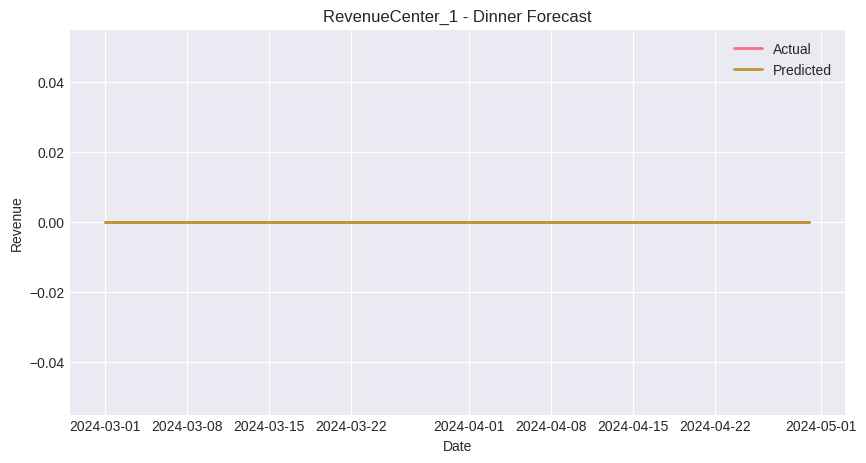


Processing: RevenueCenter_5

BreakFast Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
BreakFast Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Lunch Validation:
MAE: 617.05, RMSE: 2069.53, R2: 0.438, MAPE: 77.65%
Lunch Test:
MAE: 1576.01, RMSE: 4289.27, R2: -0.432, MAPE: 99.98%

Dinner Validation:
MAE: 6611.86, RMSE: 15129.24, R2: -1.710, MAPE: 100.00%
Dinner Test:
MAE: 4307.87, RMSE: 12877.35, R2: -0.372, MAPE: 100.09%


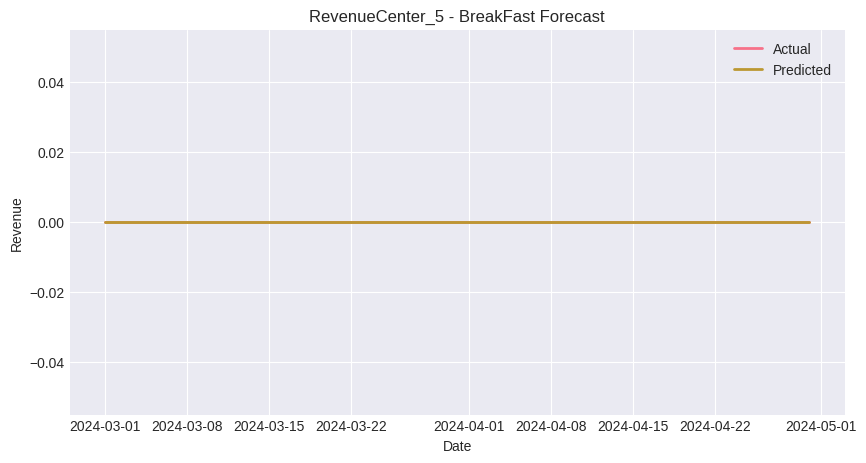

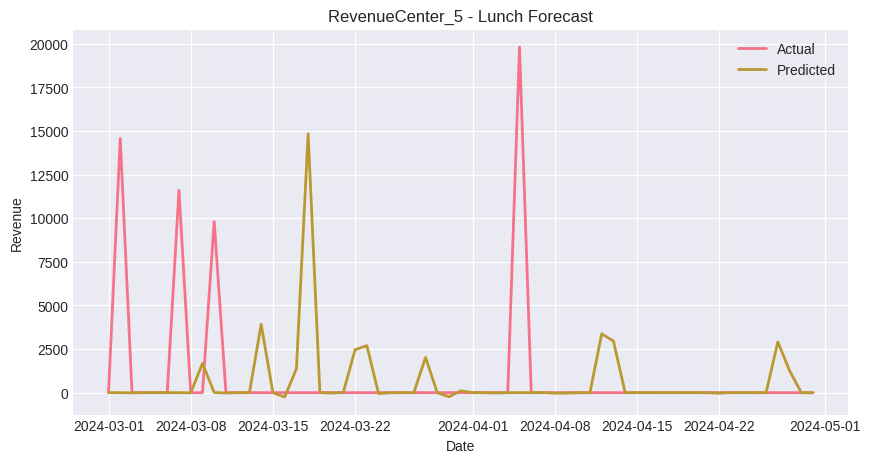

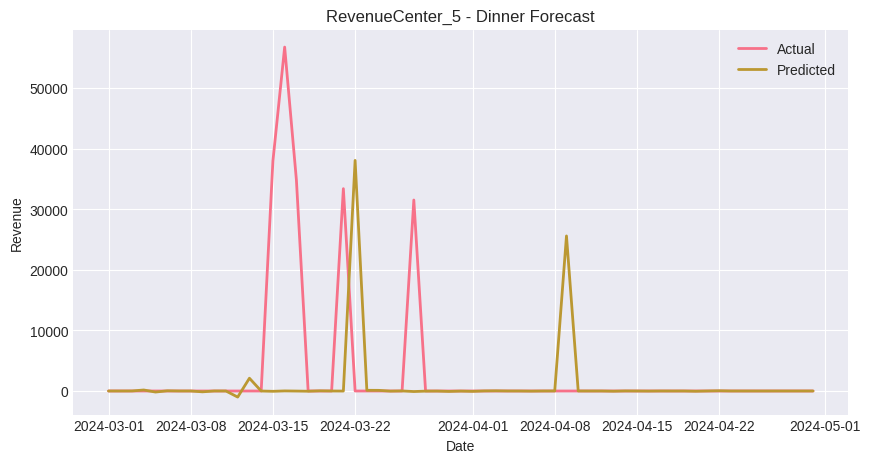


Processing: RevenueCenter_2

BreakFast Validation:
MAE: 520.10, RMSE: 629.01, R2: -0.316, MAPE: 55.50%
BreakFast Test:
MAE: 328.49, RMSE: 534.45, R2: -0.033, MAPE: 73.47%

Lunch Validation:
MAE: 504.53, RMSE: 699.33, R2: -0.026, MAPE: 65.99%
Lunch Test:
MAE: 414.47, RMSE: 1034.93, R2: -0.065, MAPE: 71.37%

Dinner Validation:
MAE: 945.75, RMSE: 1640.53, R2: -0.268, MAPE: 81.50%
Dinner Test:
MAE: 457.01, RMSE: 784.32, R2: -0.389, MAPE: 85.30%


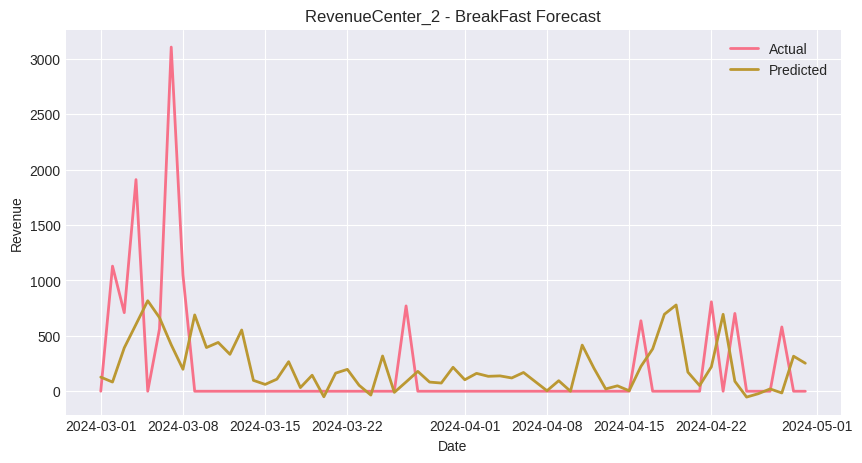

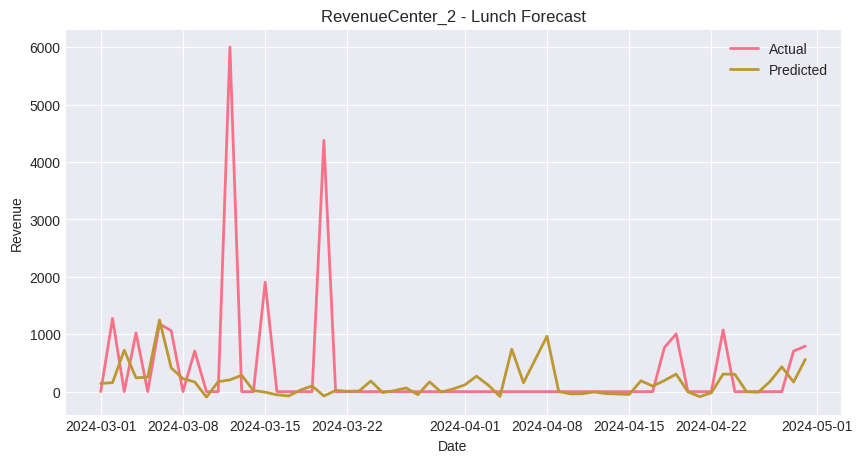

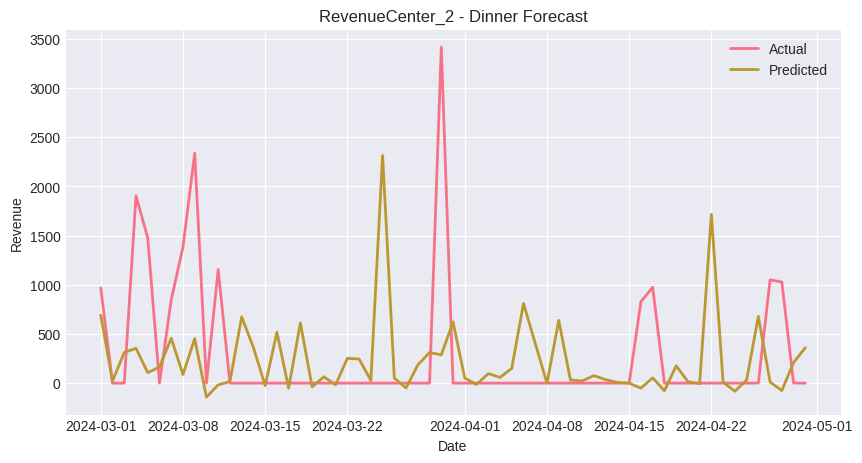


Processing: RevenueCenter_8

BreakFast Validation:
MAE: 2191.00, RMSE: 3227.46, R2: -6.491, MAPE: 99.62%
BreakFast Test:
MAE: 2727.78, RMSE: 4708.06, R2: -0.477, MAPE: 84.15%

Lunch Validation:
MAE: 14803.45, RMSE: 25896.66, R2: -0.234, MAPE: 90.11%
Lunch Test:
MAE: 7823.13, RMSE: 21172.74, R2: -0.417, MAPE: 98.69%

Dinner Validation:
MAE: 8528.37, RMSE: 27760.29, R2: -0.100, MAPE: 100.05%
Dinner Test:
MAE: 9278.14, RMSE: 26554.39, R2: -0.404, MAPE: 99.36%


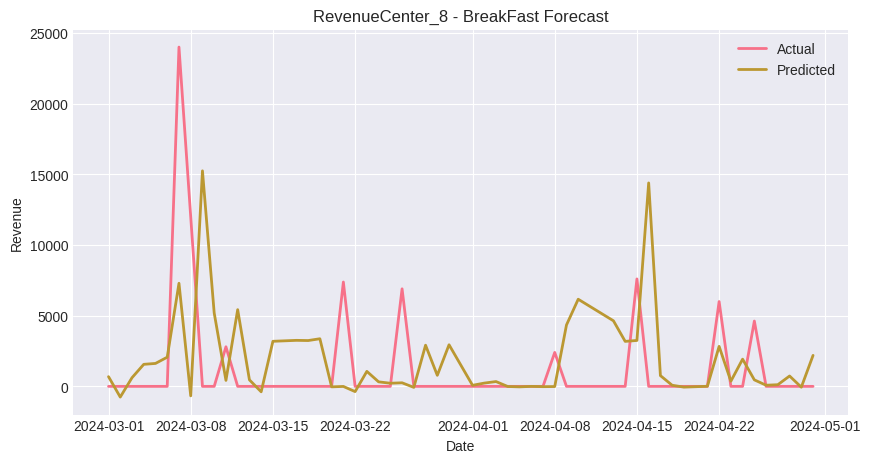

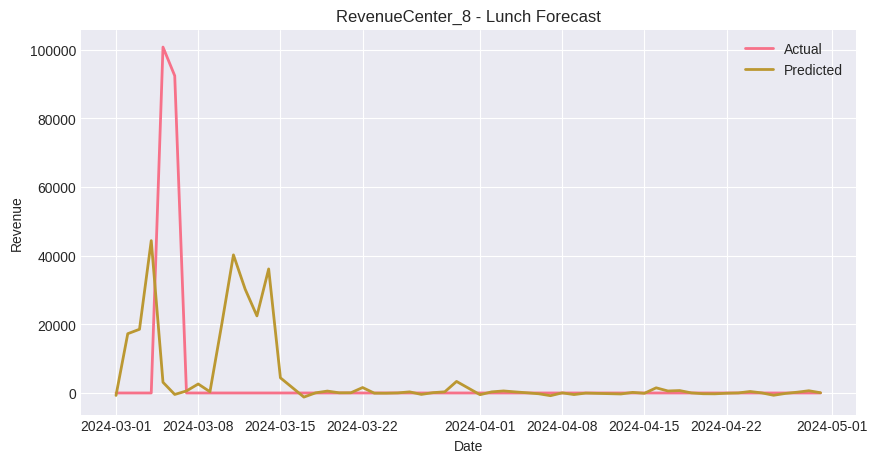

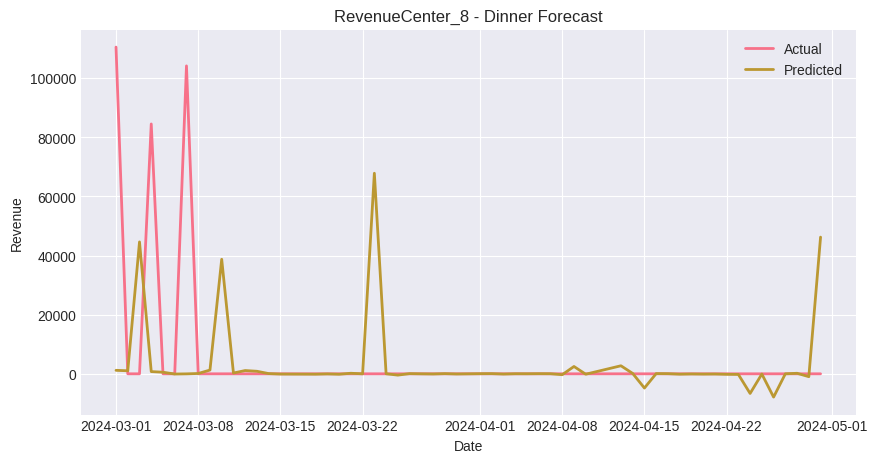


Processing: RevenueCenter_6

BreakFast Validation:
MAE: 306.20, RMSE: 396.65, R2: -0.389, MAPE: 55.55%
BreakFast Test:
MAE: 235.28, RMSE: 463.86, R2: 0.016, MAPE: 75.48%

Lunch Validation:
MAE: 620.86, RMSE: 855.85, R2: -0.264, MAPE: 59.52%
Lunch Test:
MAE: 419.87, RMSE: 780.40, R2: 0.060, MAPE: 65.25%

Dinner Validation:
MAE: 1820.03, RMSE: 5216.25, R2: -0.135, MAPE: 86.71%
Dinner Test:
MAE: 1315.20, RMSE: 7420.48, R2: -0.030, MAPE: 81.63%


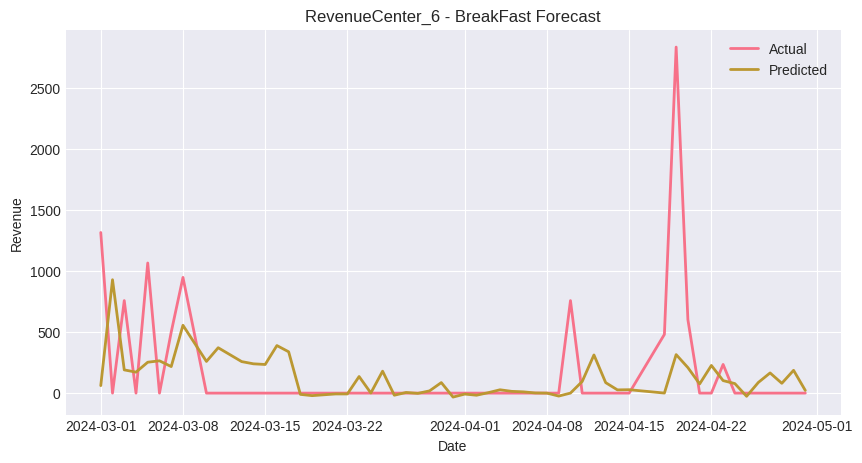

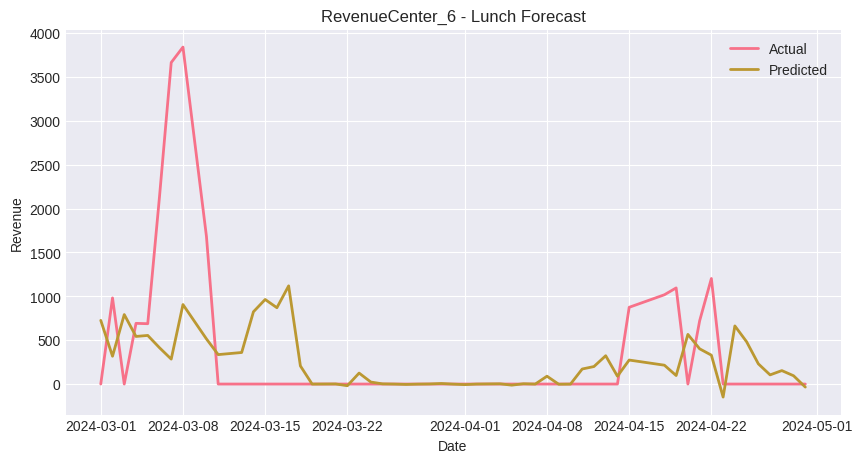

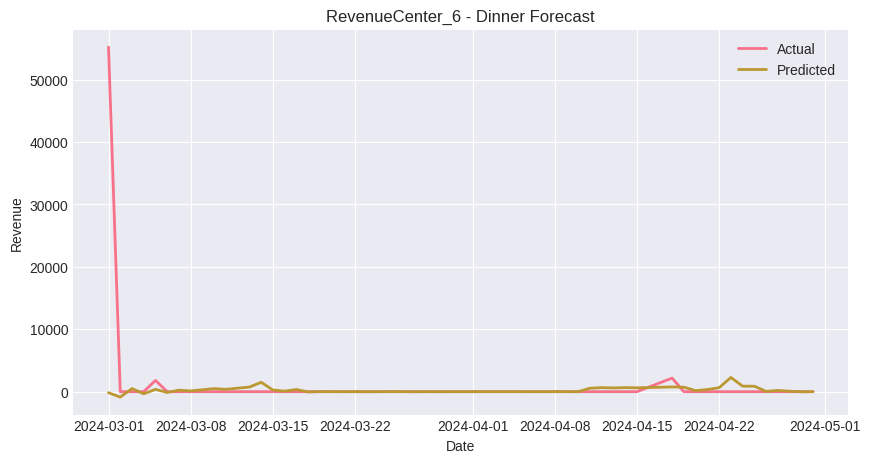


Processing: RevenueCenter_3

BreakFast Validation:
MAE: 444.88, RMSE: 606.74, R2: -0.431, MAPE: 76.27%
BreakFast Test:
MAE: 300.02, RMSE: 414.89, R2: -0.371, MAPE: 71.72%

Lunch Validation:
MAE: 150.72, RMSE: 1167.51, R2: -0.017, MAPE: 100.00%
Lunch Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Dinner Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
Dinner Test:
MAE: 1344.15, RMSE: 10498.13, R2: -0.017, MAPE: 100.00%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


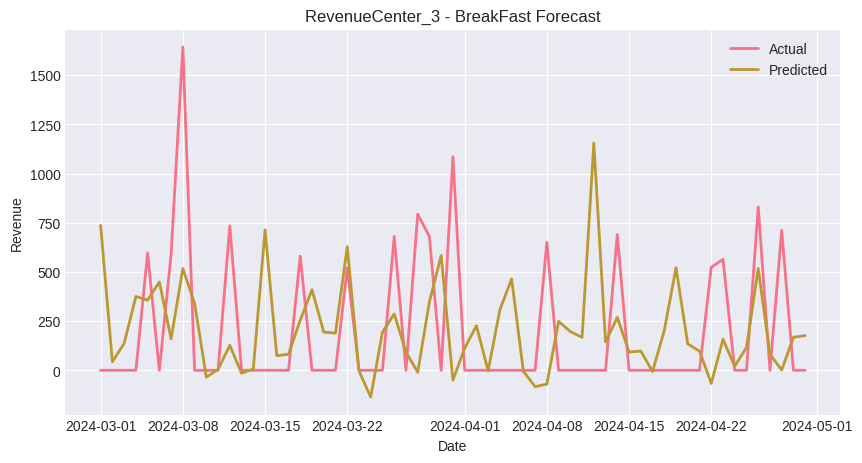

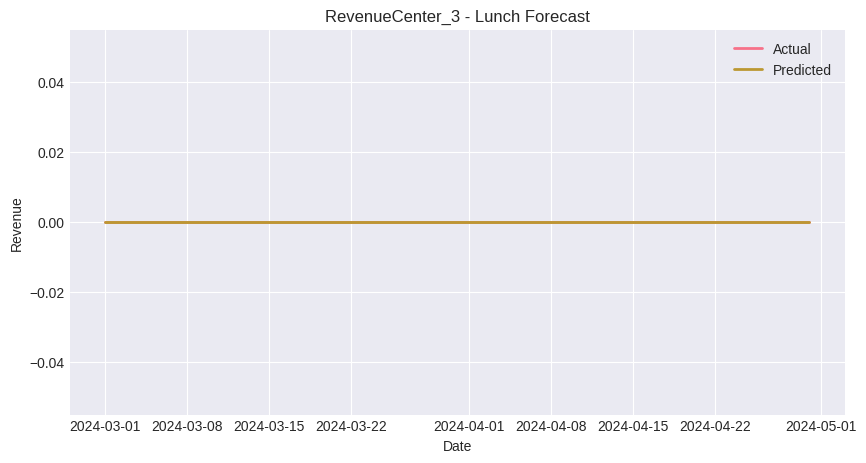

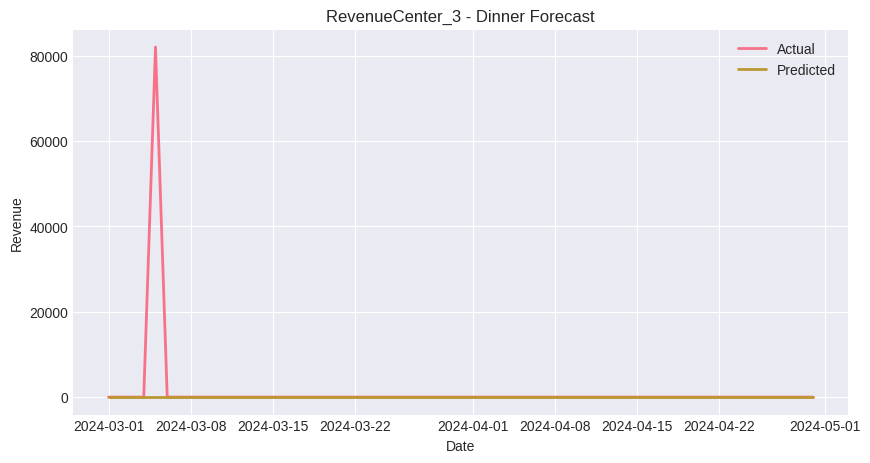


Processing: RevenueCenter_7

BreakFast Validation:
MAE: 85.74, RMSE: 145.27, R2: -1.608, MAPE: 83.85%
BreakFast Test:
MAE: 38.45, RMSE: 57.68, R2: -1.430, MAPE: 111.50%

Lunch Validation:
MAE: 72.90, RMSE: 98.43, R2: -0.490, MAPE: 74.63%
Lunch Test:
MAE: 52.26, RMSE: 80.21, R2: -0.224, MAPE: 76.97%

Dinner Validation:
MAE: 113.58, RMSE: 151.03, R2: -0.575, MAPE: 70.50%
Dinner Test:
MAE: 92.68, RMSE: 149.69, R2: -0.082, MAPE: 75.88%


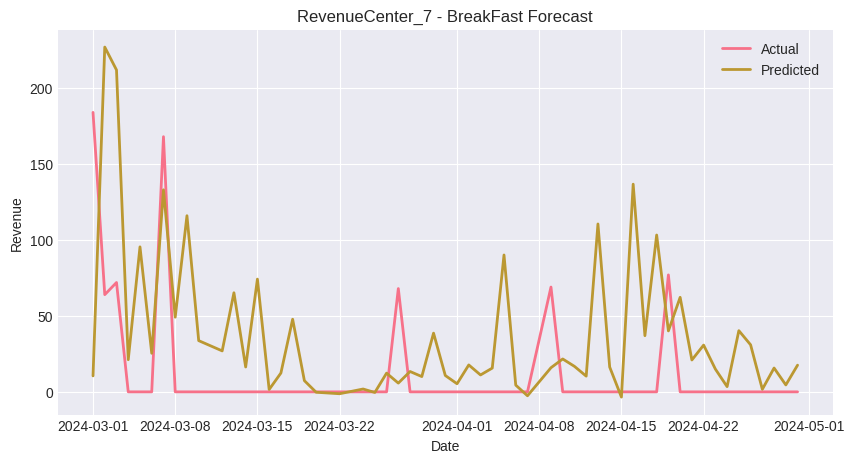

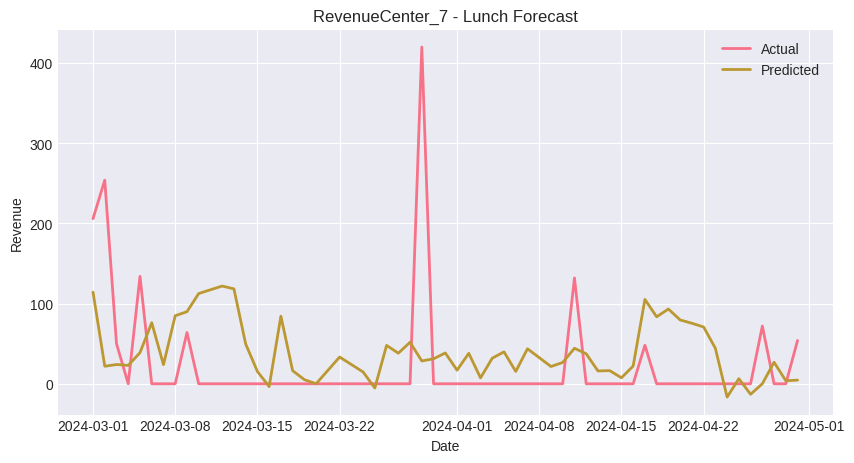

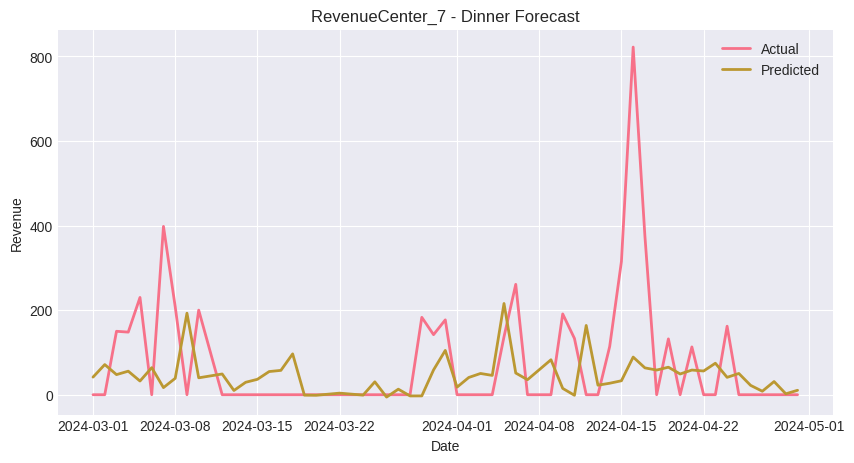


Processing: RevenueCenter_4

BreakFast Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
BreakFast Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Lunch Validation:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%
Lunch Test:
MAE: 0.00, RMSE: 0.00, R2: 1.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Dinner Validation:
MAE: 0.00, RMSE: 0.00, R2: 0.000, MAPE: nan%
Dinner Test:
MAE: 0.00, RMSE: 0.00, R2: 0.000, MAPE: nan%


/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3074837950.py:36: RuntimeWarning: Mean of empty slice.
  return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


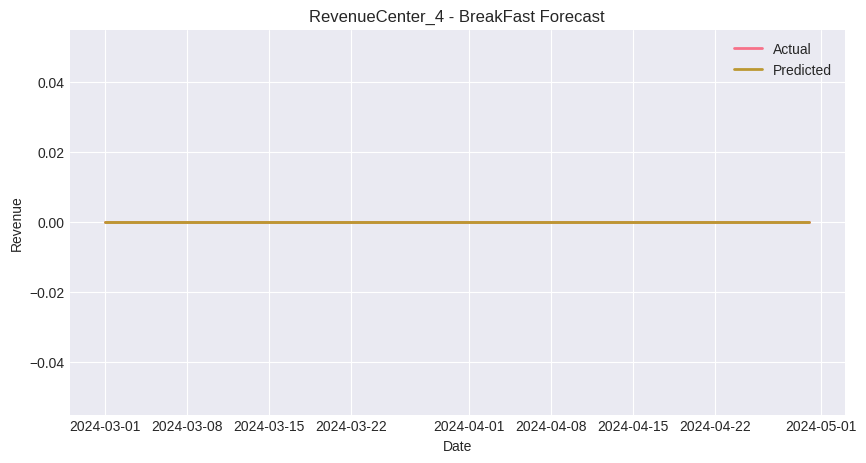

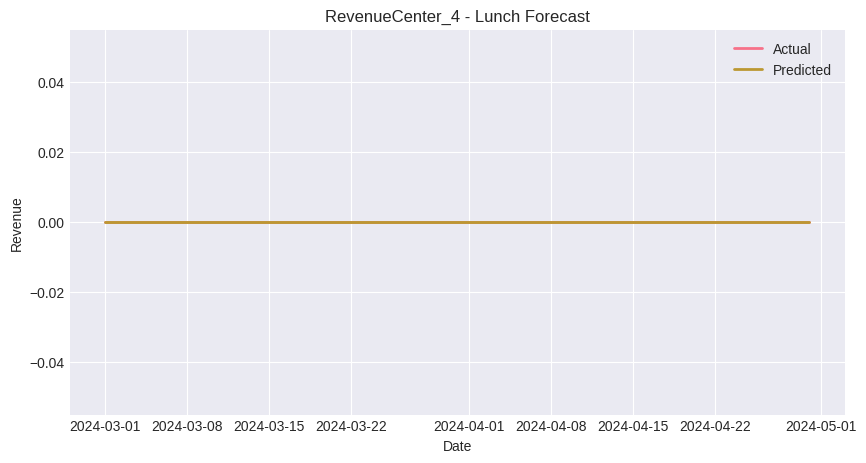

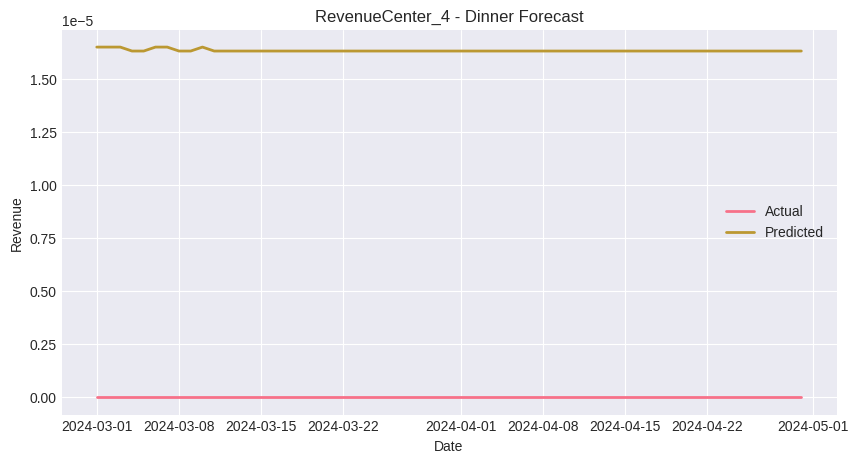


All processing completed!


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# SETTINGS
datasets = {
    "normal": {
        "input": "/content/data_sets",
        "output": "/content/prediction_results"
    },
    "spike": {
        "input": "/content/data_set_spikes",
        "output": "/content/prediction_results_spike"
    }
}

os.makedirs(datasets["normal"]["output"], exist_ok=True)
os.makedirs(datasets["spike"]["output"], exist_ok=True)

# Model
LEARNING_RATE = 0.08
N_ESTIMATORS  = 900
MAX_DEPTH     = 5
RANDOM_STATE  = 42

meals = ["BreakFast", "Lunch", "Dinner"]

# METRICS
def mape(y, p):
    y, p = np.array(y), np.array(p)
    mask = y != 0
    return (np.abs((y[mask] - p[mask]) / y[mask]).mean()) * 100

def evaluate(y_true, y_pred):
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}, "
          f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}, "
          f"R2: {r2_score(y_true, y_pred):.3f}, "
          f"MAPE: {mape(y_true, y_pred):.2f}%")


# PROCESSING FUNCTION
def process_data(input_folder, output_folder):
    files = glob.glob(os.path.join(input_folder, "*.xlsx"))
    if not files:
        print(f"No files found in {input_folder}")
        return

    for file in files:
        center = os.path.basename(file).replace(".xlsx", "")
        print(f"\nProcessing: {center}")

        df = pd.read_excel(file)
        if "Date" not in df.columns:
            print("  Skipping: 'Date' column missing")
            continue
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        # Lag & rolling features
        for meal in meals:
            if meal in df.columns:
                df[f"{meal}_lag_1"] = df[meal].shift(1)
                df[f"{meal}_lag_7"] = df[meal].shift(7)
                df[f"{meal}_roll_3"] = df[meal].shift(1).rolling(3).mean()
                df[f"{meal}_roll_7"] = df[meal].shift(1).rolling(7).mean()

        df = df.dropna()
        if len(df) < 30:
            print(f"  Not enough data, skipping...")
            continue

        # Split
        train = df[df["Date"] < "2024-01-01"]
        val   = df[(df["Date"] >= "2024-01-01") & (df["Date"] <= "2024-02-29")]
        test  = df[(df["Date"] >= "2024-03-01") & (df["Date"] <= "2024-04-30")]

        # Feature list
        base_features = ["average_temperature","weather_code","Day_Monday","Day_Tuesday","Day_Wednesday",
                         "Day_Thursday","Day_Friday","Day_Saturday","Day_Sunday","IsWeekend","IsHoliday"]
        features = [f for f in base_features if f in df.columns]
        for meal in meals:
            for suffix in ["lag_1","lag_7","roll_3","roll_7"]:
                col = f"{meal}_{suffix}"
                if col in df.columns:
                    features.append(col)

        predictions = {}
        for meal in meals:
            if meal not in df.columns:
                continue
            X_train, y_train = train[features], train[meal]
            X_val, y_val     = val[features], val[meal]
            X_test, y_test   = test[features], test[meal]

            model = XGBRegressor(n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
                                 max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
            model.fit(X_train, y_train)

            val_pred  = model.predict(X_val)
            test_pred = model.predict(X_test)

            print(f"\n{meal} Validation:")
            evaluate(y_val, val_pred)
            print(f"{meal} Test:")
            evaluate(y_test, test_pred)

            predictions[meal] = test_pred

        # Save CSV
        result = pd.DataFrame({"Date": test["Date"]})
        for meal in meals:
            if meal in predictions:
                result[f"Actual_{meal}"] = test[meal]
                result[f"Pred_{meal}"]   = predictions[meal]
        result.to_csv(os.path.join(output_folder, f"{center}_predictions.csv"), index=False)

        # Save plots
        for meal in meals:
            if meal in predictions:
                plt.figure(figsize=(10,5))
                plt.plot(test["Date"], test[meal], label="Actual", linewidth=2)
                plt.plot(test["Date"], predictions[meal], label="Predicted", linewidth=2)
                plt.title(f"{center} - {meal} Forecast")
                plt.xlabel("Date")
                plt.ylabel("Revenue")
                plt.legend()
                plt.grid(True)
                plt.savefig(os.path.join(output_folder, f"{center}_{meal}_plot.png"), dpi=200)
                plt.show()
                plt.close()

#  RUN
for name, paths in datasets.items():
    print(f"\nProcessing {name} dataset...")
    process_data(paths["input"], paths["output"])

print("\nAll processing completed!")
